In [1]:
from google.colab import userdata
import os
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

!kaggle competitions download -c store-sales-time-series-forecasting

!unzip -o store-sales-time-series-forecasting.zip -d store-sales

  0% 0.00/21.4M [00:00<?, ?B/s]
100% 21.4M/21.4M [00:00<00:00, 989MB/s]
Archive:  store-sales-time-series-forecasting.zip
  inflating: store-sales/holidays_events.csv  
  inflating: store-sales/oil.csv     
  inflating: store-sales/sample_submission.csv  
  inflating: store-sales/stores.csv  
  inflating: store-sales/test.csv    
  inflating: store-sales/train.csv   
  inflating: store-sales/transactions.csv  


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
DATA_PATH = 'store-sales/'
data_files = [f for f in os.listdir(DATA_PATH) if f.endswith('.csv')]

df = {}
for filename in data_files:
  df_name = filename.split('.')[0]
  df[df_name] = pd.read_csv(os.path.join(DATA_PATH, filename))
  print(f'{filename} loaded')

stores.csv loaded
train.csv loaded
holidays_events.csv loaded
test.csv loaded
sample_submission.csv loaded
oil.csv loaded
transactions.csv loaded


In [37]:
pd.options.display.float_format = '{:.4f}'.format

In [38]:
data = df['train'].copy()

data[['id', 'store_nbr']] = data[['id', 'store_nbr']].astype('category')
data['date'] = pd.to_datetime(data['date'])

A total of 33 * 54 = 1782 time series. For now, we will not divide the dataset by type of target (continuous and discrete), nor will we take into account stores and their possible specificity. Let's consider 33 time series for each product family.
For the future, store_nbr can be converted to a cluster, which is located in stores.csv.

In [61]:
data_agg = data.groupby(['date', 'family'])['sales'].sum().reset_index()

In [62]:
data_agg.head()

,date,family,sales
0,2013-01-01,AUTOMOTIVE,0.0000
1,2013-01-01,BABY CARE,0.0000
2,2013-01-01,BEAUTY,2.0000
3,2013-01-01,BEVERAGES,810.0000
4,2013-01-01,BOOKS,0.0000


In [63]:
data_agg[data_agg['date'] == '2013-01-01']

,date,family,sales
0,2013-01-01,AUTOMOTIVE,0.0000
1,2013-01-01,BABY CARE,0.0000
2,2013-01-01,BEAUTY,2.0000
3,2013-01-01,BEVERAGES,810.0000
4,2013-01-01,BOOKS,0.0000
5,2013-01-01,BREAD/BAKERY,180.5890
6,2013-01-01,CELEBRATION,0.0000
7,2013-01-01,CLEANING,186.0000
8,2013-01-01,DAIRY,143.0000
9,2013-01-01,DELI,71.0900


Every day - a report on each family of product

In [64]:
all_dates = data_agg['date'].unique()
all_families = data_agg['family'].unique()

full_index = pd.MultiIndex.from_product([all_dates, all_families], names=['date', 'family'])
data_agg_full = pd.DataFrame(index=full_index).reset_index()

In [65]:
data_agg =  pd.merge(data_agg_full, data_agg, on=['date', 'family'], how='left')
data_agg.isnull().sum()

,0
date,0
family,0
sales,0


There are 33 lines for each product family allocated for each day, everything is fine, but is every day in the range from min to max taken into account?

In [66]:
start_date = data['date'].min()
end_date = data['date'].max()
all_dates = pd.date_range(start_date, end_date, freq='D')
missing_dates = all_dates.difference(data['date'])
print(missing_dates)

DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[ns]', freq=None)


Christmas is a public holiday in Ecuador (where the data comes from) and most businesses are closed. Since there are no sales at all on December 25th in the training data, it probably is a good assumption that this will carry forward as well. I would set sales to 0 for that day.

In [67]:
full_index = pd.MultiIndex.from_product([all_dates, all_families], names=['date', 'family'])
data_agg_full = pd.DataFrame(index=full_index).reset_index()
data_agg =  pd.merge(data_agg_full, data_agg, on=['date', 'family'], how='left')
data_agg.isnull().sum()

,0
date,0
family,0
sales,132


In [74]:
data_agg.fillna(0, inplace=True)
data_agg.isnull().sum()

,0
date,0
family,0
sales,0


In [75]:
data_agg =  data_agg.set_index('date').sort_index()
data_agg.head()

,family,sales
date,,
2013-01-01,AUTOMOTIVE,0.0000
2013-01-01,BABY CARE,0.0000
2013-01-01,BEAUTY,2.0000
2013-01-01,BEVERAGES,810.0000
2013-01-01,BOOKS,0.0000


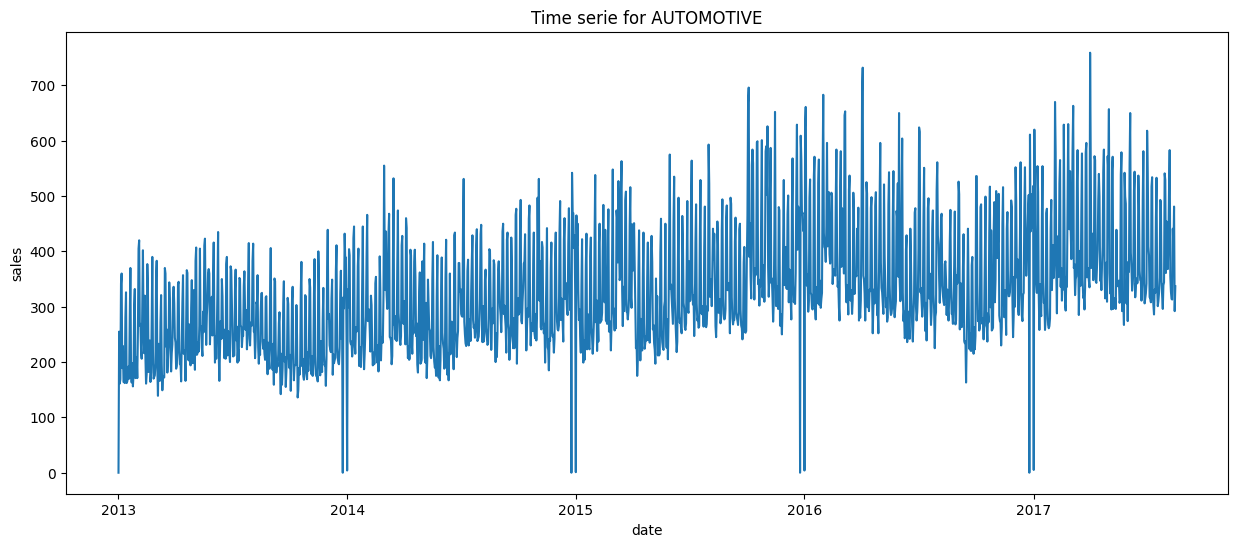

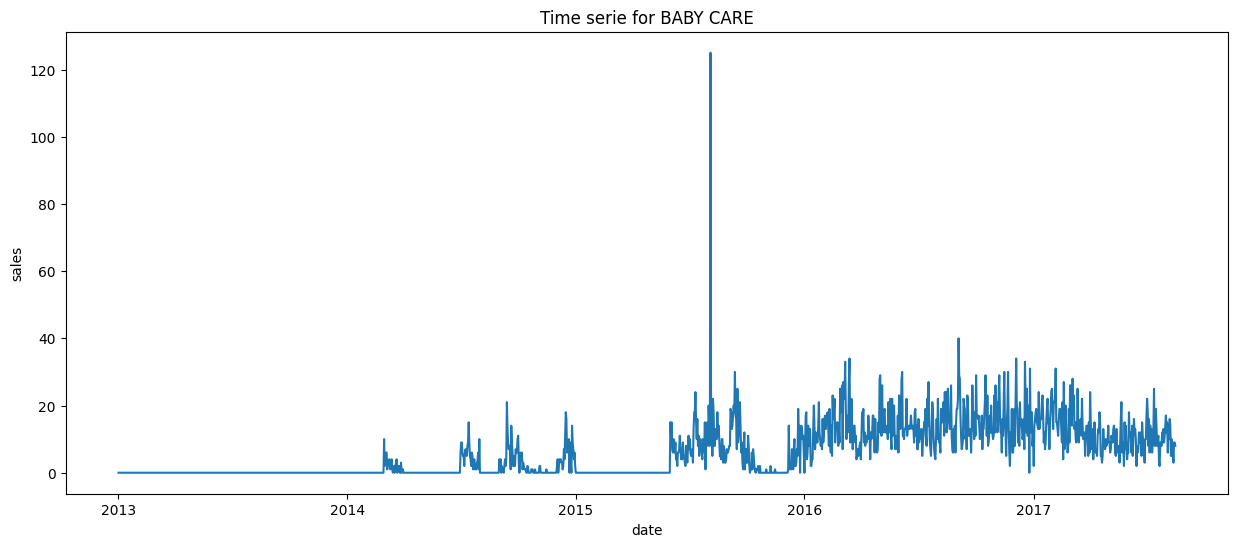

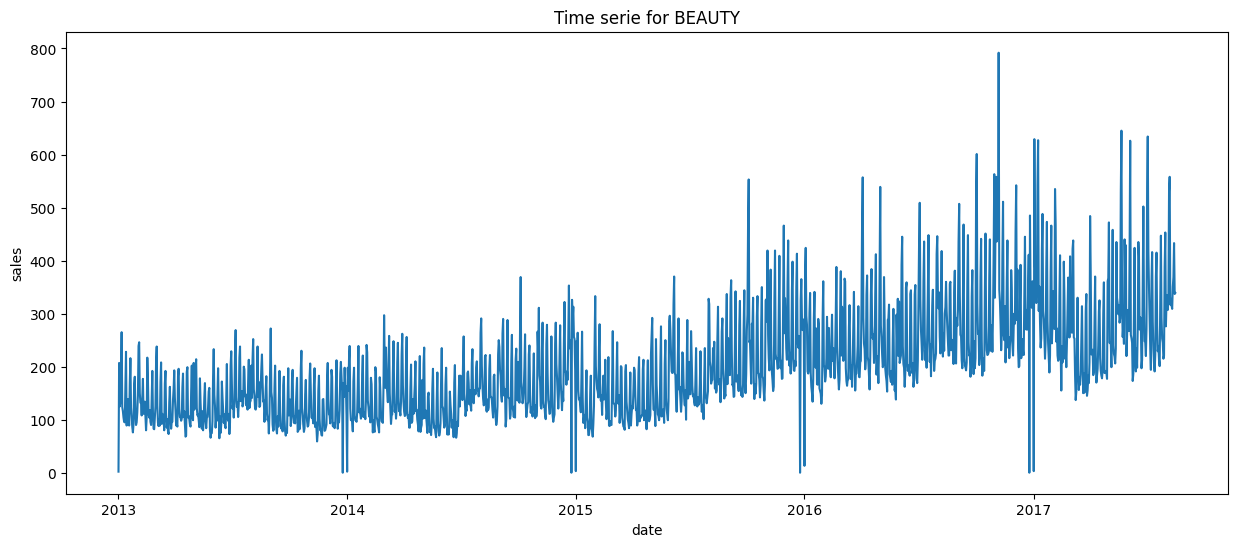

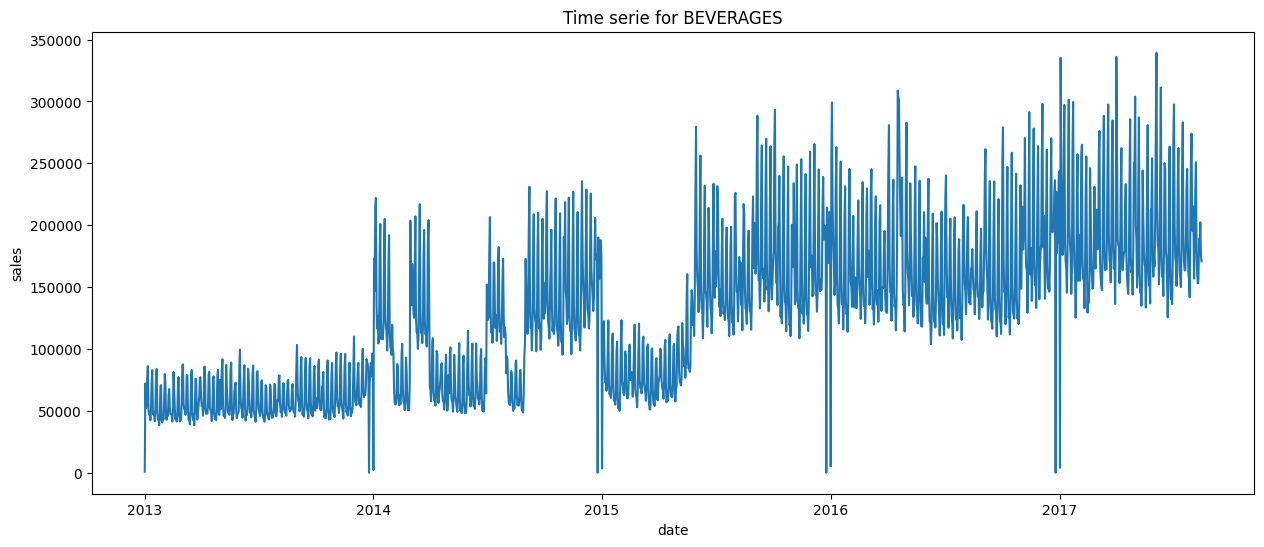

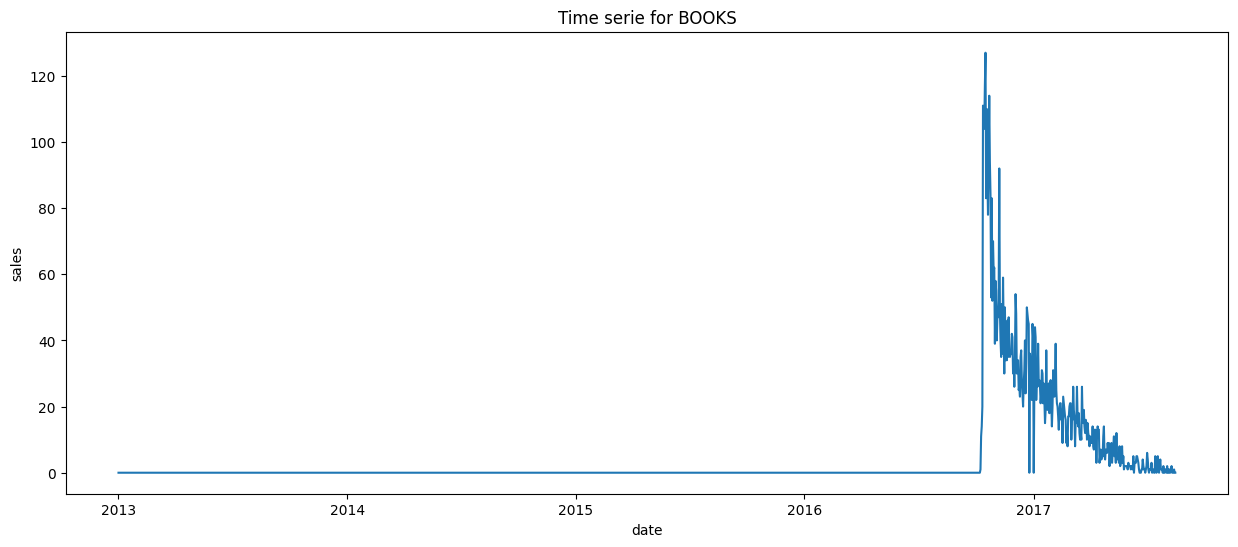

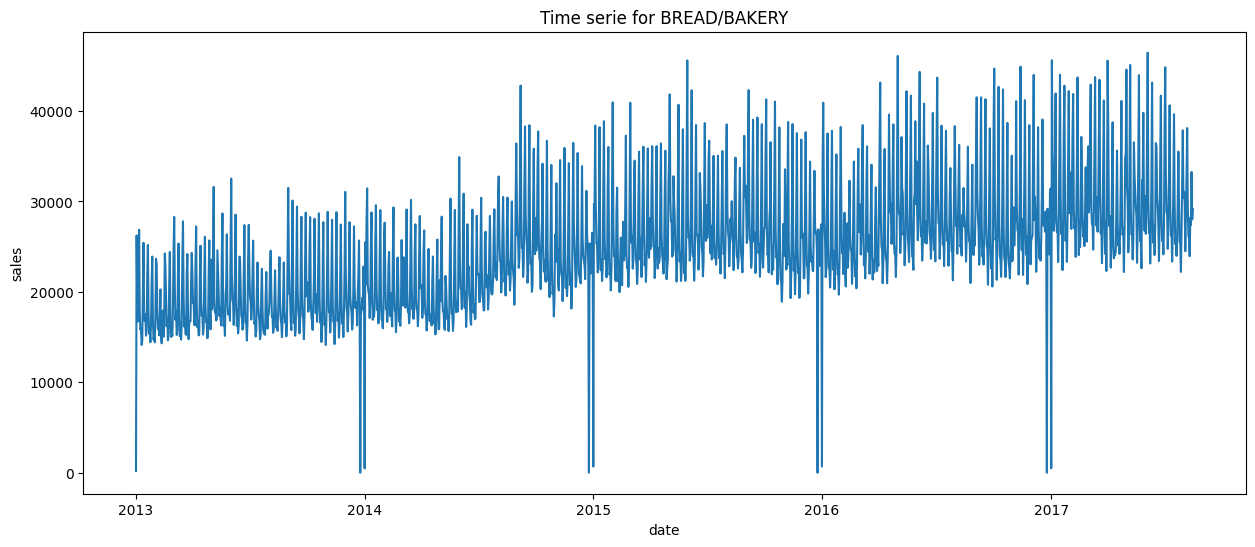

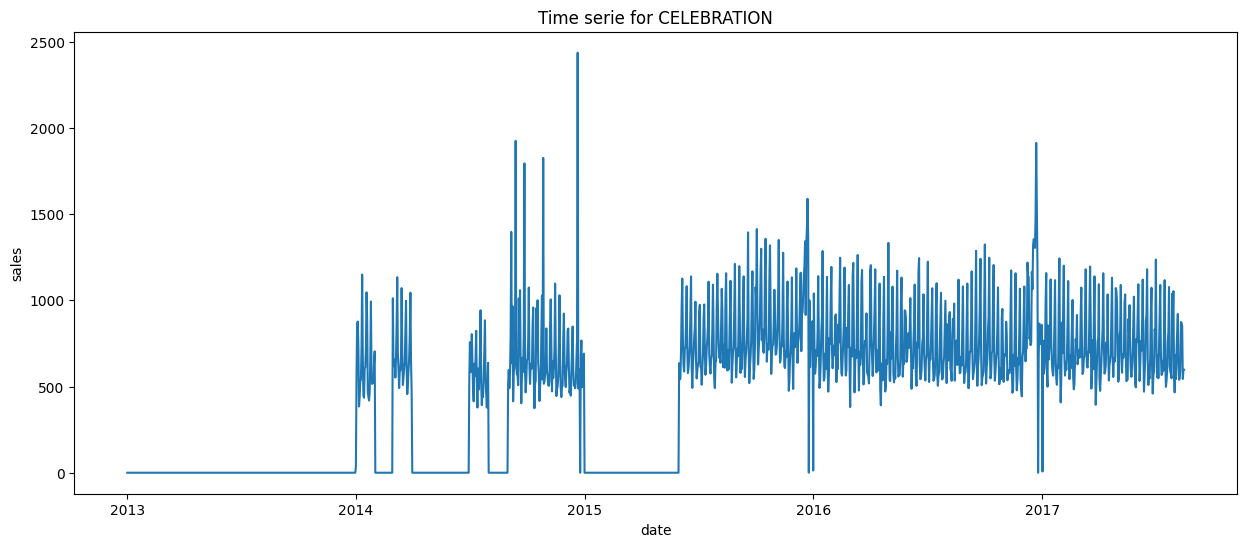

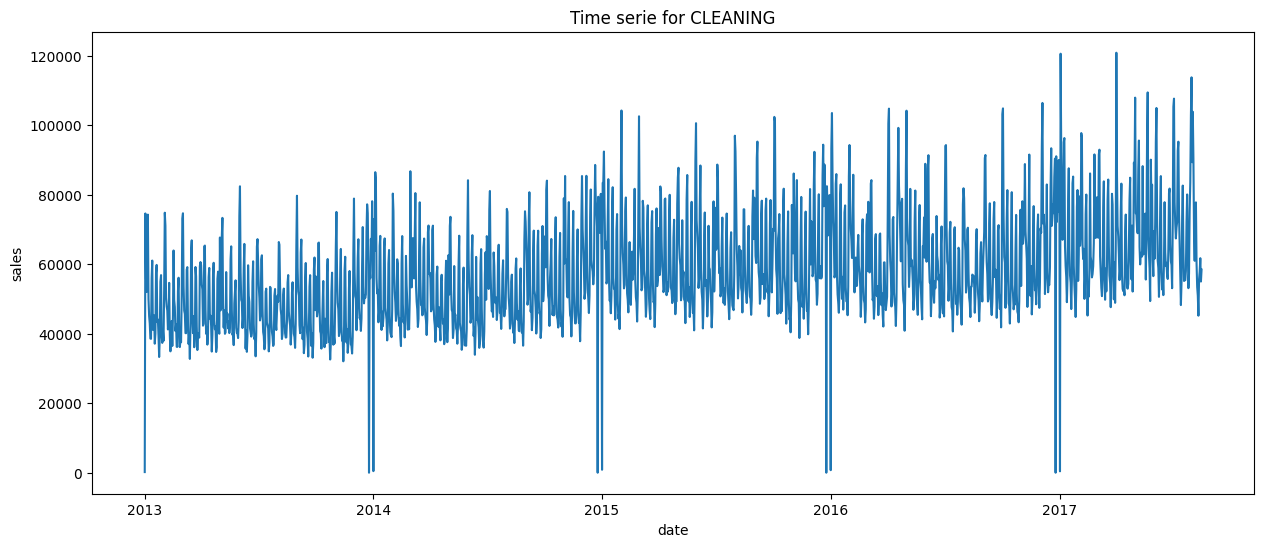

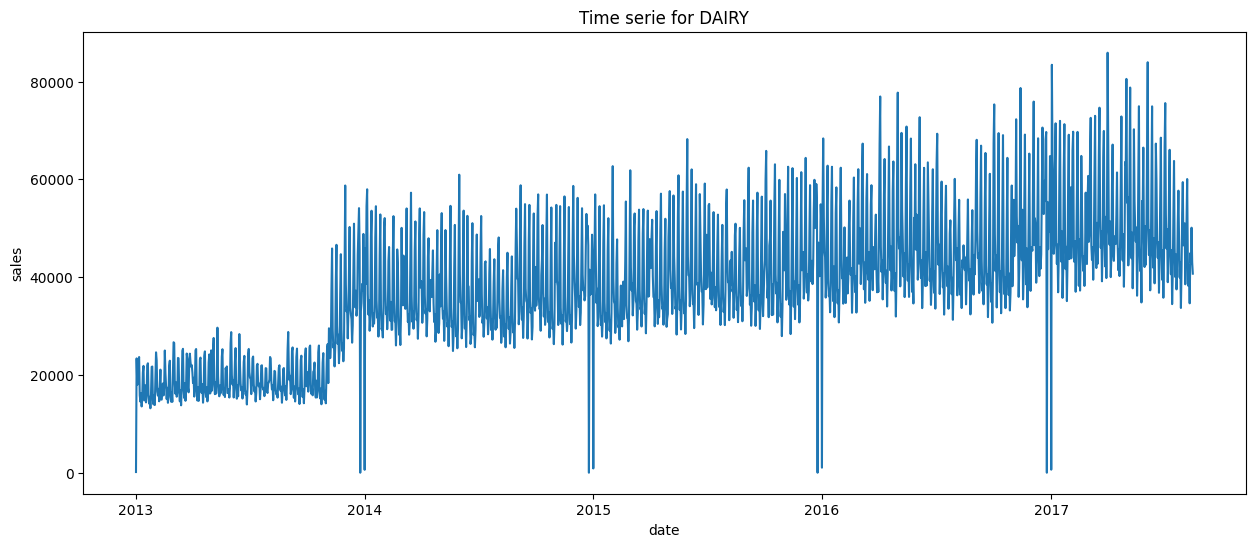

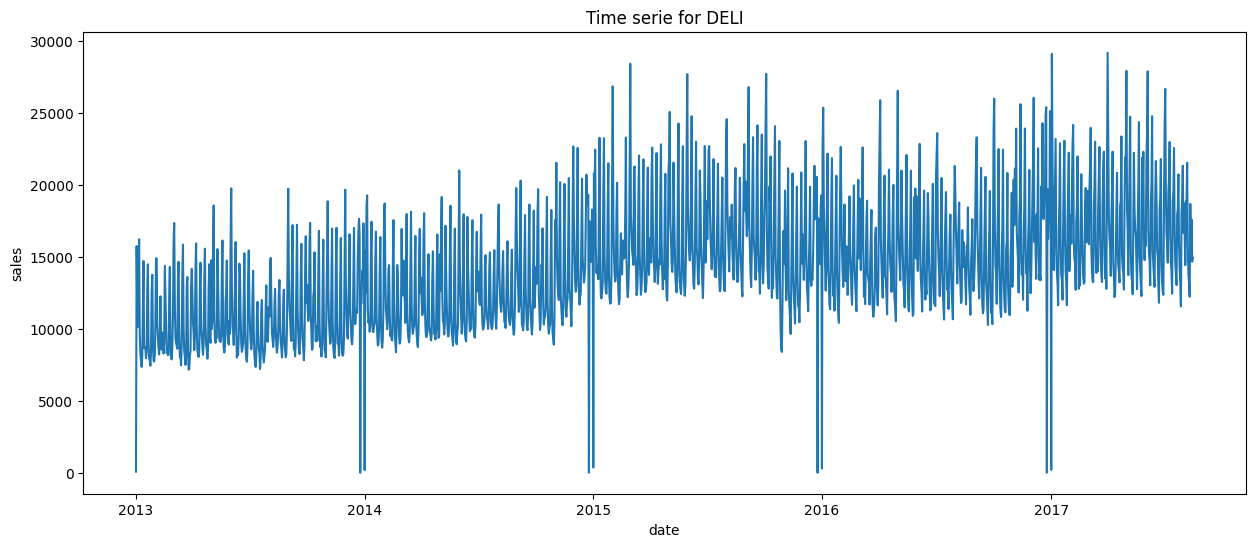

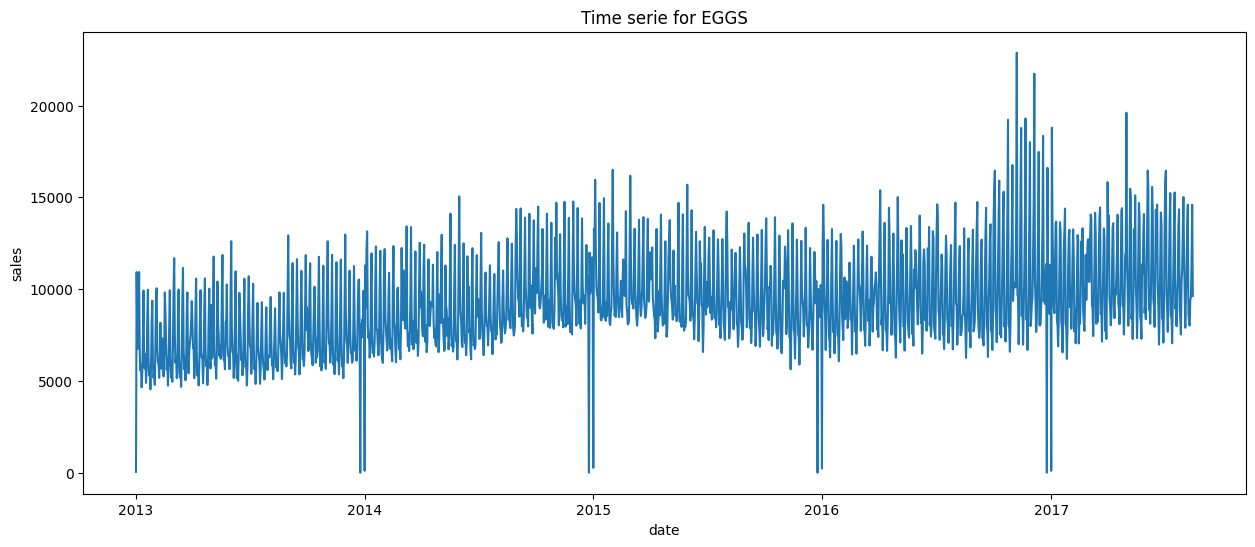

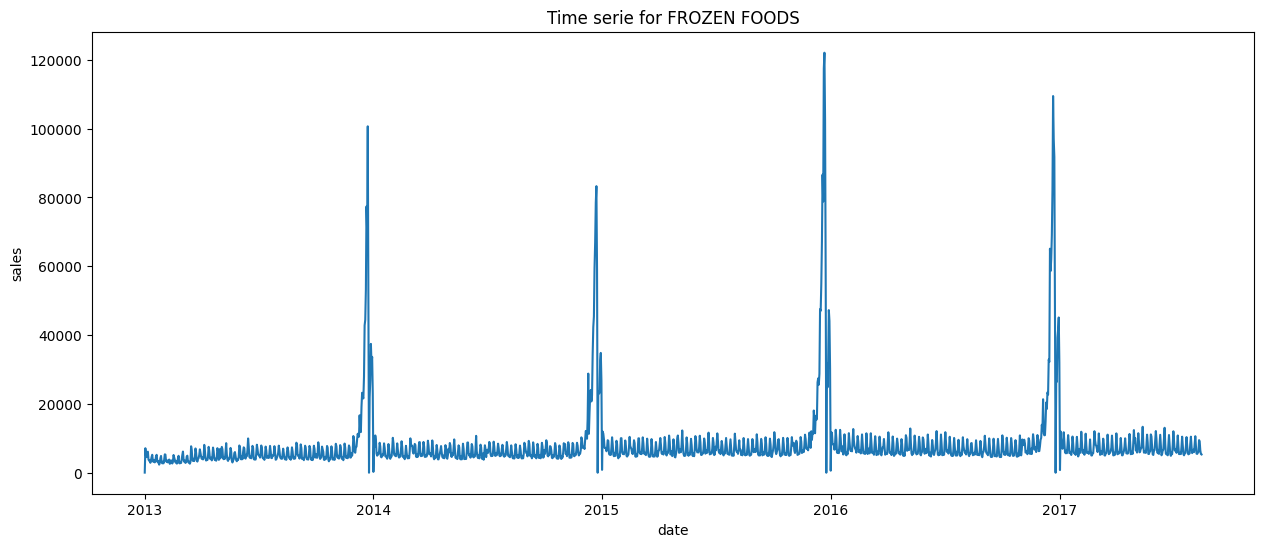

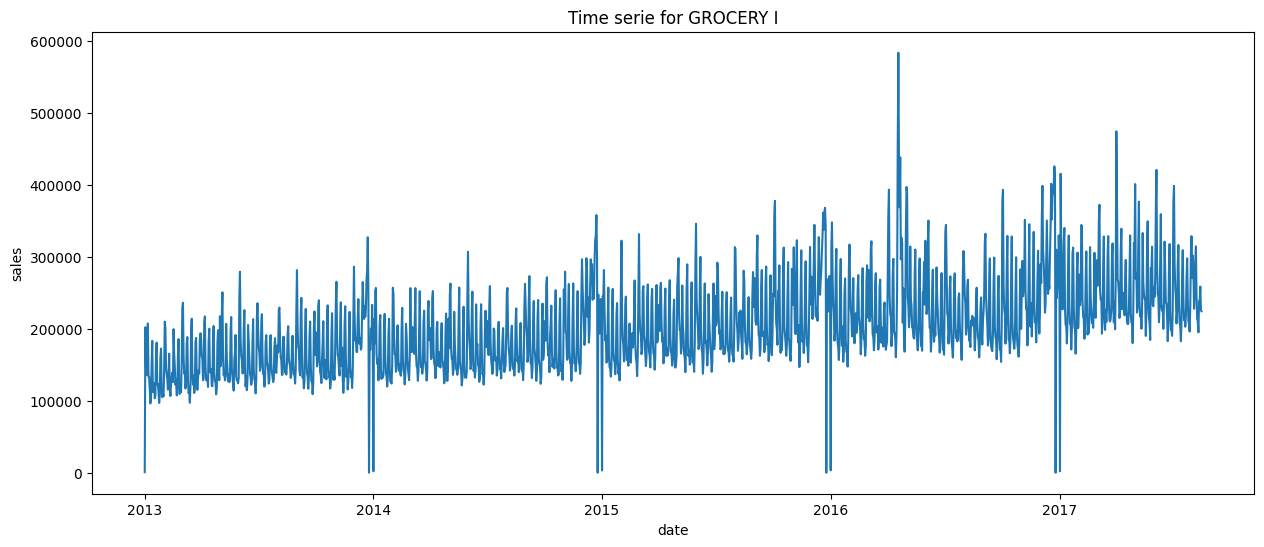

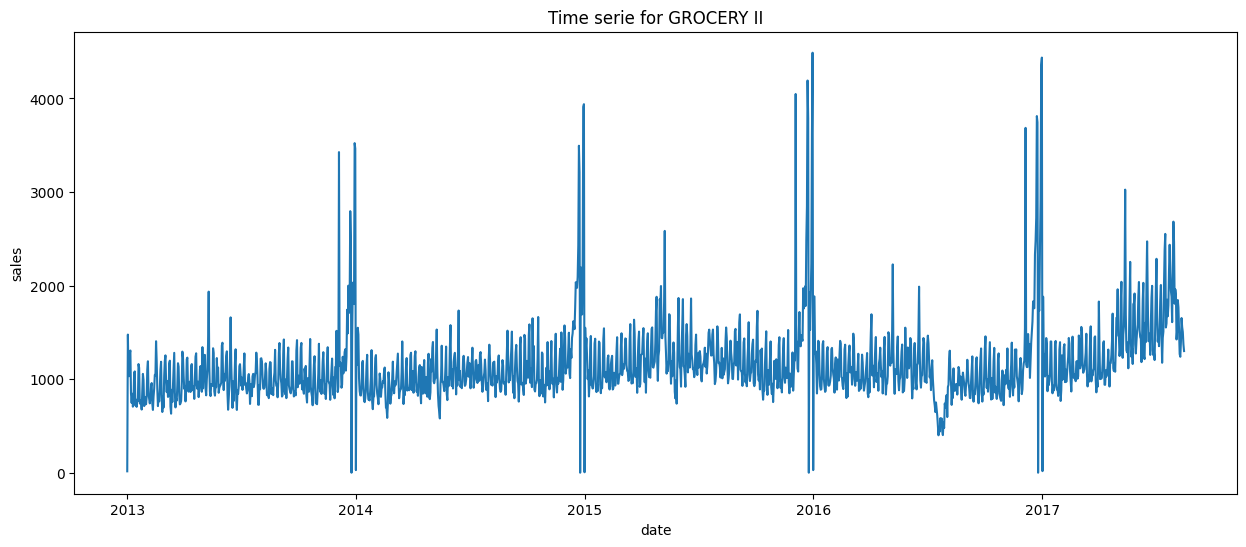

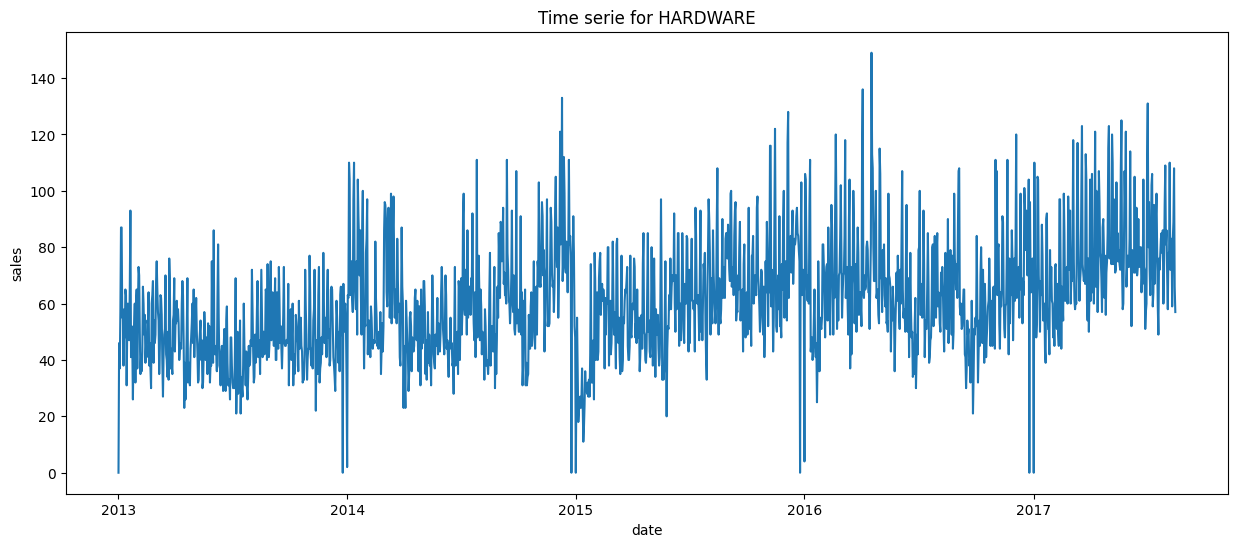

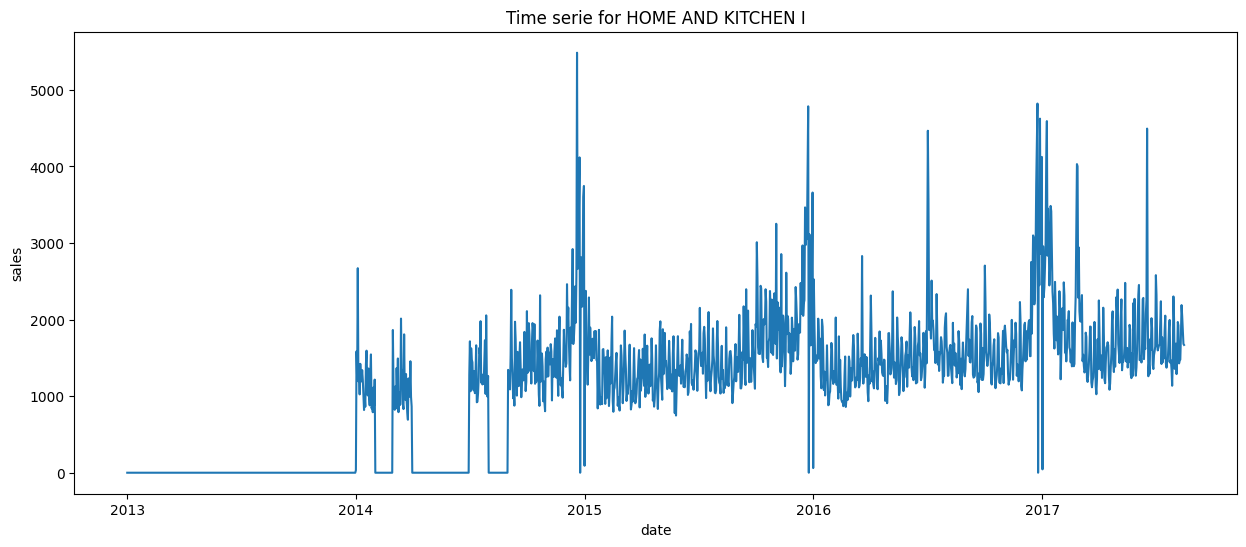

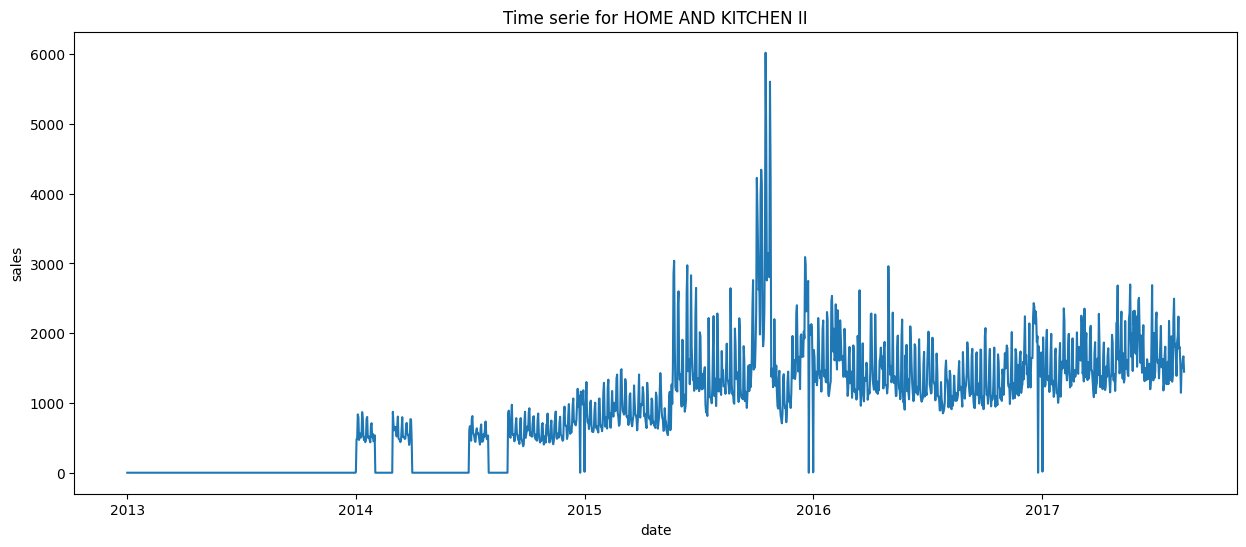

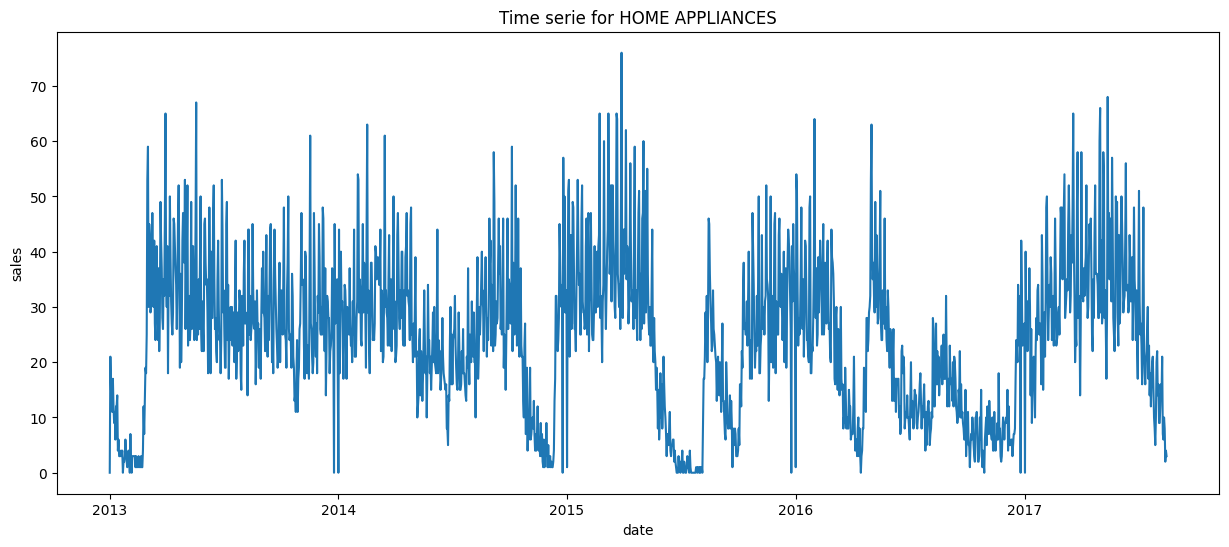

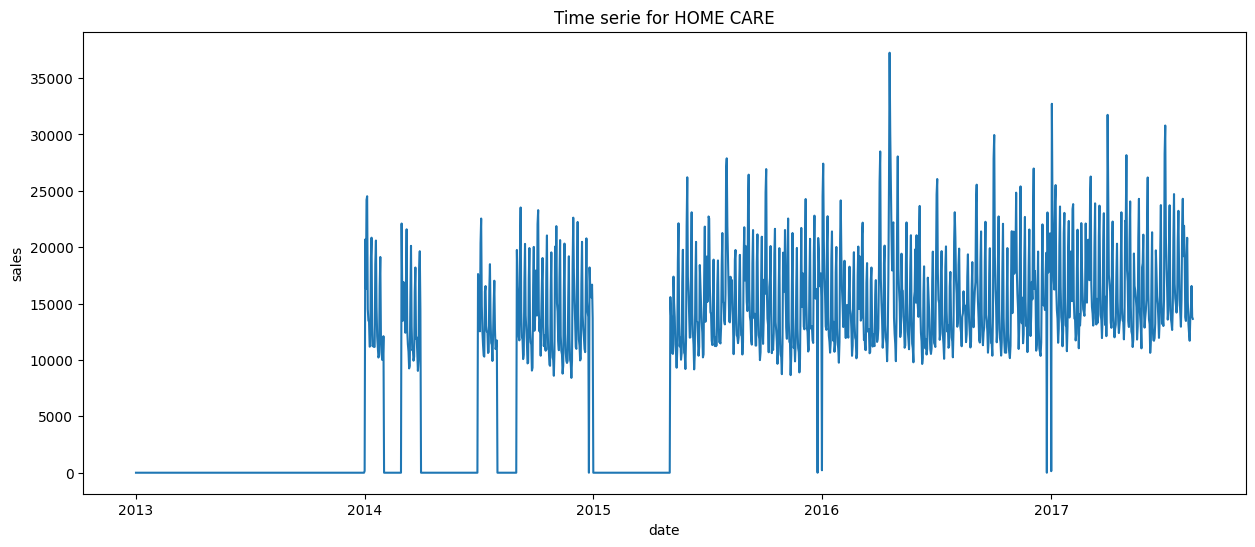

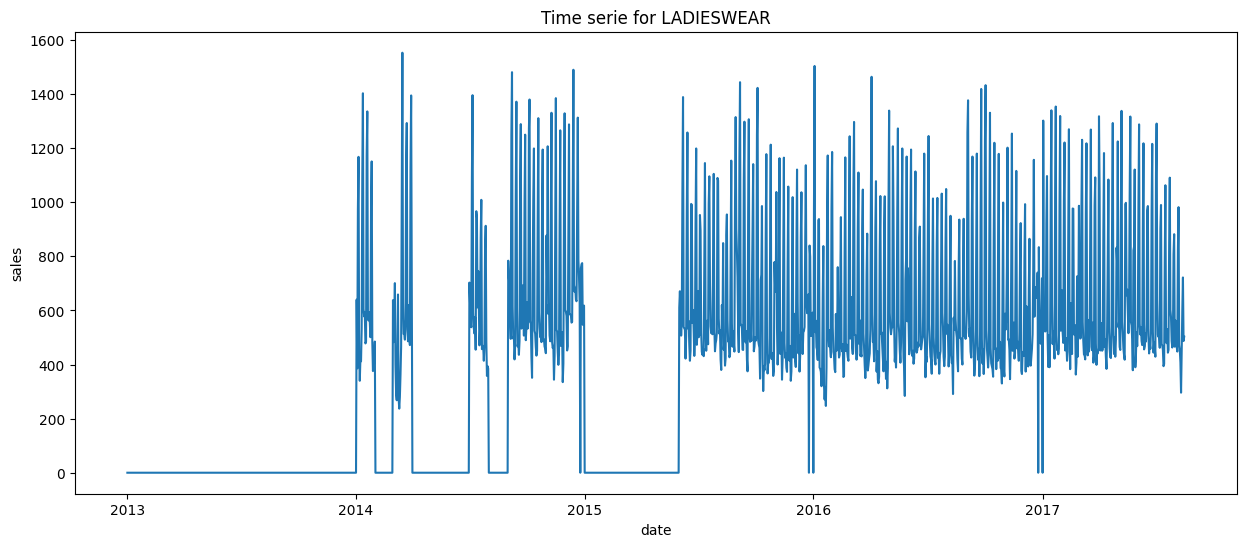

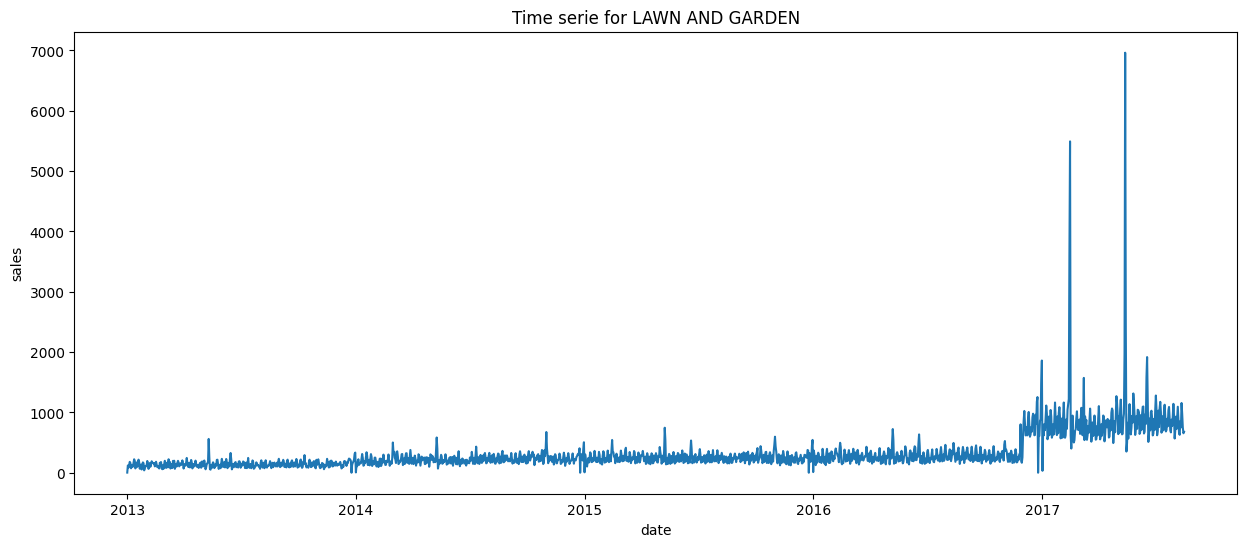

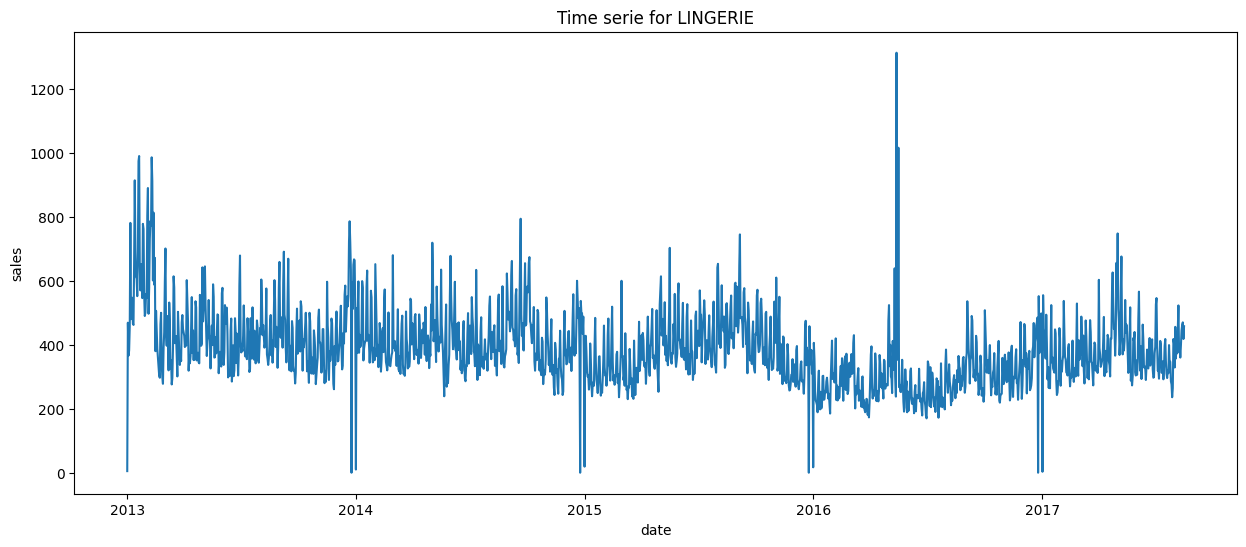

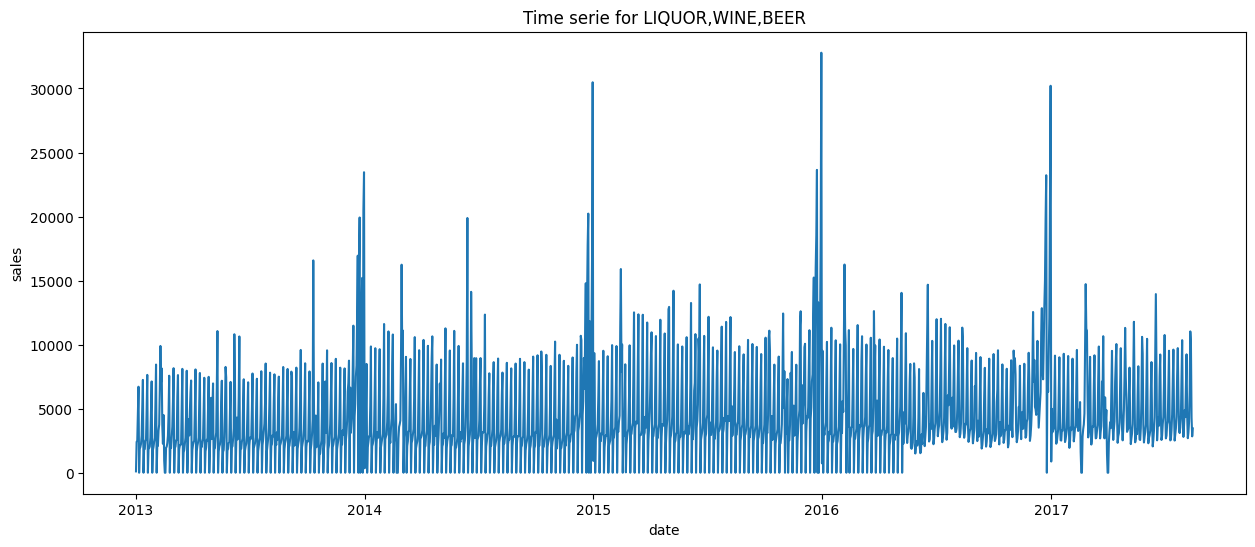

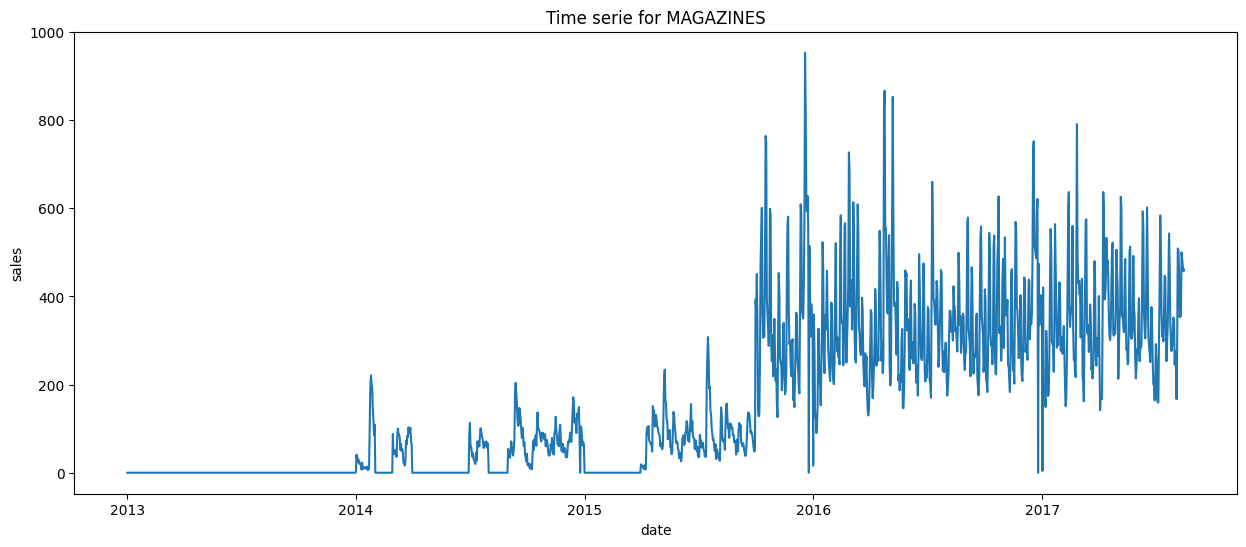

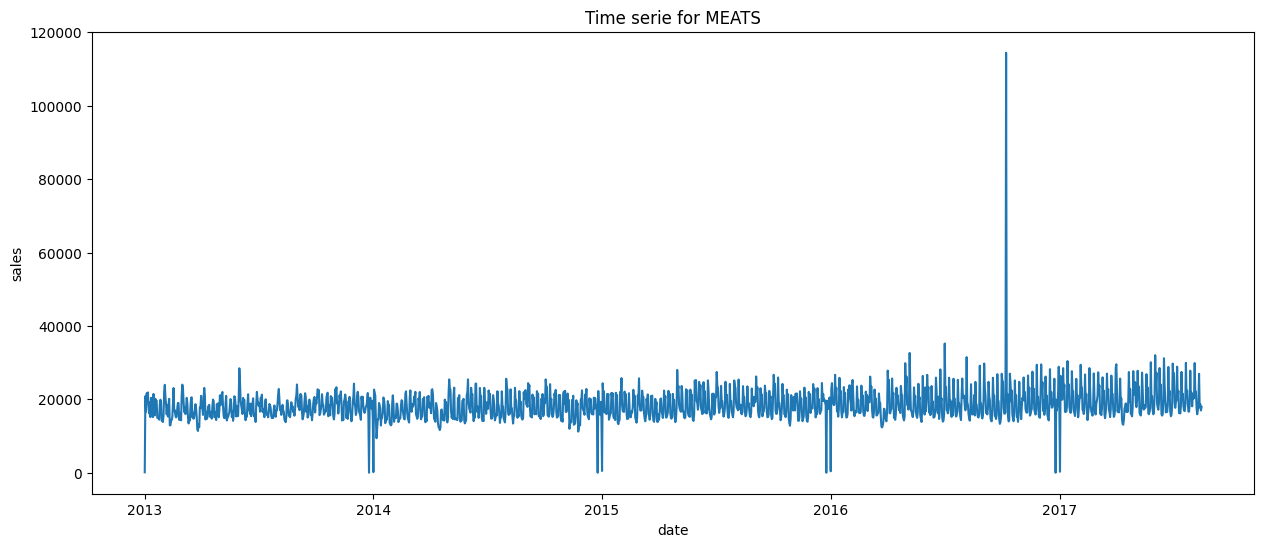

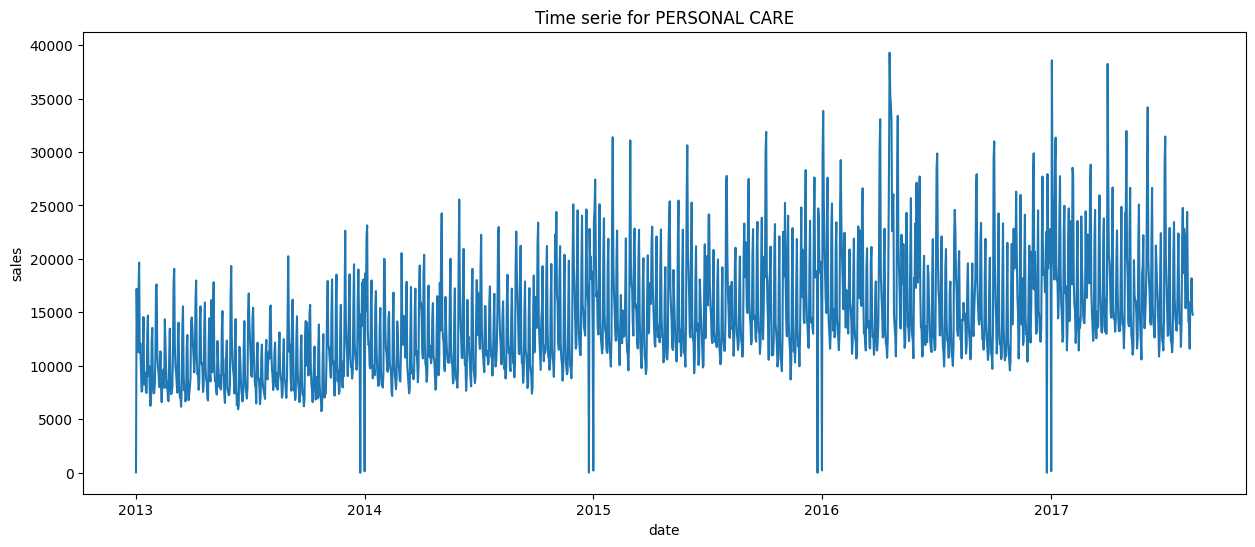

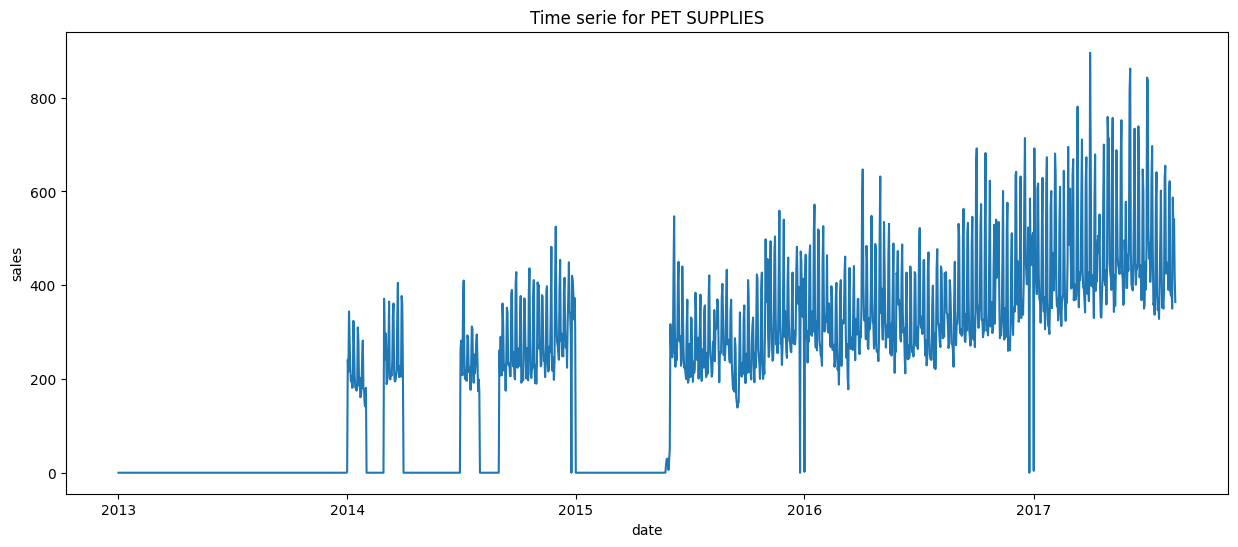

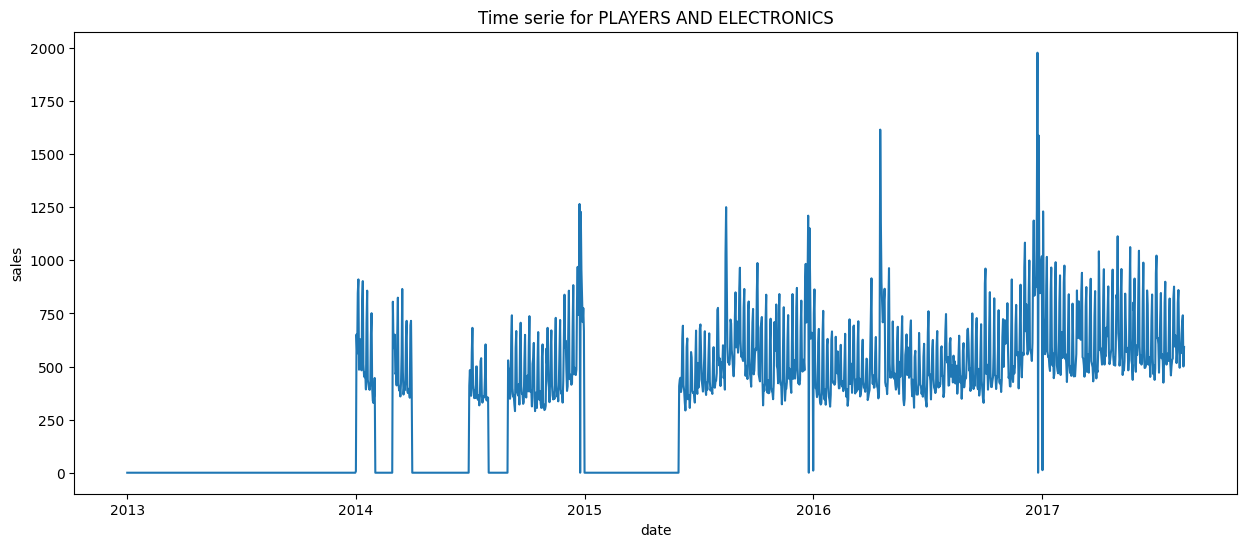

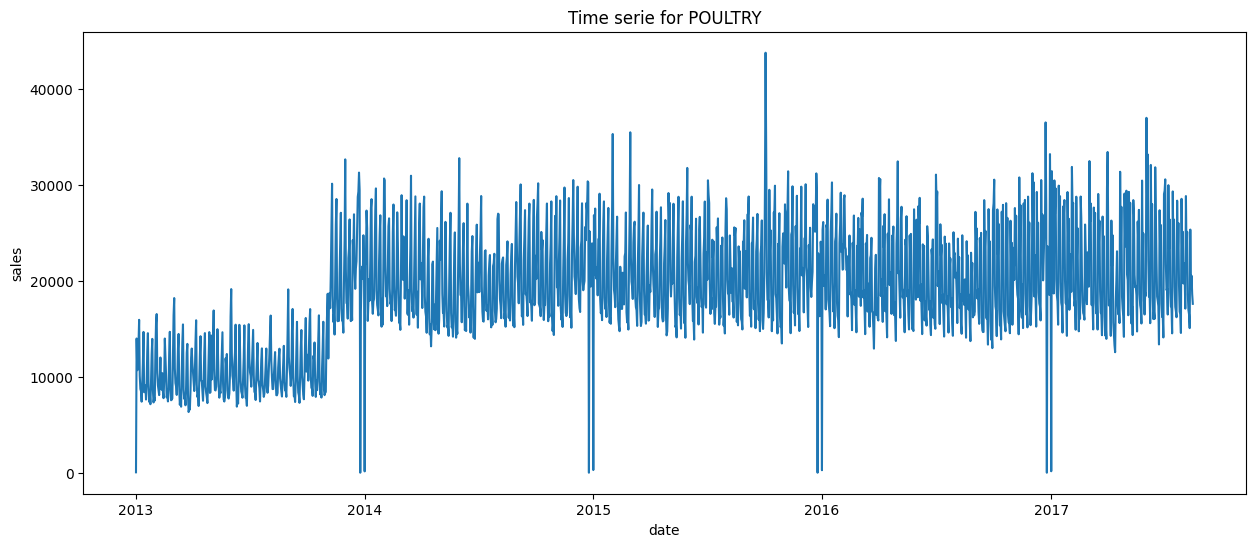

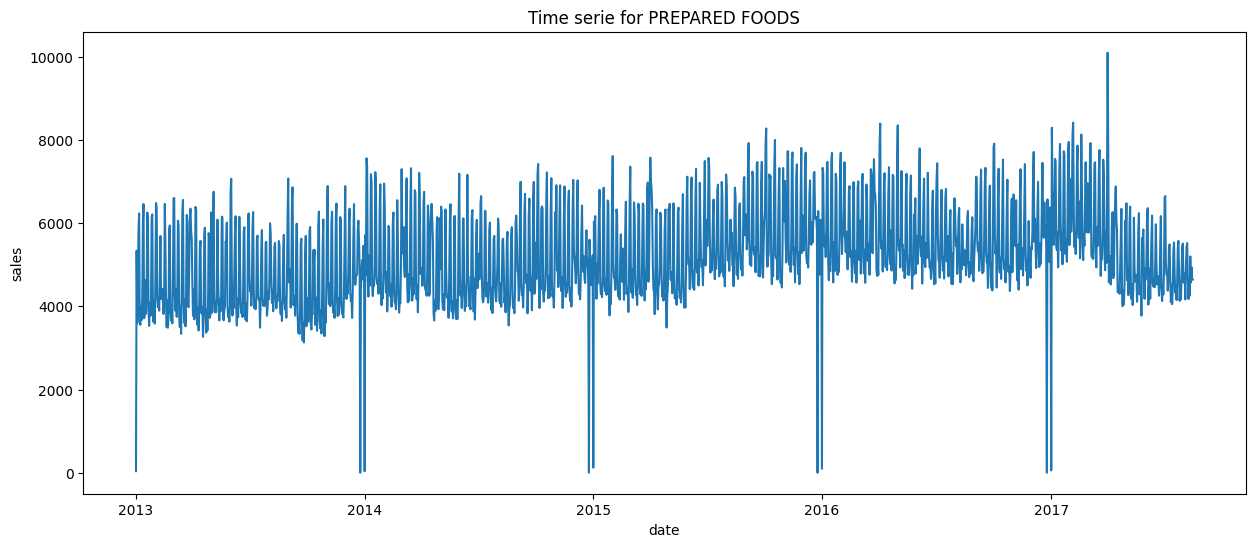

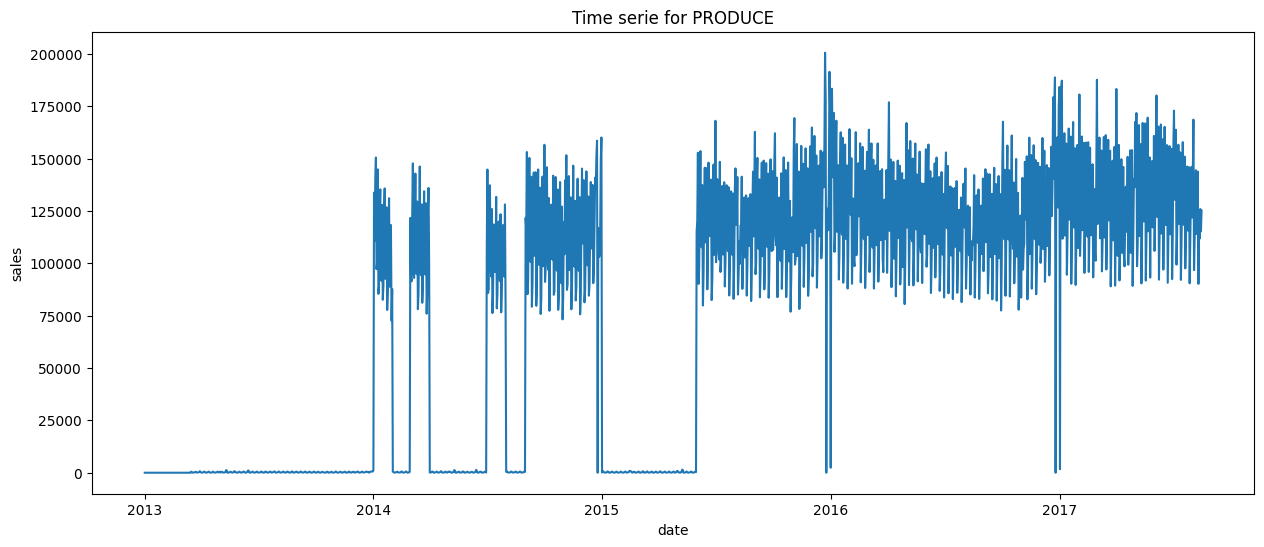

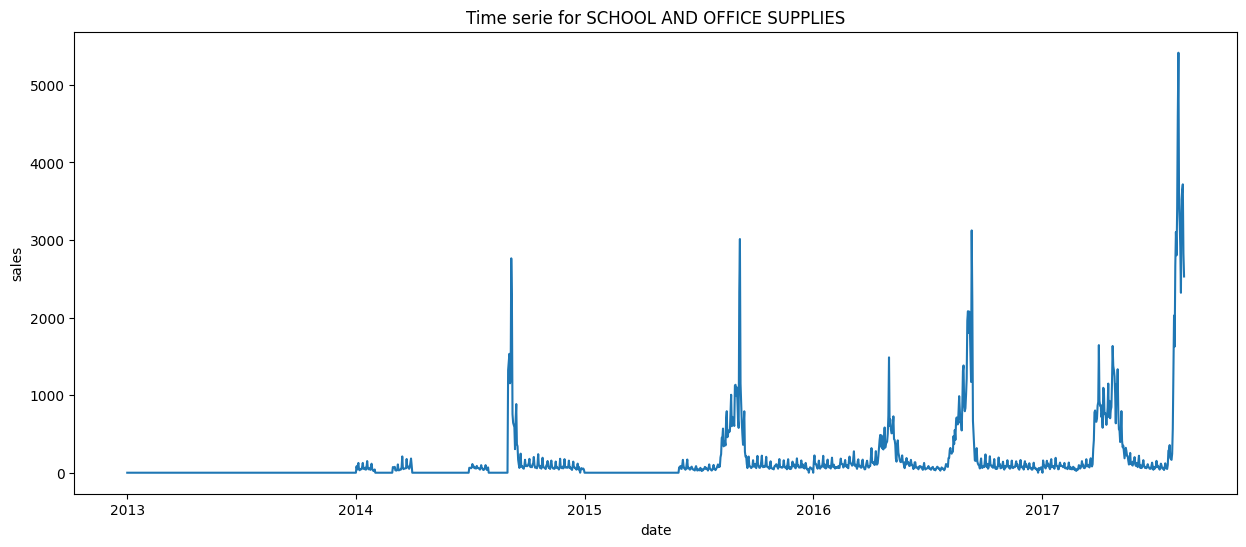

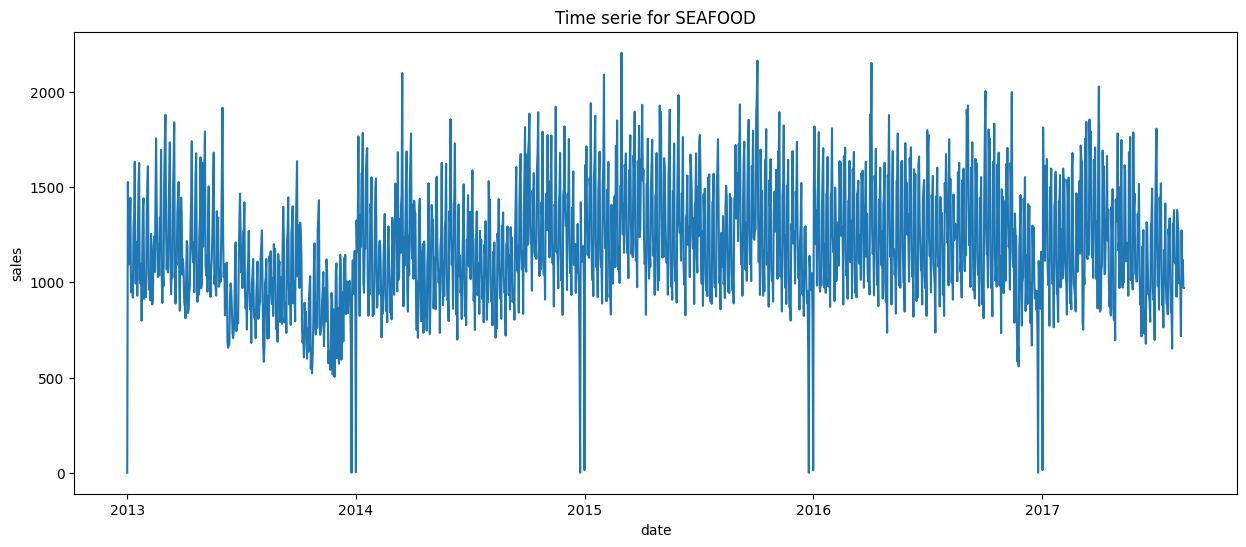

In [77]:
for family in all_families:
  family_data = data_agg[data_agg['family'] == family]

  plt.figure(figsize=(15, 6))
  sns.lineplot(data=family_data, x=family_data.index, y='sales')

  plt.title(f'Time serie for {family}')
  plt.show()

# Analysis

1. For AUTOMOTIVE, sales are always present, except for holidays. Also, recently (over 2016-2017), overall sales have increased. So, there is a general upward trend, and I think the model will benefit from all data from 2013 to the end. **Each year is cyclical, and a closer look (from 2016 to 2017) would be beneficial.**
2. For BABY CARE, there were no sales at all in 2013 and 2014. Then, with some interruptions, they continued until 2015, but quite poorly. The year 2015 is the strangest - the first part is a complete zero, then there is a sales growth, followed by a wild spike in a certain period (which needs to be identified), and then a collapse again towards the end. But from 2016 onwards, sales reach a plateau (with breaks for holidays when stores are closed). **It seems to make sense to consider this item only from 2016, when everything stabilized.**
3. **BEAUTY is similar to AUTOMOTIVE.** The conclusions are the same.
4. BEVERAGES are somewhat different from AUTOMOTIVE, in scale for example (**by the way, this suggests that a separate model can be trained for each item or group of items**), but in general, the data is quite stable and cyclical every year, with a general upward trend. I think it would be useful for the model to have all the data starting from 2013. **A closer look (from 2016 to 2017) is a good idea.**
5. BOOKS did not sell until the end of 2016, then a sharp sales boom occurred, and everything has been on the decline since. I think it would be useful for the model to know everything starting from the boom. **This is the period we will examine more closely.**
6. Bread/Bakery - the trend is upward, with cyclicity; everything is perfect. We will take a closer look from 2016 to 2017.
7. CELEBRATION - sales stabilized from mid-2015 (it feels as if Ecuador's economy was in a slump until mid-2015, or it's a data deficiency). This period should be given to the model. We can also examine 2016-2017. Seasonality is visible - a large purchase is made before the new year.
8. CLEANING - everything is stable, we give the model all the data. We will take a closer look at 2016-2017 (from now on, I will simply generalize this phrase to "ok").
9. DAIRY - upward trend, all data is useful, everything is stable in general. We will take a closer look at 2016-2017.
10. DELI - ok
11. EGGS - ok
12. FROZEN FOODS - interesting, cyclicity is clearly visible; it is clear that sales peak at the end of the year. In general, all the data will be useful for the models, we will take a closer look at 2016-2017.
13. GROCERY | everything is ok, but there is an outlier from 2016 to 2017 - we will examine it.
14. GROCERY II - everything is ok, there is a sales trend around the new year.
15. HARDWARE - ok.
16. HOME AND KITCHEN I - Sales stabilized from 2015, we can look from there. Everything else is ok.
17. HOME AND KITCHEN II - same as I
18. HOME APPLIANCES - ok.
19. HOME CARE - good data from mid-2015.
20. LADIESWEAR - good data from mid-2015.
21. LAWN AND GARDEN - interesting, everything was stable until the end of 2016, then there was growth with sharp spikes. I think the model will benefit from the most relevant data - from the end of 2016. This period can be examined in more detail.
22. LINGERIE - ok, with an outlier in 2016 (most likely related to the earthquake).
23. LIQUOR WINE BEER - ok, a lot of zeros are observed, and a sharp rise at the end of the year. A local approximation is definitely required.
24. MAGAZINES - stable from 2016.
25. MEATS - everything is ok, but there is an outlier during the earthquake.
26. PERSONAL CARE - everything is ok
27. PET SUPPLIES - ok from mid-2015.
28. PLAYERS AND ELECTRONICS - ok from mid-2015.
29. POULTRY - ok
30. PREPARED FOODS - ok, a downward trend recently.
31. PRODUCE - ok from mid-2015
32. SCHOOL AND OFFICE SUPPLIES - ok from mid-2015.
33. SEAFOOD - ok.

# Key Takeaways from the Analysis:


1. The target variable for each product can differ not only in type (discrete/continuous) but also in scale.
2. All products share one thing in common: they do not sell on holidays (the end of each year - I assume these are the New Year holidays, specifically December 25th and apparently January 1st - it seems even easier to simply assign a zero value automatically, without involving the model).
3. For a 15-day forecast (a short-term forecast), it is **especially important** to use the most recent and stable data. Old, unstable data is irrelevant to the current sales dynamics and can only harm the accuracy of the forecast.
4. Solution: A separate model can be trained for each product or group of products, as each target is unique. Clearly, good features will include the store's cluster, and it's also necessary to create features from the date, with `holiday` being the most important. Certain days like December 25th or January 1st can be handled separately.
5. Several products can be combined into a single group if their scale, target type, and trend allow it. We will examine the families in more detail.
6. In many cases, instability is observed until mid-2015. I don't yet understand what this is specifically related to; for now, I would simply not include all such data.
7. During further analysis, the following should be considered:
    - Wages in the public sector are paid every two weeks on the 15th and on the last day of the month. Supermarket sales could be affected by this. - This is very important, as the forecast period is exactly 15 days; I think this should even be included as a feature.
    - A magnitude 7.8 earthquake struck Ecuador on April 16, 2016. People rallied in relief efforts donating water and other first need products which greatly affected supermarket sales for several weeks after the earthquake. - It is necessary to add a feature like "was_earthquake" and also to examine the period of sales growth/decline because of this for each product.

Clearly, after examining the year, it's possible to discover even more localized periodicities, which is great - we need to localize as much as possible because our models must make a short-term (15-day) forecast.

# Series approximation, identification of patterns

### AUTOMOTIVE

In [78]:
automotive_data = data_agg[data_agg['family'] == 'AUTOMOTIVE']

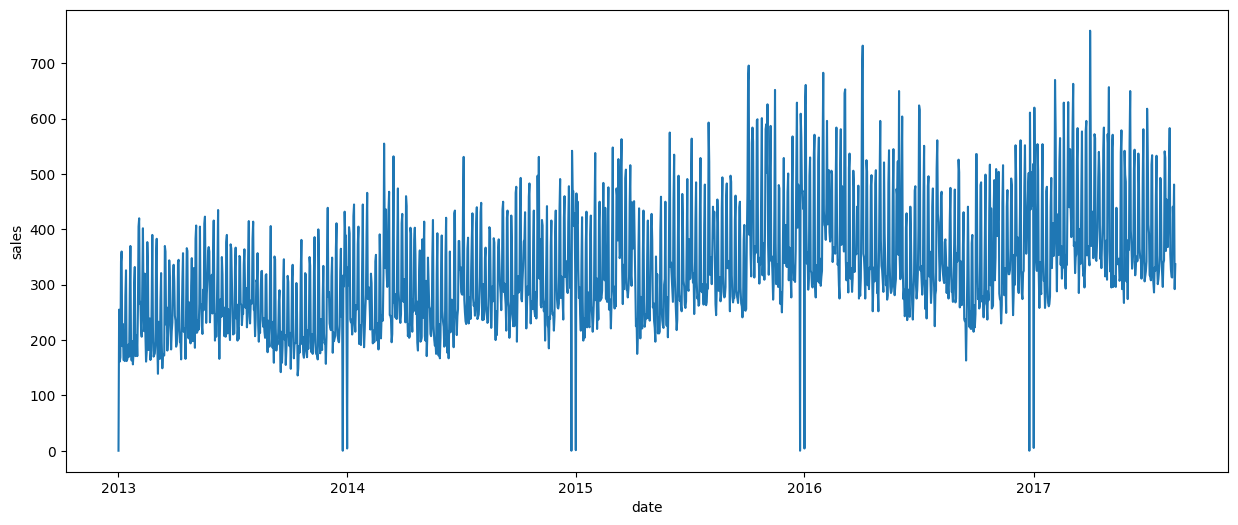

In [87]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=automotive_data, x=automotive_data.index, y='sales')
plt.show()

#### Year



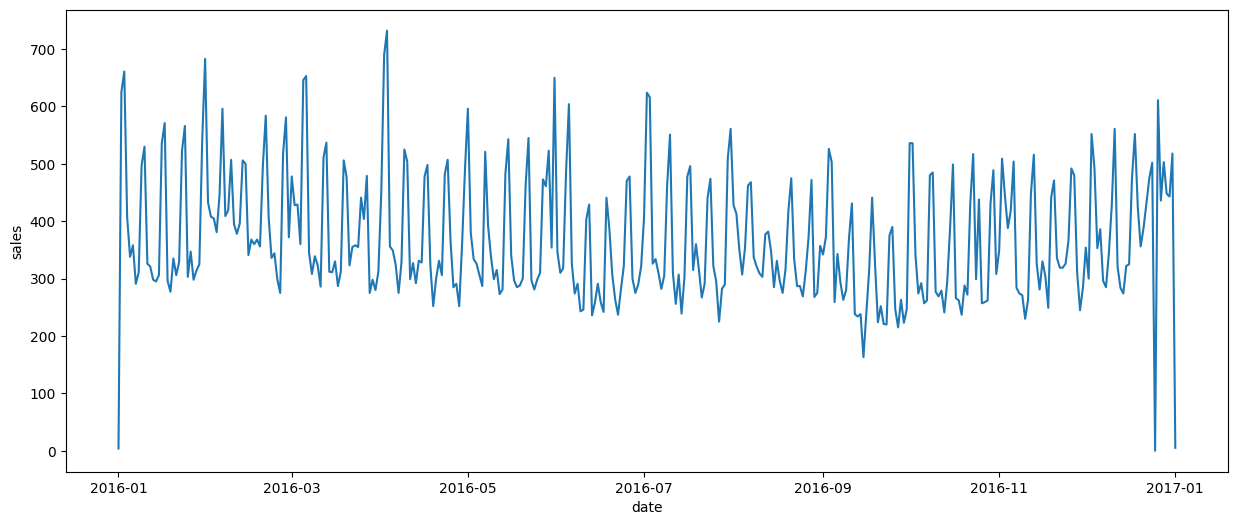

In [81]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=automotive_data['2016-01-01':'2017-01-01'], x=automotive_data['2016-01-01':'2017-01-01'].index, y='sales')
plt.show()

#### Six months

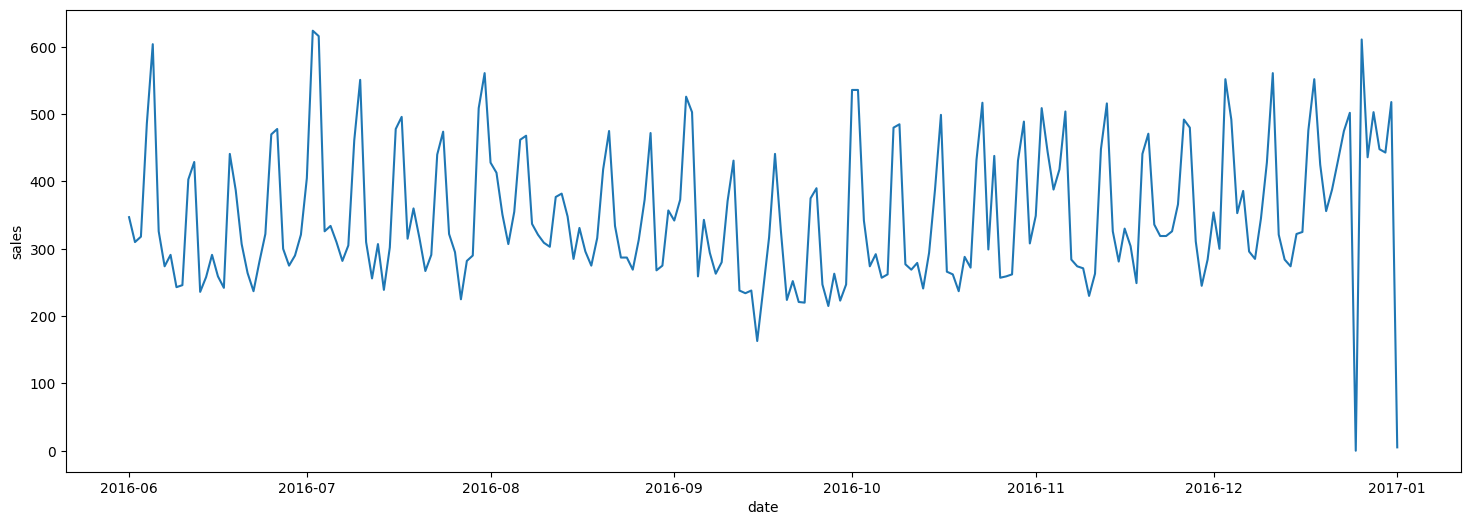

In [88]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=automotive_data['2016-06-01':'2017-01-01'],
    x=automotive_data['2016-06-01':'2017-01-01'].index,
    y='sales')
plt.show()

#### Month

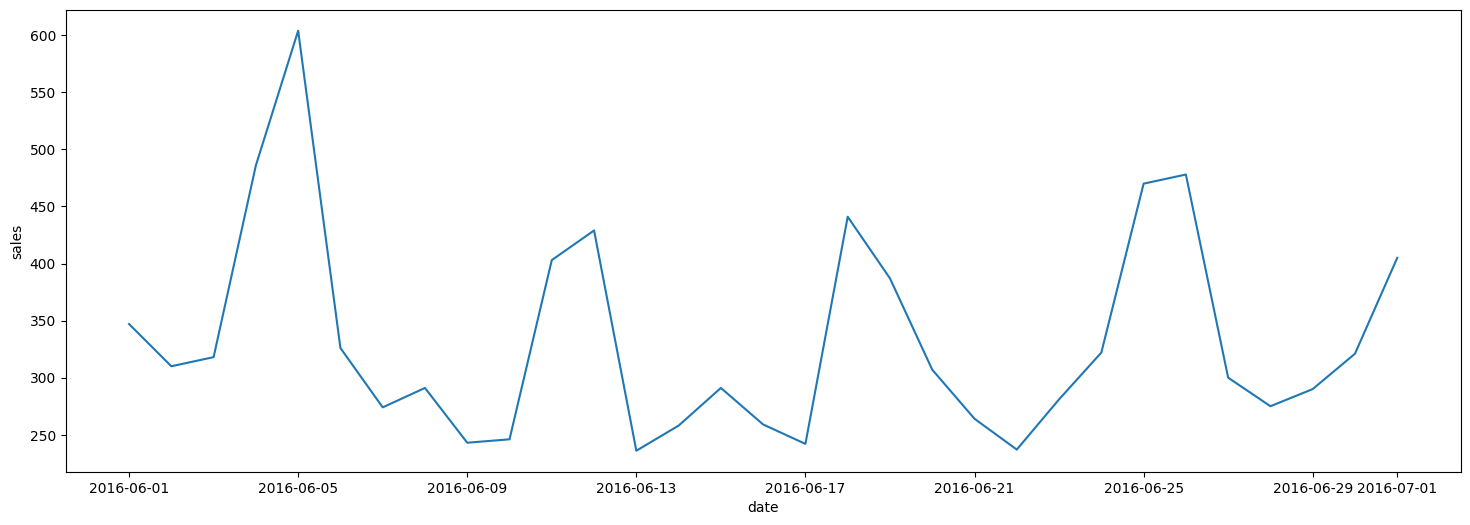

In [84]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=automotive_data['2016-06-01':'2016-07-01'],
    x=automotive_data['2016-06-01':'2016-07-01'].index,
    y='sales')
plt.show()

#### 15 days

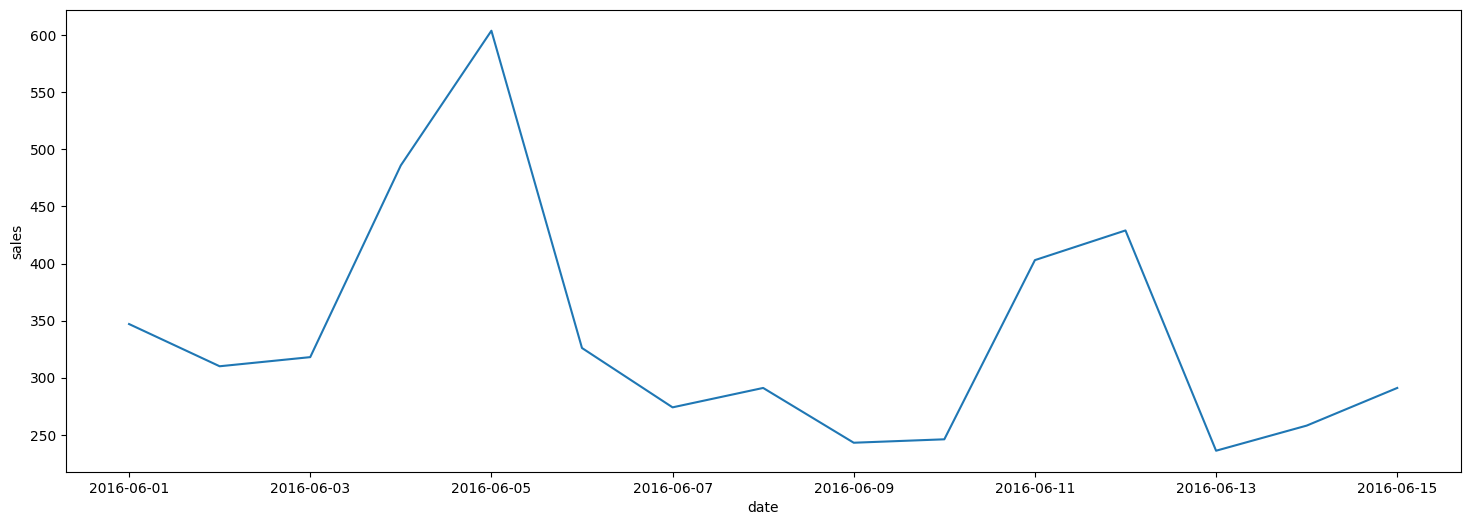

In [121]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=automotive_data['2016-06-01':'2016-06-15'],
    x=automotive_data['2016-06-01':'2016-06-15'].index,
    y='sales')
plt.show()

#### Week

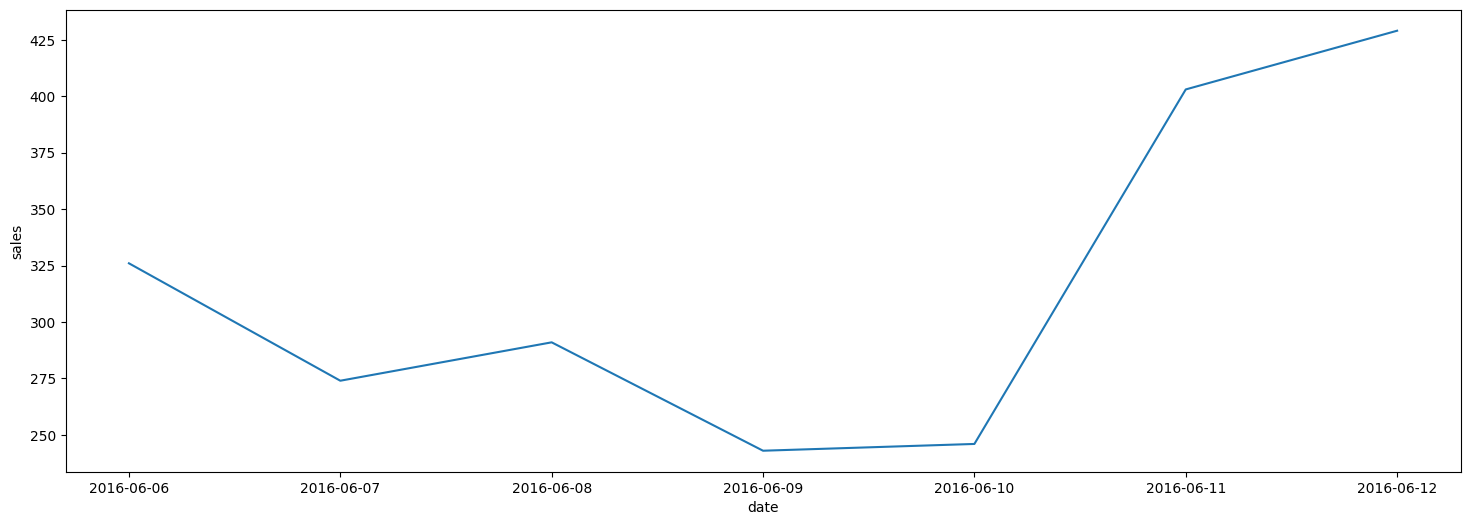

In [122]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=automotive_data['2016-06-06':'2016-06-12'],
    x=automotive_data['2016-06-06':'2016-06-12'].index,
    y='sales')
plt.show()

#### dec - jan

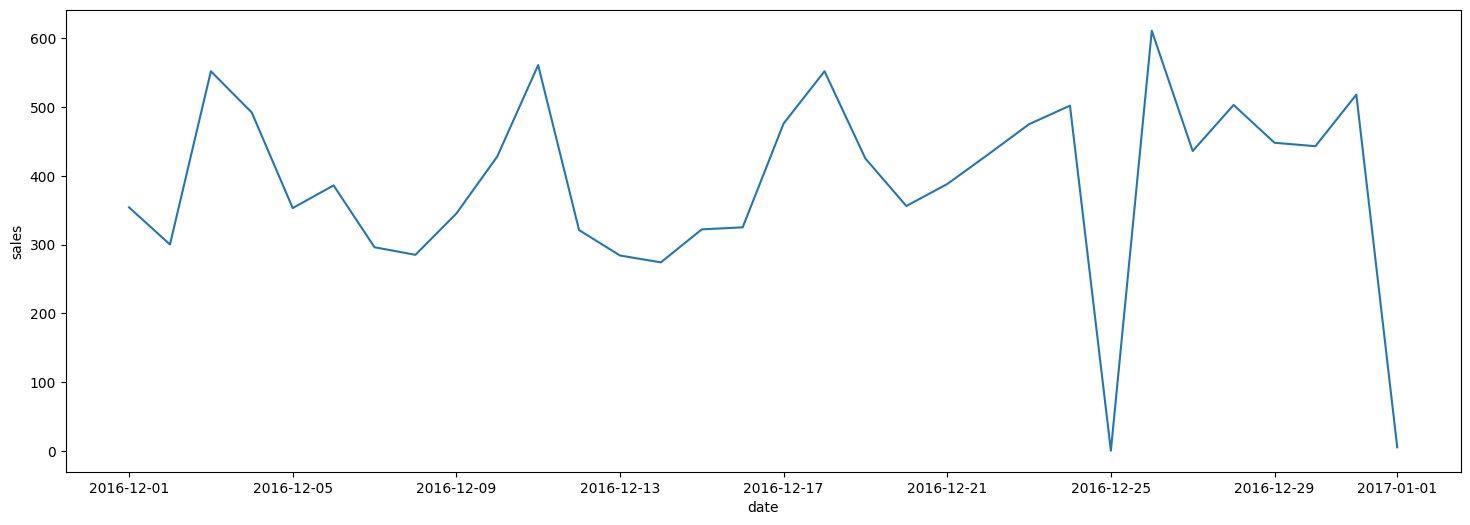

In [89]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=automotive_data['2016-12-01':'2017-01-01'],
    x=automotive_data['2016-12-01':'2017-01-01'].index,
    y='sales')
plt.show()

### BABY CARE

In [95]:
baby_care_data = data_agg[data_agg['family'] == 'BABY CARE']['2016-01-01':]

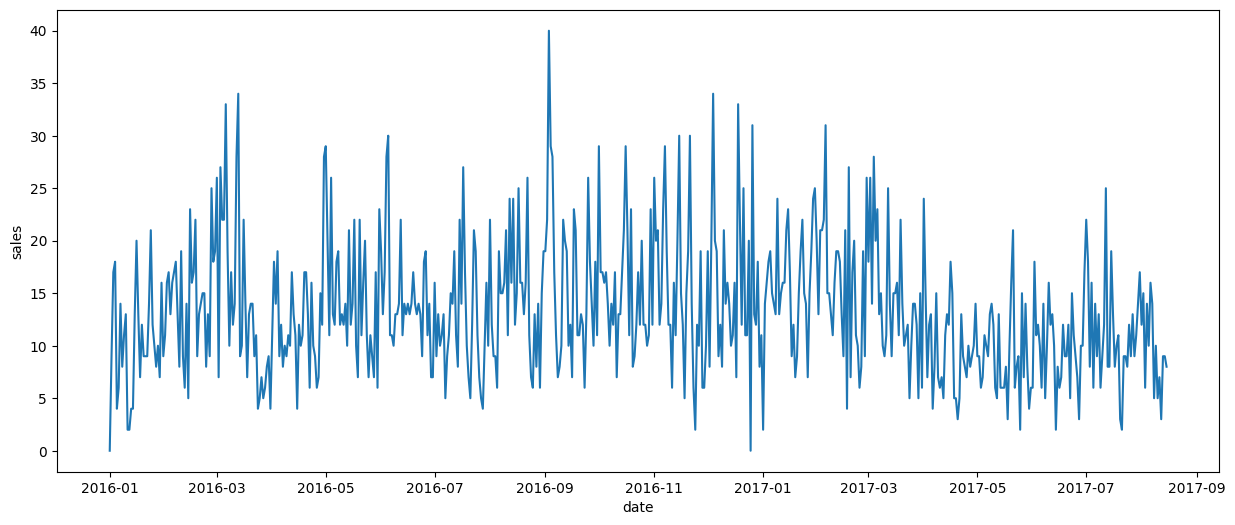

In [96]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=baby_care_data, x=baby_care_data.index, y='sales')
plt.show()

#### Year



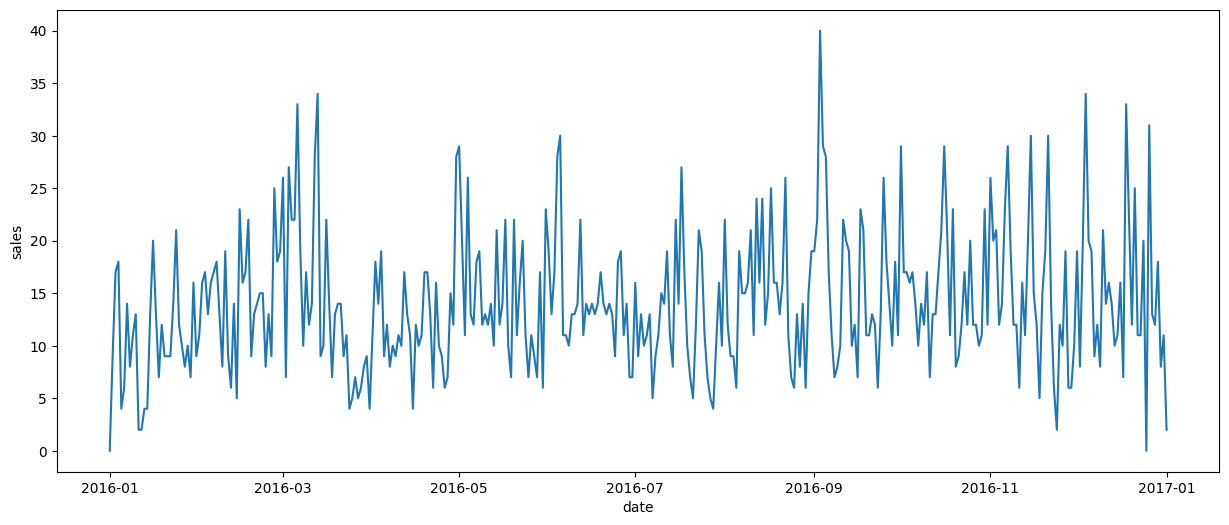

In [97]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=baby_care_data['2016-01-01':'2017-01-01'],
             x=baby_care_data['2016-01-01':'2017-01-01'].index,
             y='sales')
plt.show()

#### Six months

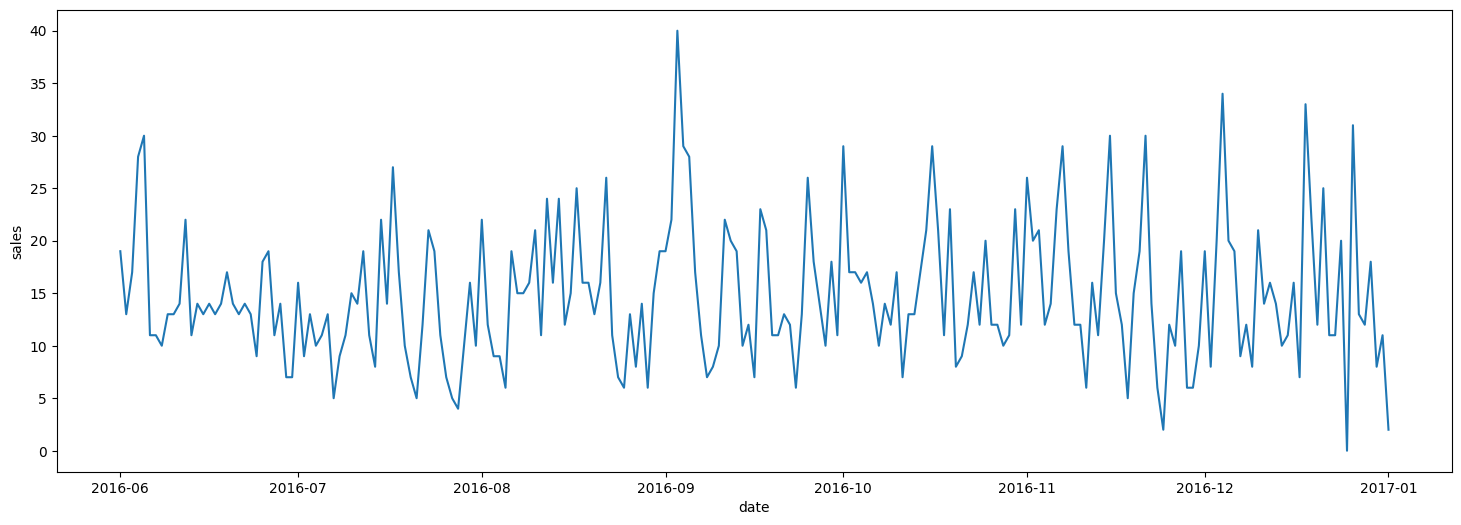

In [99]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=baby_care_data['2016-06-01':'2017-01-01'],
    x=baby_care_data['2016-06-01':'2017-01-01'].index,
    y='sales')
plt.show()

#### Month

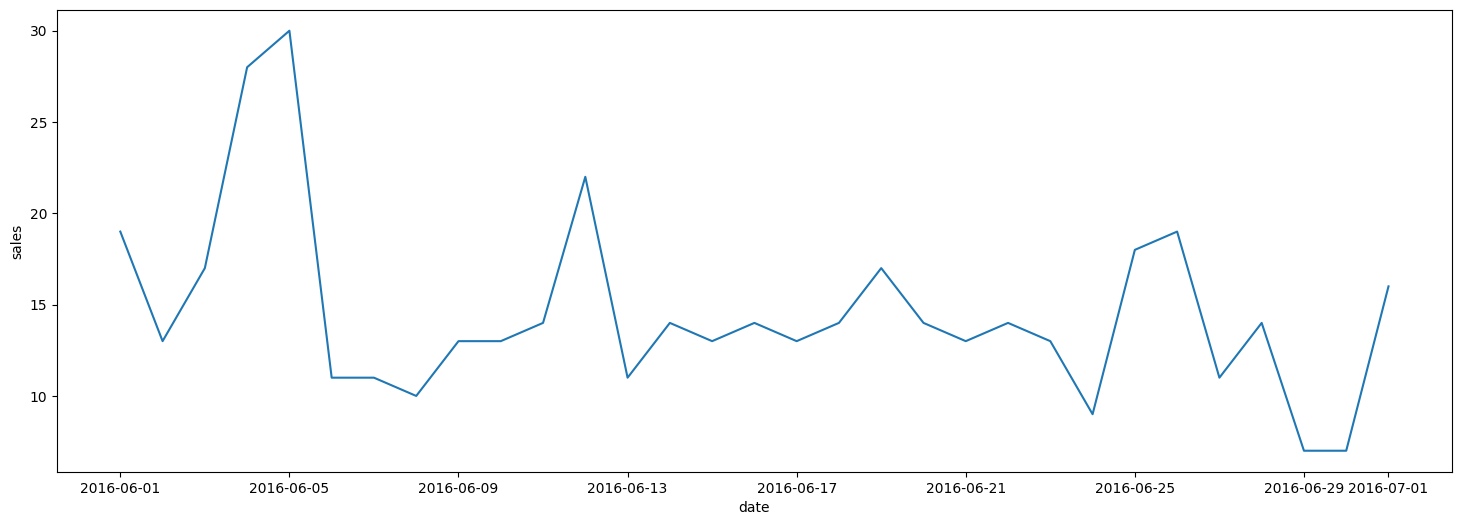

In [115]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=baby_care_data['2016-06-01':'2016-07-01'],
    x=baby_care_data['2016-06-01':'2016-07-01'].index,
    y='sales')
plt.show()

#### 15 days

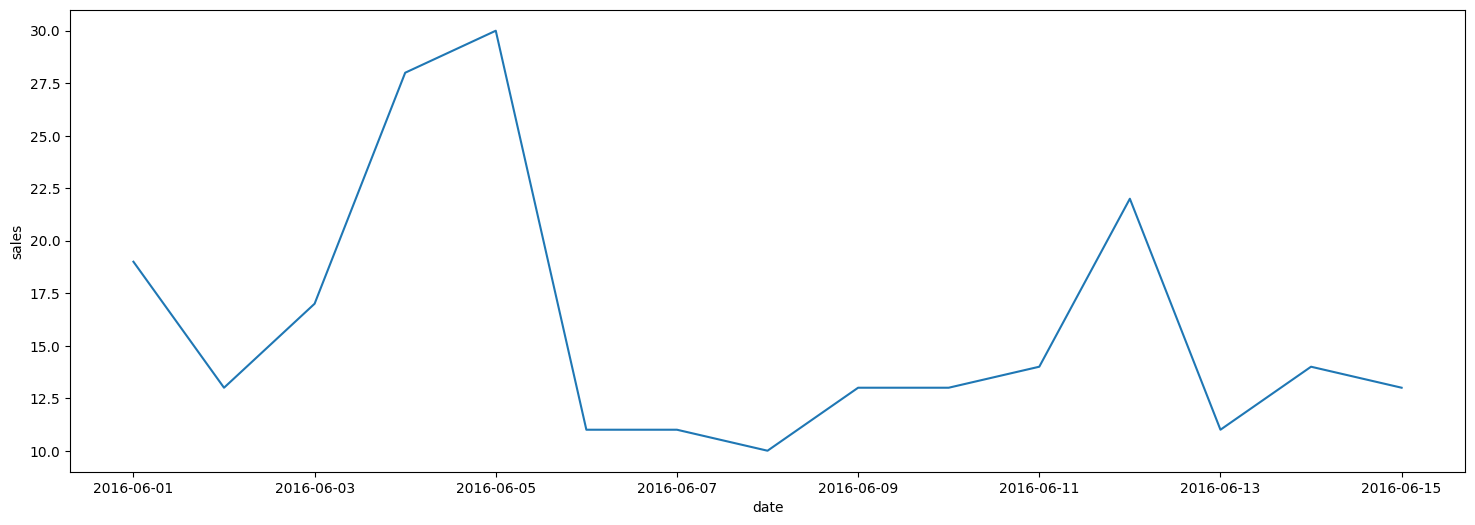

In [123]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=baby_care_data['2016-06-01':'2016-06-15'],
    x=baby_care_data['2016-06-01':'2016-06-15'].index,
    y='sales')
plt.show()

#### Week

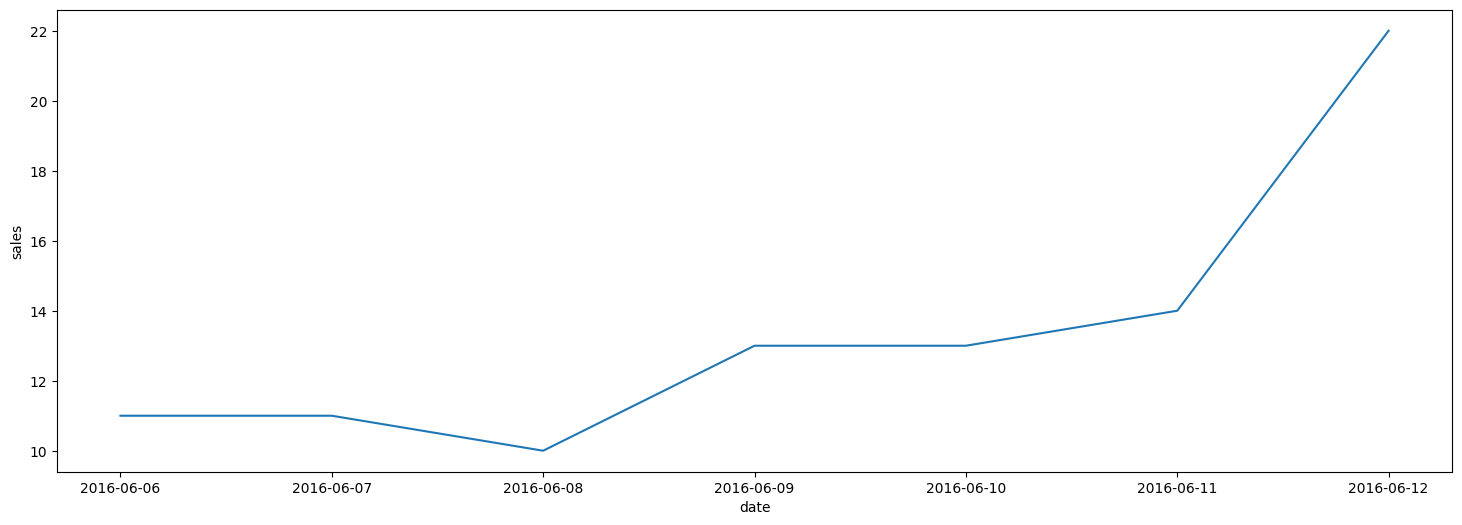

In [124]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=baby_care_data['2016-06-06':'2016-06-12'],
    x=baby_care_data['2016-06-06':'2016-06-12'].index,
    y='sales')
plt.show()

#### dec - jan

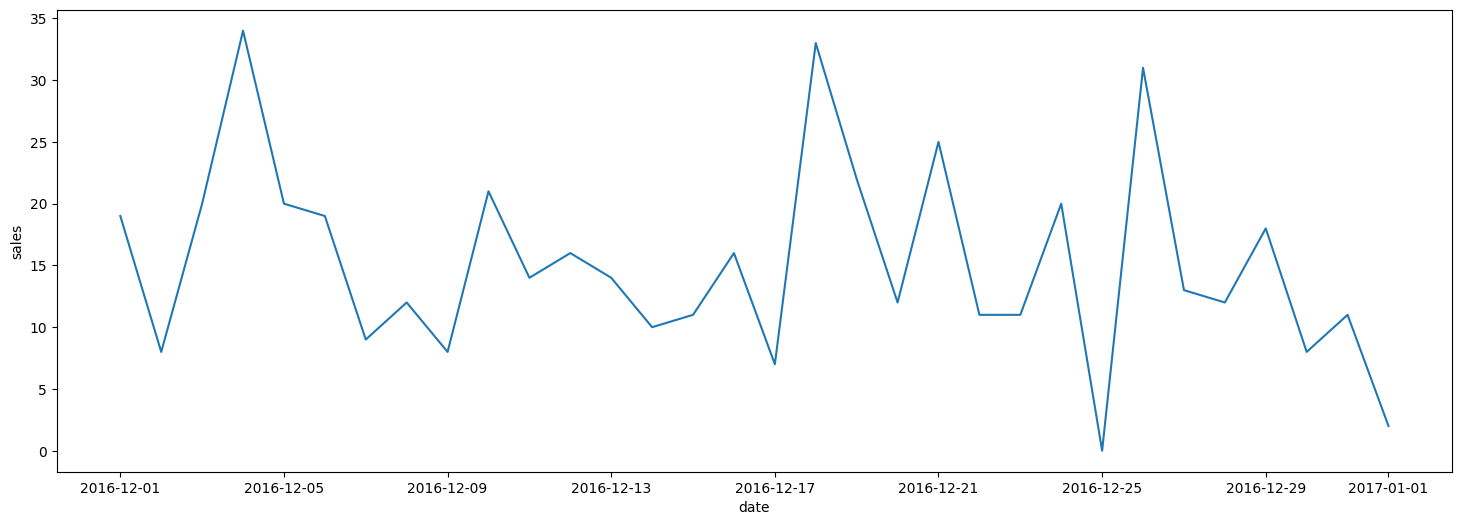

In [125]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=baby_care_data['2016-12-01':'2017-01-01'],
    x=baby_care_data['2016-12-01':'2017-01-01'].index,
    y='sales')
plt.show()

In [111]:
baby_care_data.loc['2017-01-01']

,2017-01-01
family,BABY CARE
sales,2.0000


### BEAUTY

In [116]:
beauty_data = data_agg[data_agg['family'] == 'BEAUTY']

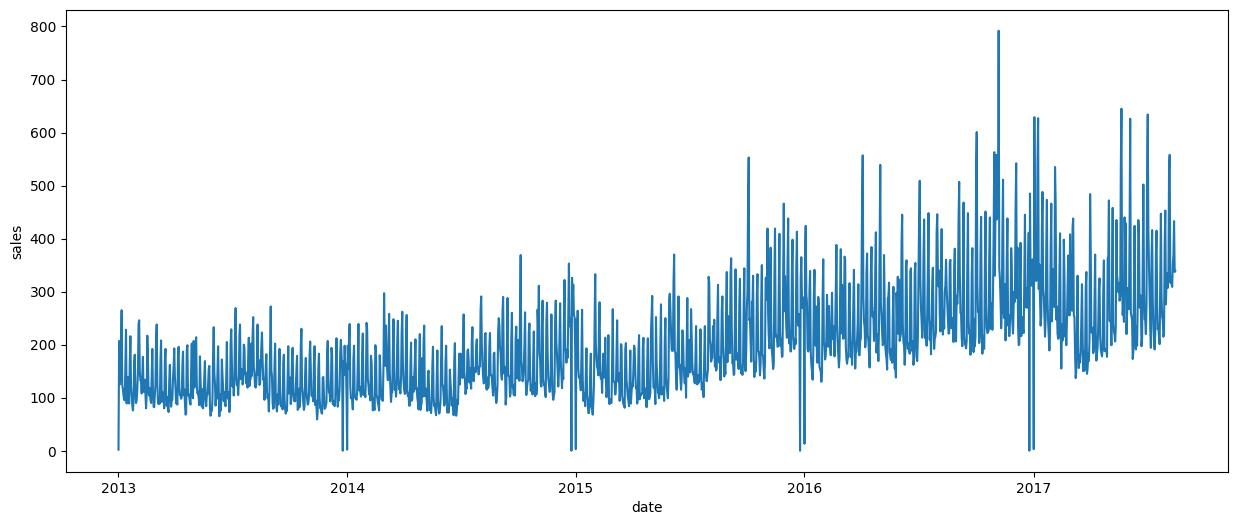

In [117]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=beauty_data, x=beauty_data.index, y='sales')
plt.show()

#### Year



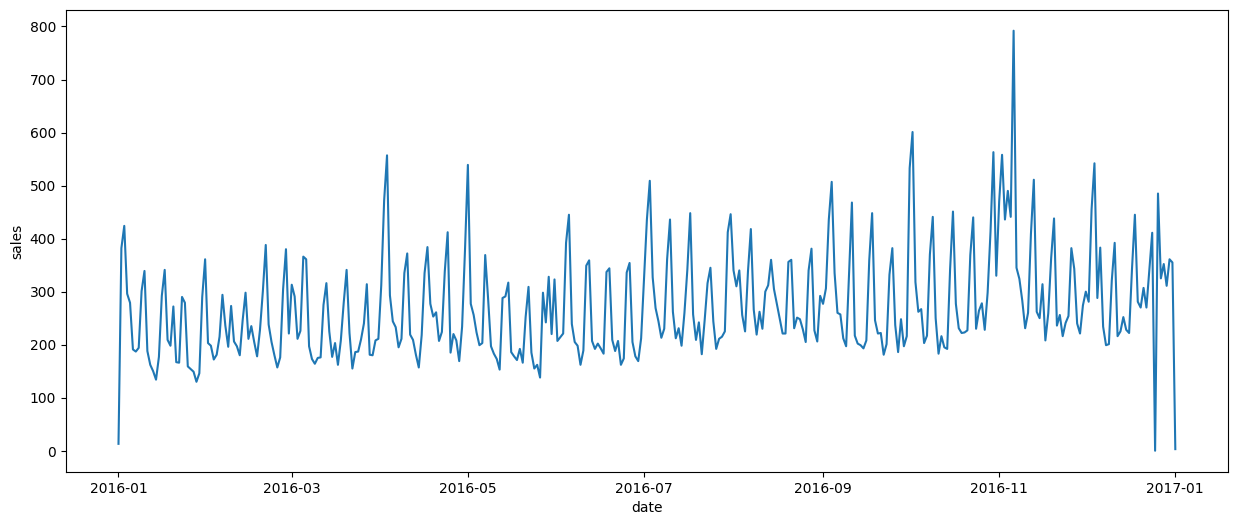

In [118]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=beauty_data['2016-01-01':'2017-01-01'],
             x=beauty_data['2016-01-01':'2017-01-01'].index,
             y='sales')
plt.show()

#### Six months

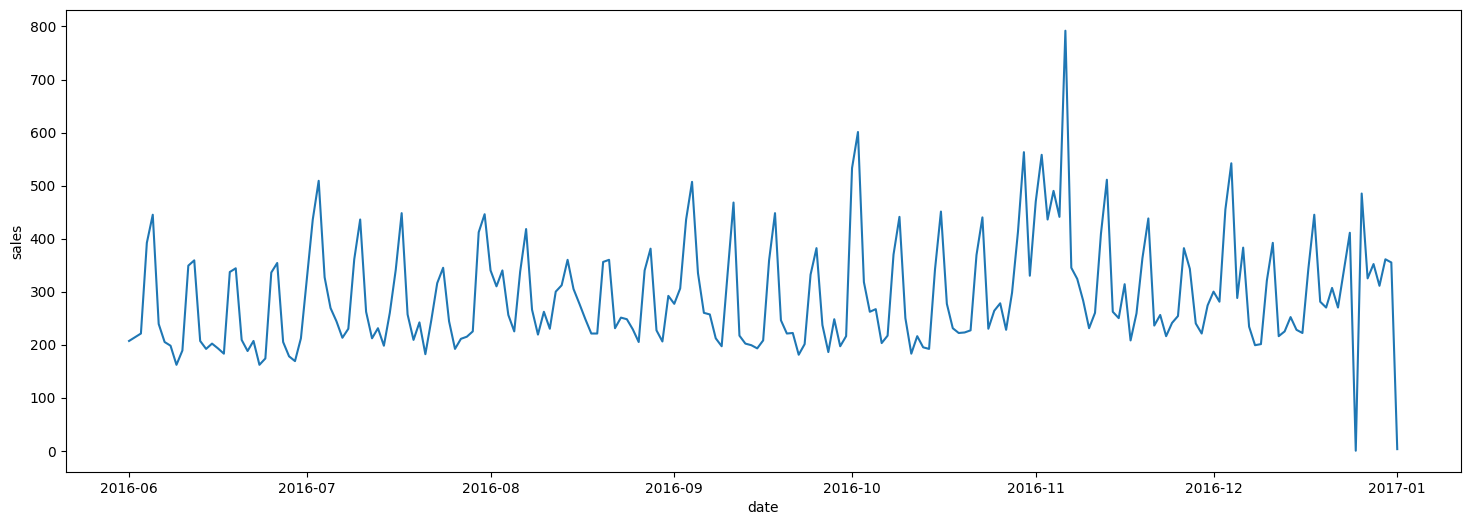

In [126]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=beauty_data['2016-06-01':'2017-01-01'],
    x=beauty_data['2016-06-01':'2017-01-01'].index,
    y='sales')
plt.show()

#### Month

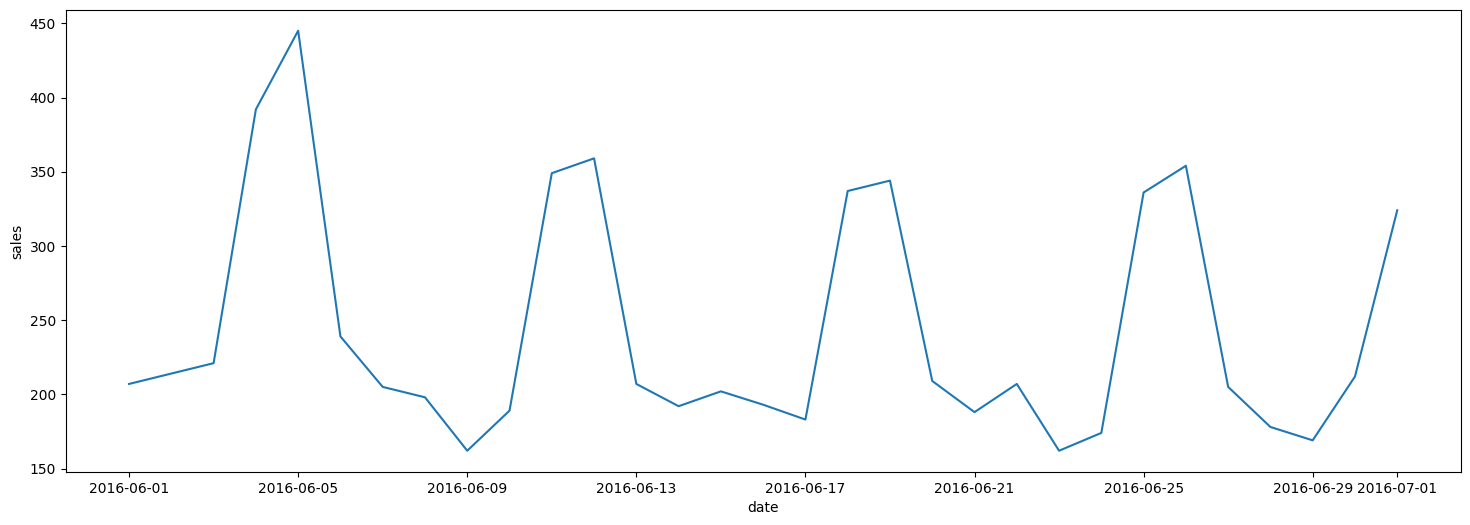

In [127]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=beauty_data['2016-06-01':'2016-07-01'],
    x=beauty_data['2016-06-01':'2016-07-01'].index,
    y='sales')
plt.show()

#### 15 days

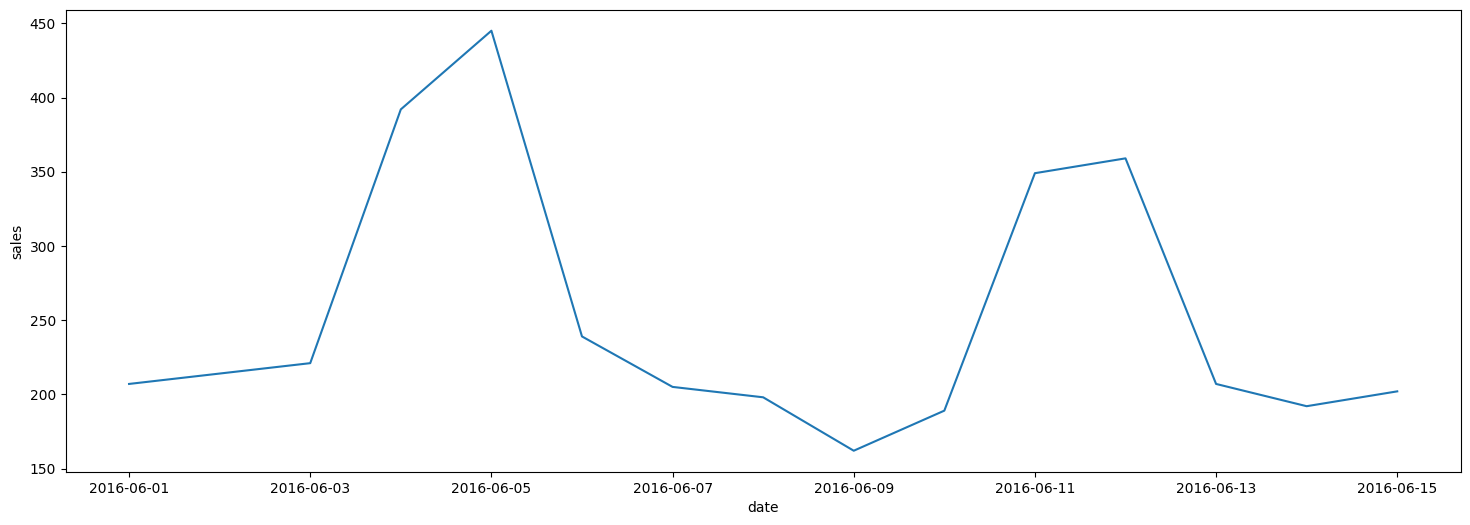

In [129]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=beauty_data['2016-06-01':'2016-06-15'],
    x=beauty_data['2016-06-01':'2016-06-15'].index,
    y='sales')
plt.show()

#### Week

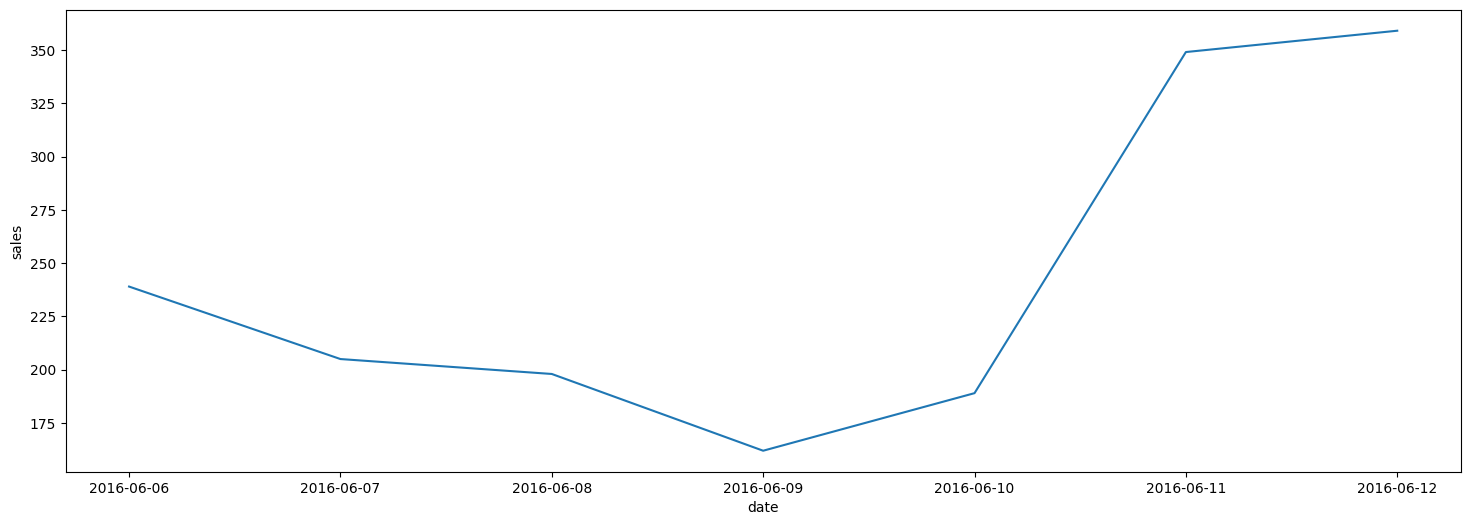

In [130]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=beauty_data['2016-06-06':'2016-06-12'],
    x=beauty_data['2016-06-06':'2016-06-12'].index,
    y='sales')
plt.show()

#### What happens in november?

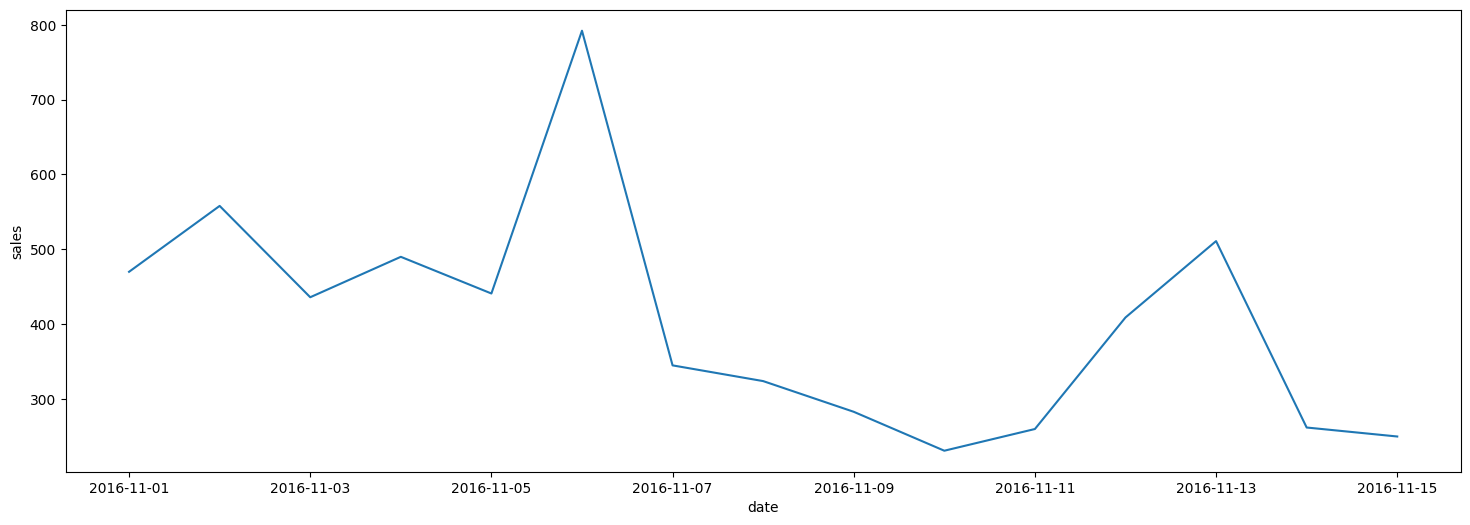

In [131]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=beauty_data['2016-11-01':'2016-11-15'],
    x=beauty_data['2016-11-01':'2016-11-15'].index,
    y='sales')
plt.show()

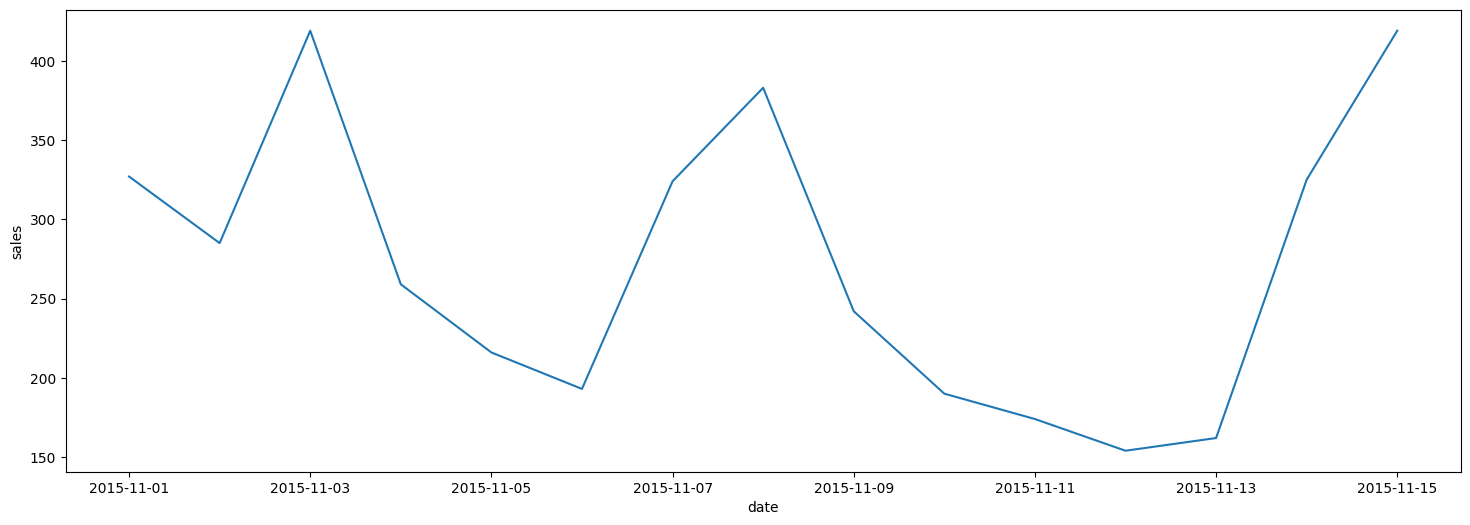

In [132]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=beauty_data['2015-11-01':'2015-11-15'],
    x=beauty_data['2015-11-01':'2015-11-15'].index,
    y='sales')
plt.show()

Very much nothing special

### BEVERAGES

In [134]:
beverages_data = data_agg[data_agg['family'] == 'BEVERAGES']

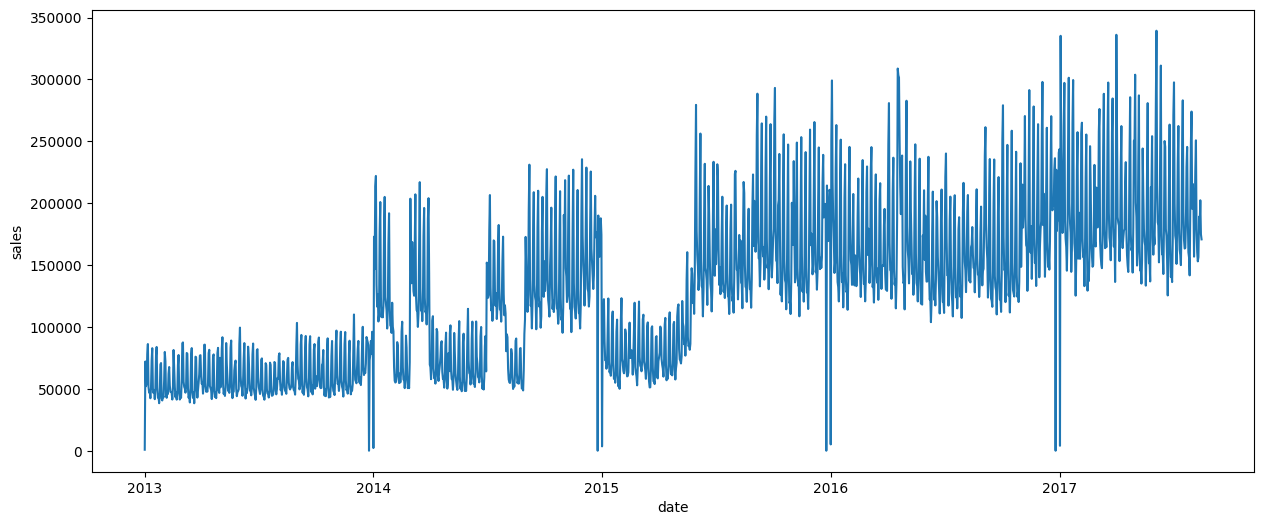

In [135]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=beverages_data, x=beverages_data.index, y='sales')
plt.show()

#### Year



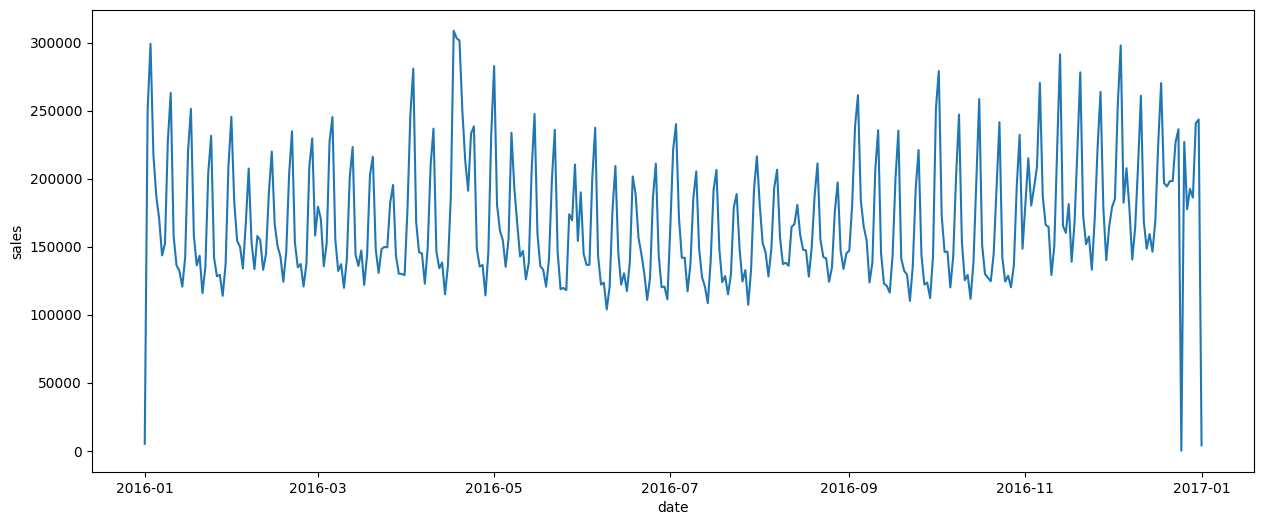

In [136]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=beverages_data['2016-01-01':'2017-01-01'],
             x=beverages_data['2016-01-01':'2017-01-01'].index,
             y='sales')
plt.show()

#### Six months

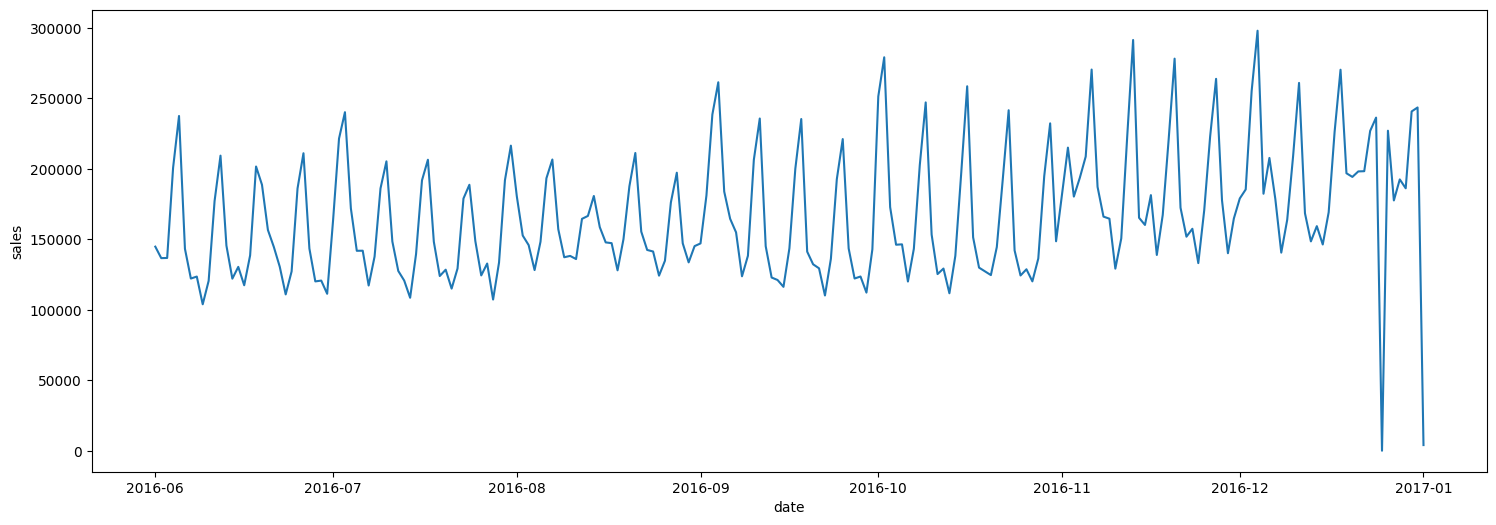

In [137]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=beverages_data['2016-06-01':'2017-01-01'],
    x=beverages_data['2016-06-01':'2017-01-01'].index,
    y='sales')
plt.show()

#### Month

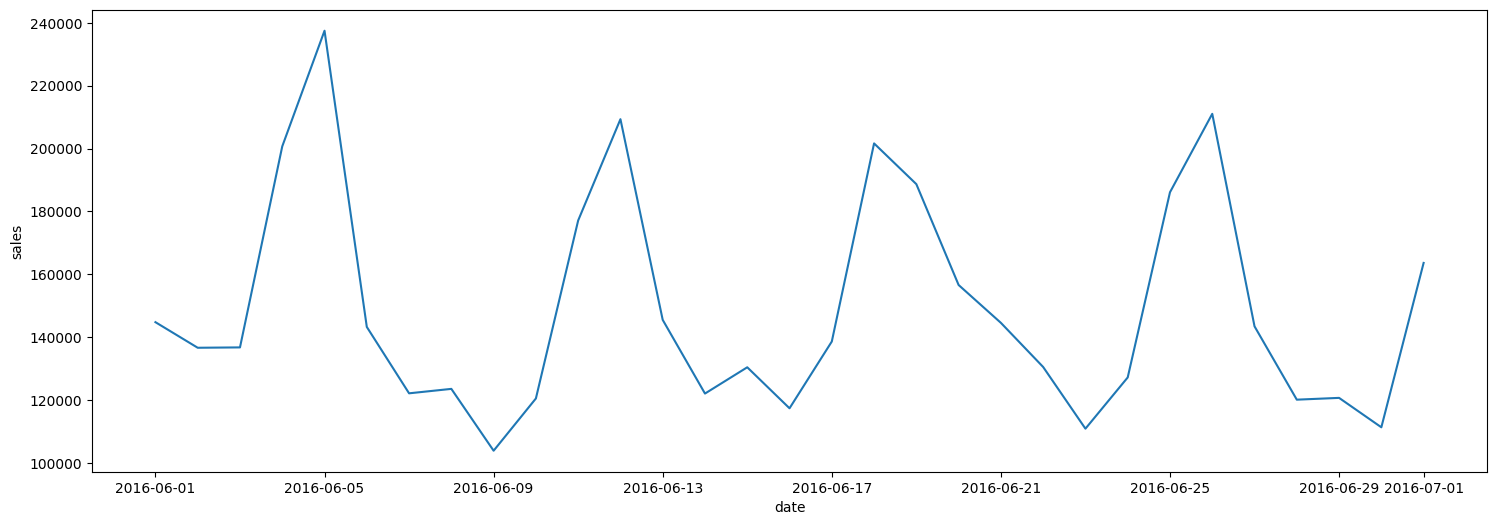

In [138]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=beverages_data['2016-06-01':'2016-07-01'],
    x=beverages_data['2016-06-01':'2016-07-01'].index,
    y='sales')
plt.show()

#### 15 days

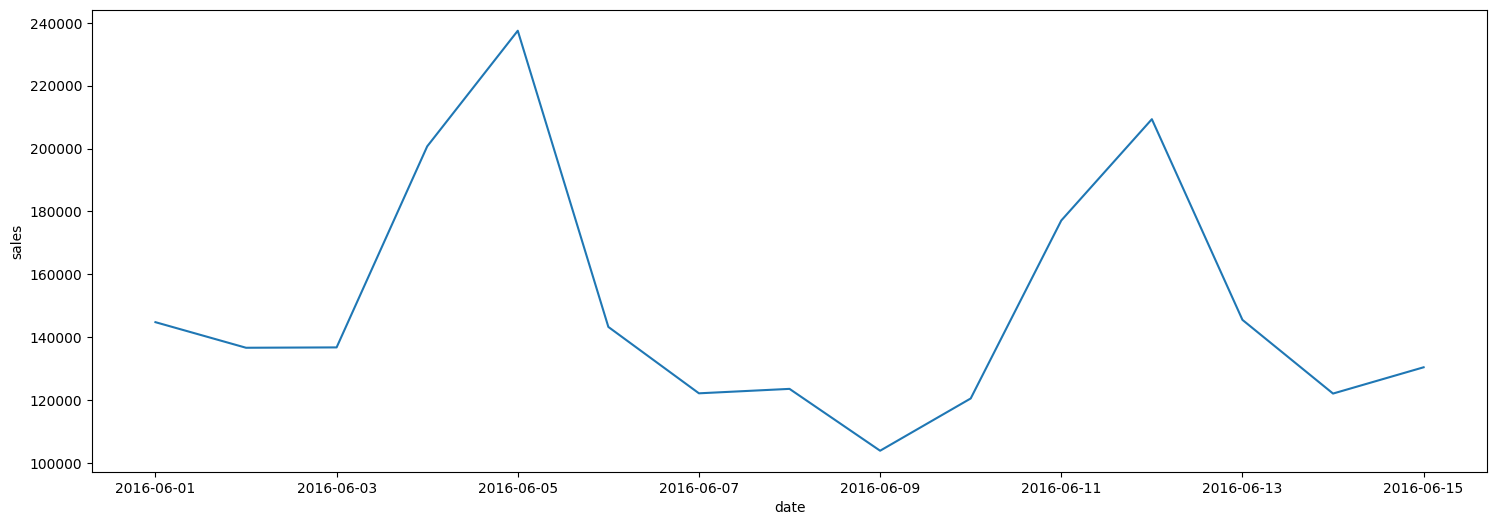

In [139]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=beverages_data['2016-06-01':'2016-06-15'],
    x=beverages_data['2016-06-01':'2016-06-15'].index,
    y='sales')
plt.show()

#### Week

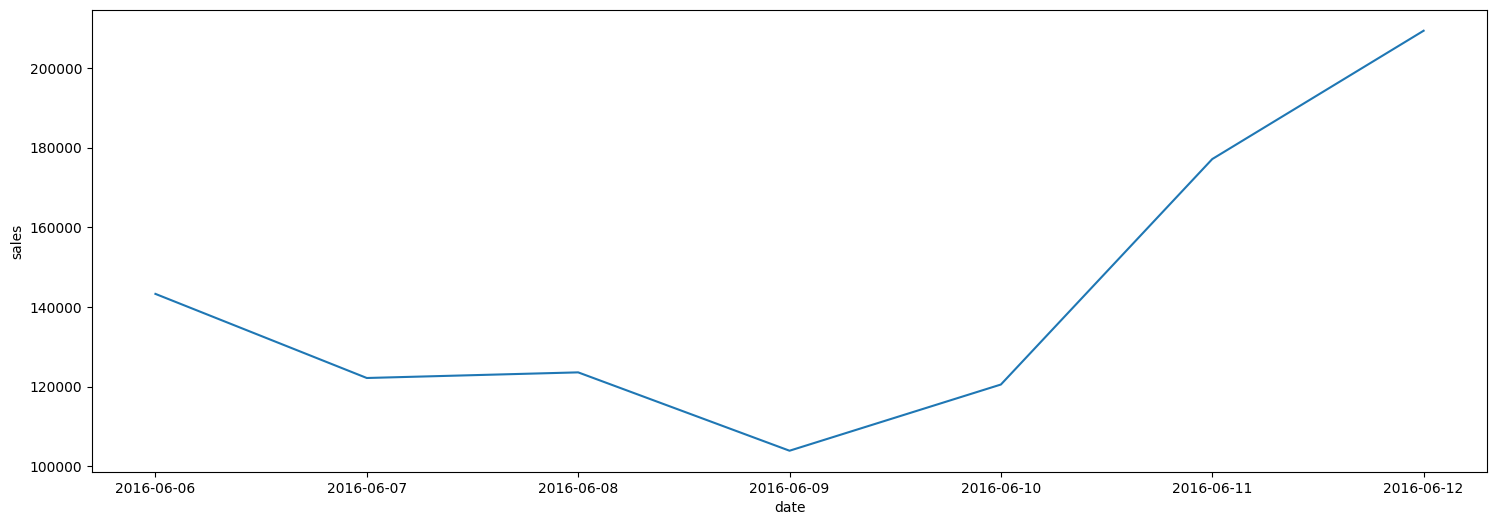

In [140]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=beverages_data['2016-06-06':'2016-06-12'],
    x=beverages_data['2016-06-06':'2016-06-12'].index,
    y='sales')
plt.show()

### BOOKS

In [143]:
books_data = data_agg[data_agg['family'] == 'BOOKS']

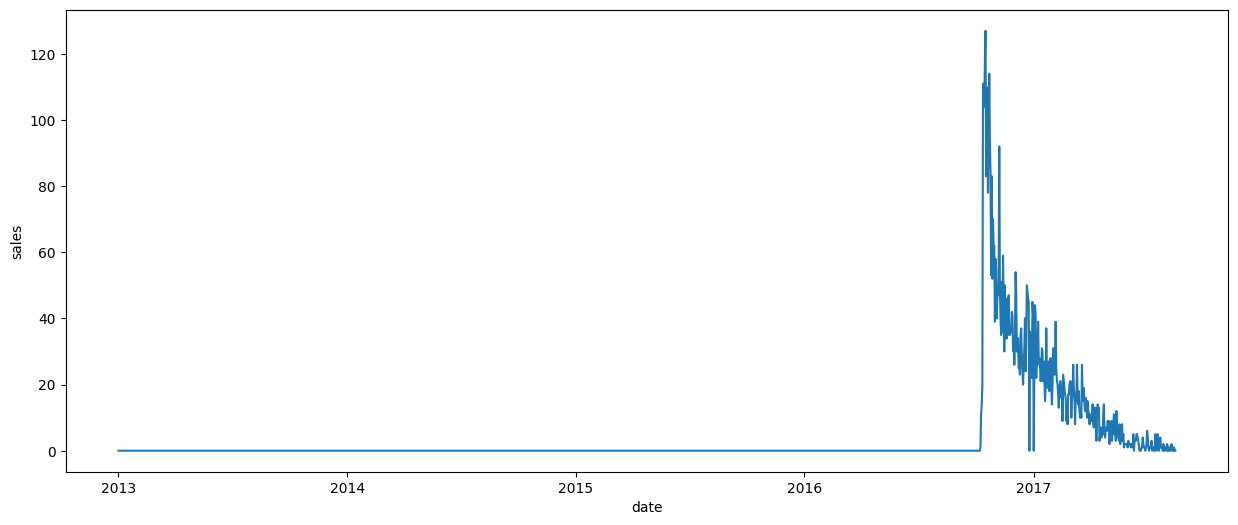

In [144]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=books_data, x=books_data.index, y='sales')
plt.show()

#### Year



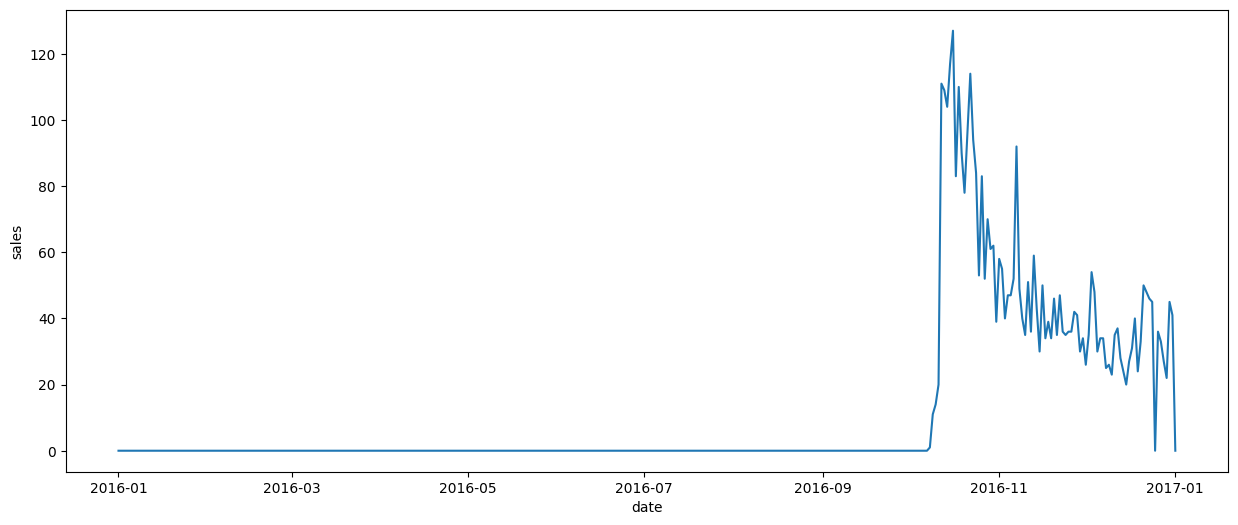

In [146]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=books_data['2016-01-01':'2017-01-01'],
             x=books_data['2016-01-01':'2017-01-01'].index,
             y='sales')
plt.show()

#### Find the start

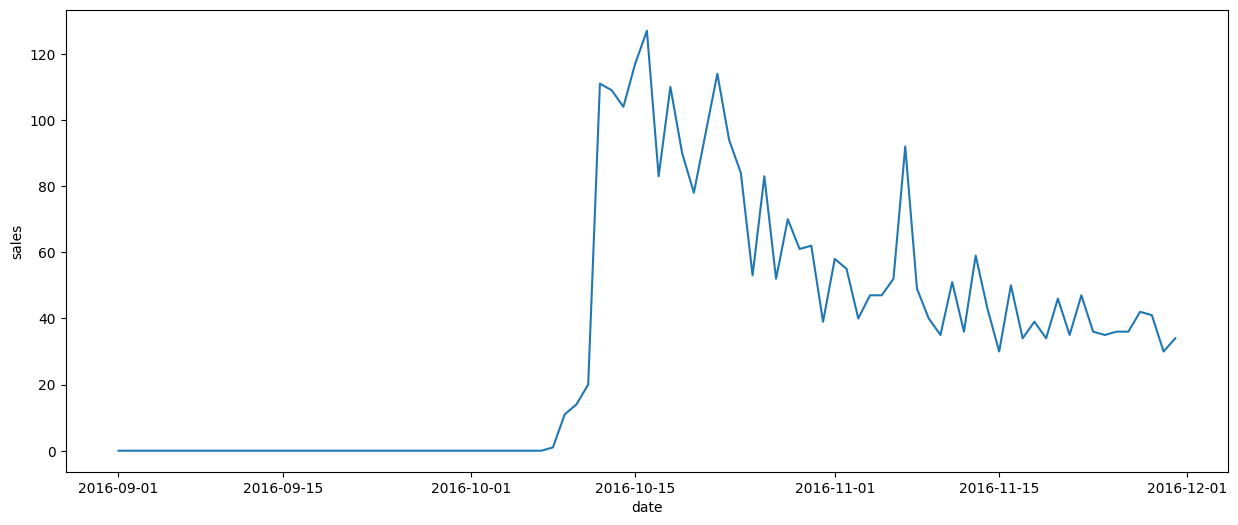

In [148]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=books_data['2016-09':'2016-11'],
             x=books_data['2016-09':'2016-11'].index,
             y='sales')
plt.show()

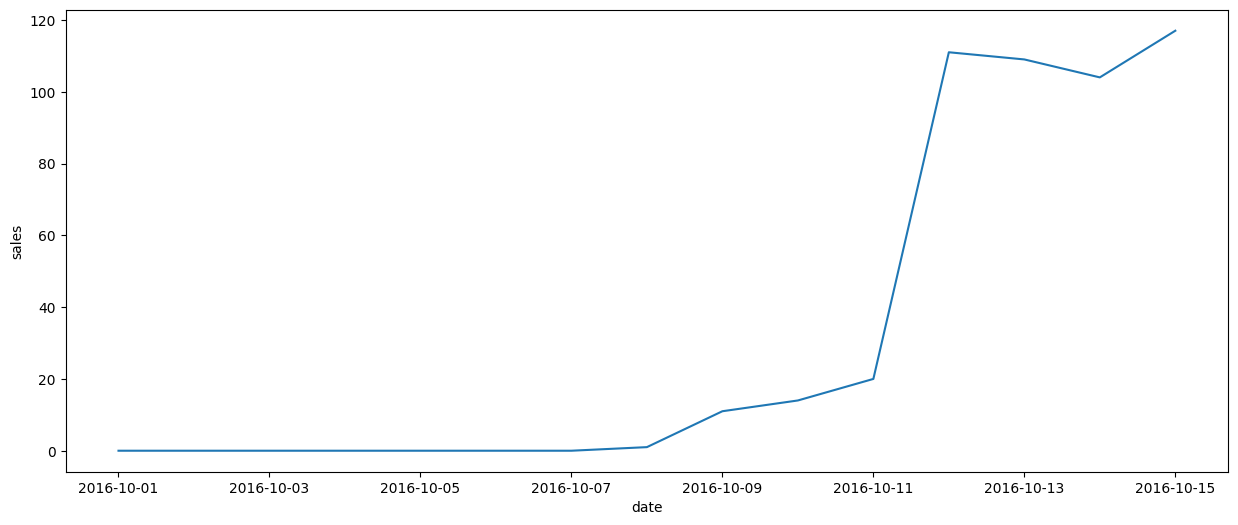

In [149]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=books_data['2016-10-01':'2016-10-15'],
             x=books_data['2016-10-01':'2016-10-15'].index,
             y='sales')
plt.show()

start from 2016-10-08

#### re-init

In [150]:
books_data = data_agg[data_agg['family'] == 'BOOKS']['2016-10-08':]

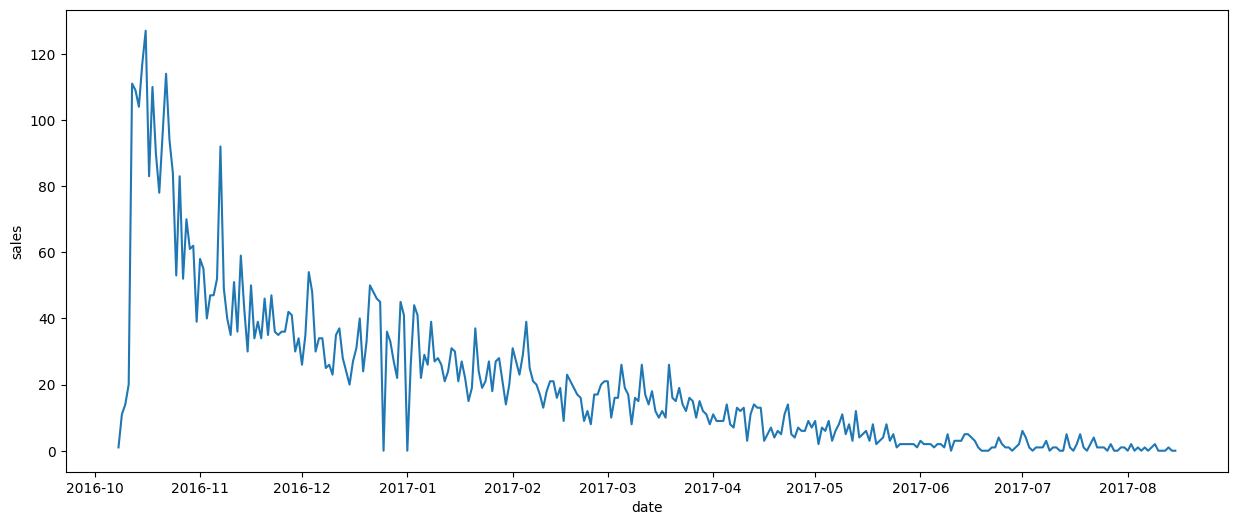

In [151]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=books_data, x=books_data.index, y='sales')
plt.show()

### BREAD/BAKERY

In [154]:
bread_data = data_agg[data_agg['family'] == 'BREAD/BAKERY']

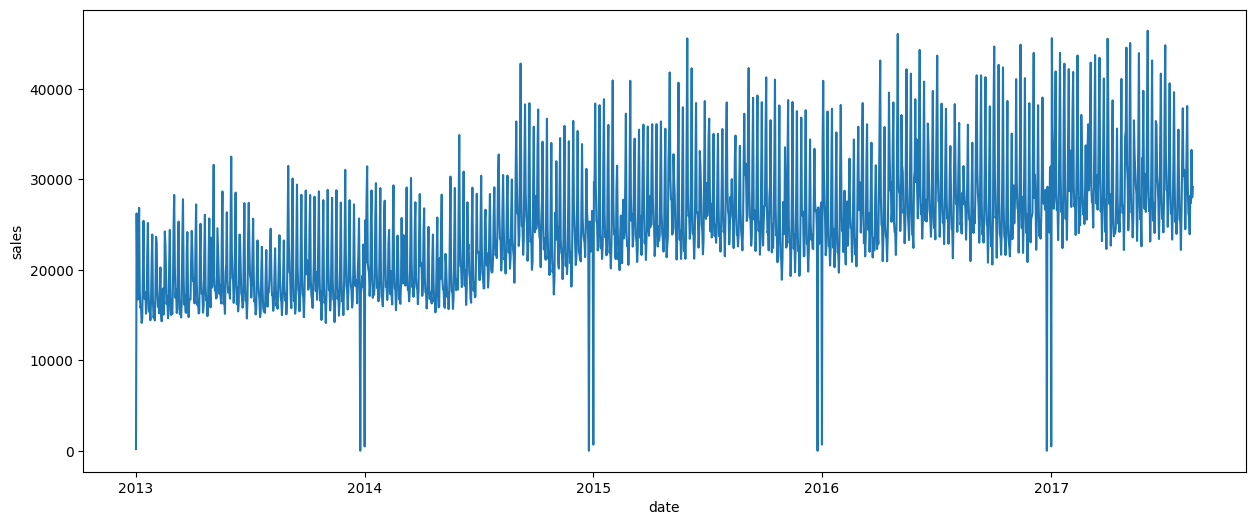

In [155]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=bread_data, x=bread_data.index, y='sales')
plt.show()

#### Year



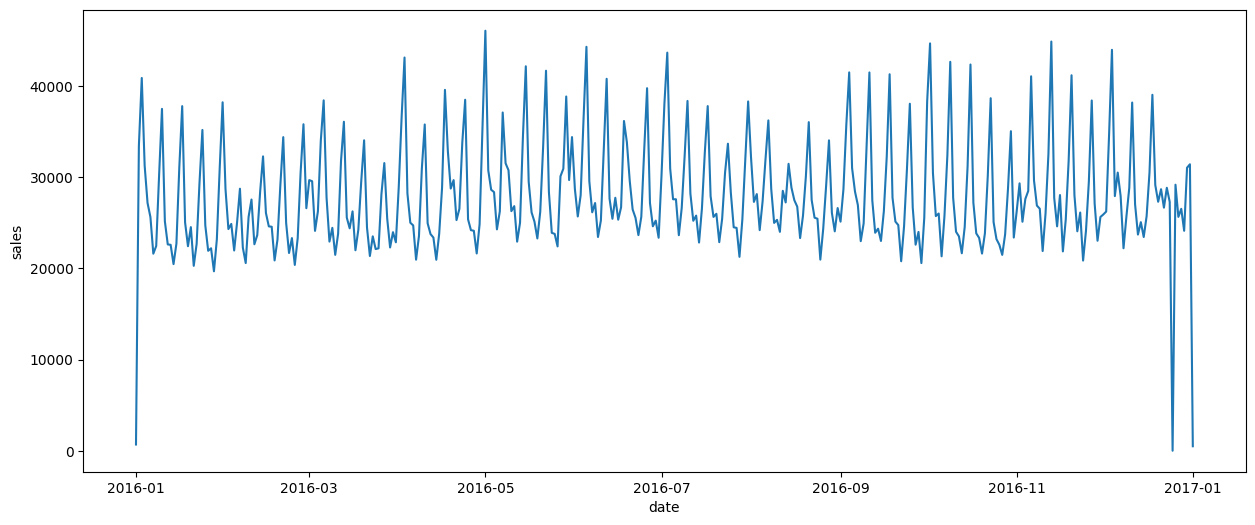

In [156]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=bread_data['2016-01-01':'2017-01-01'],
             x=bread_data['2016-01-01':'2017-01-01'].index,
             y='sales')
plt.show()

#### Six months

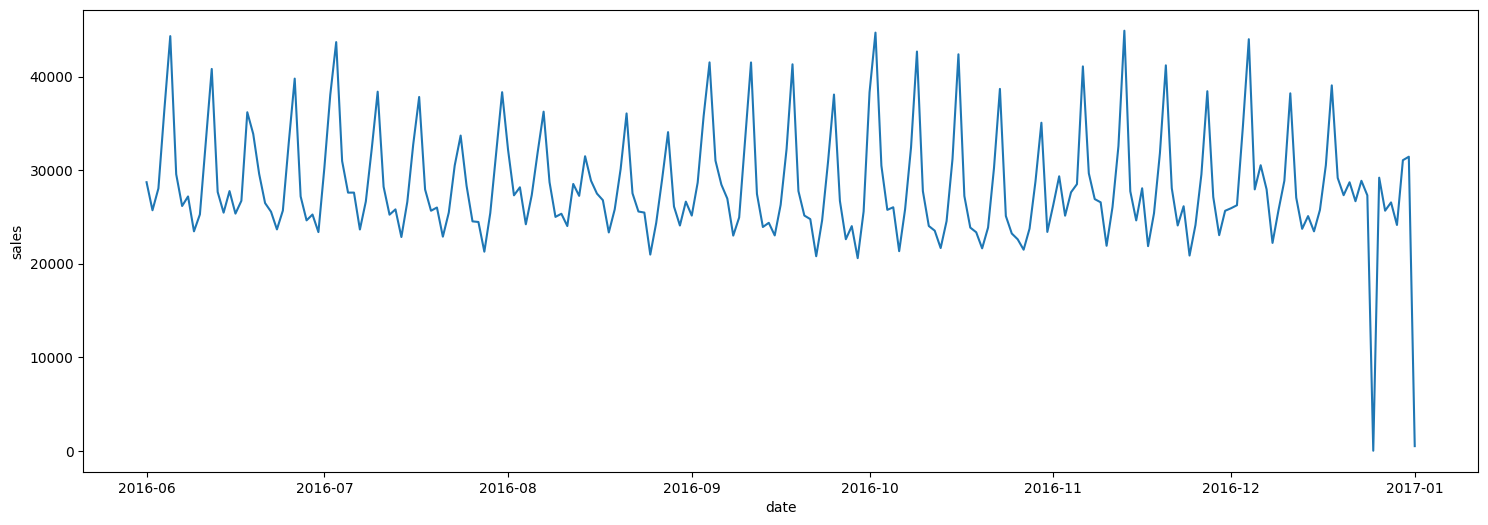

In [157]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=bread_data['2016-06-01':'2017-01-01'],
    x=bread_data['2016-06-01':'2017-01-01'].index,
    y='sales')
plt.show()

#### Month

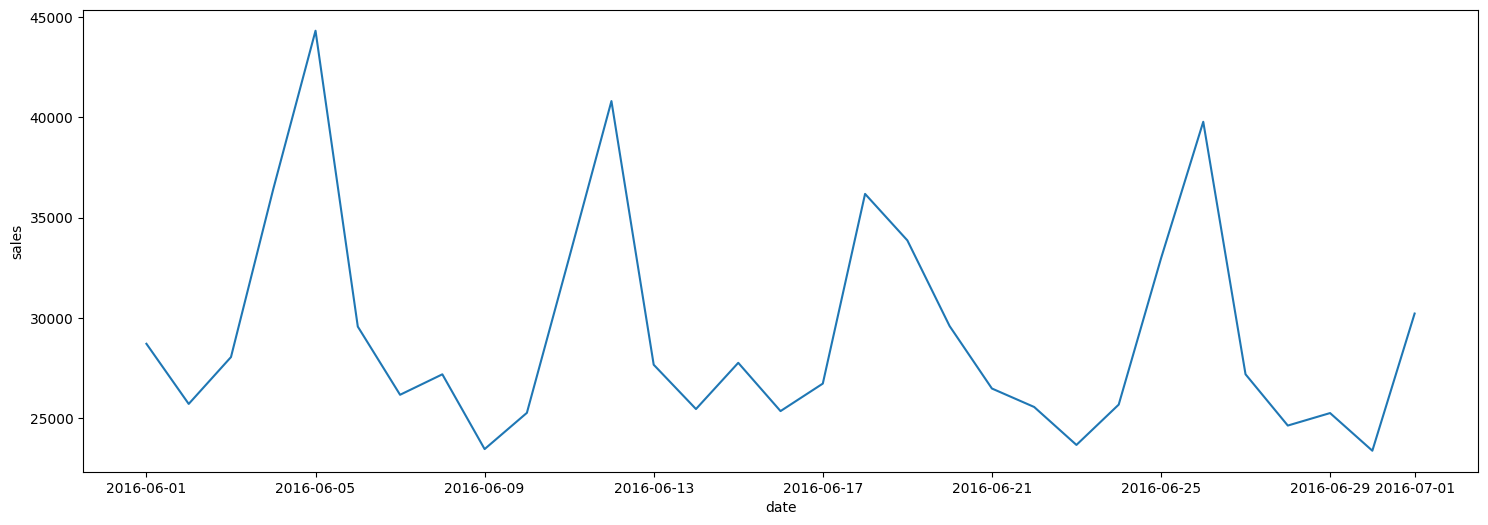

In [158]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=bread_data['2016-06-01':'2016-07-01'],
    x=bread_data['2016-06-01':'2016-07-01'].index,
    y='sales')
plt.show()

#### 15 days

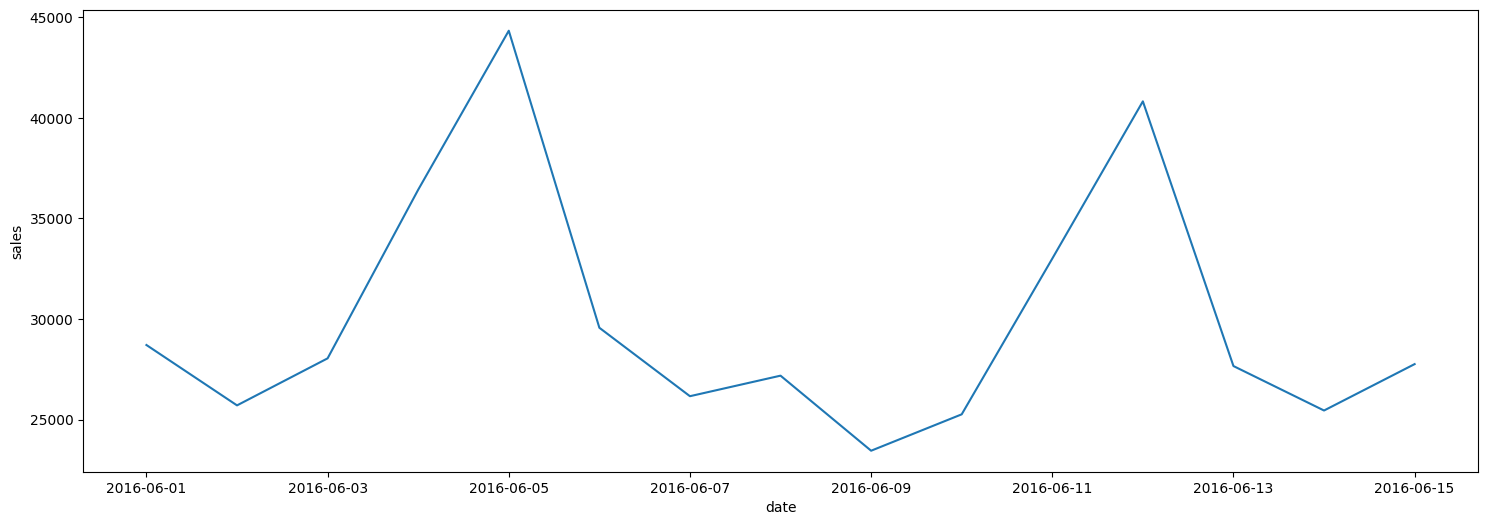

In [159]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=bread_data['2016-06-01':'2016-06-15'],
    x=bread_data['2016-06-01':'2016-06-15'].index,
    y='sales')
plt.show()

#### Week

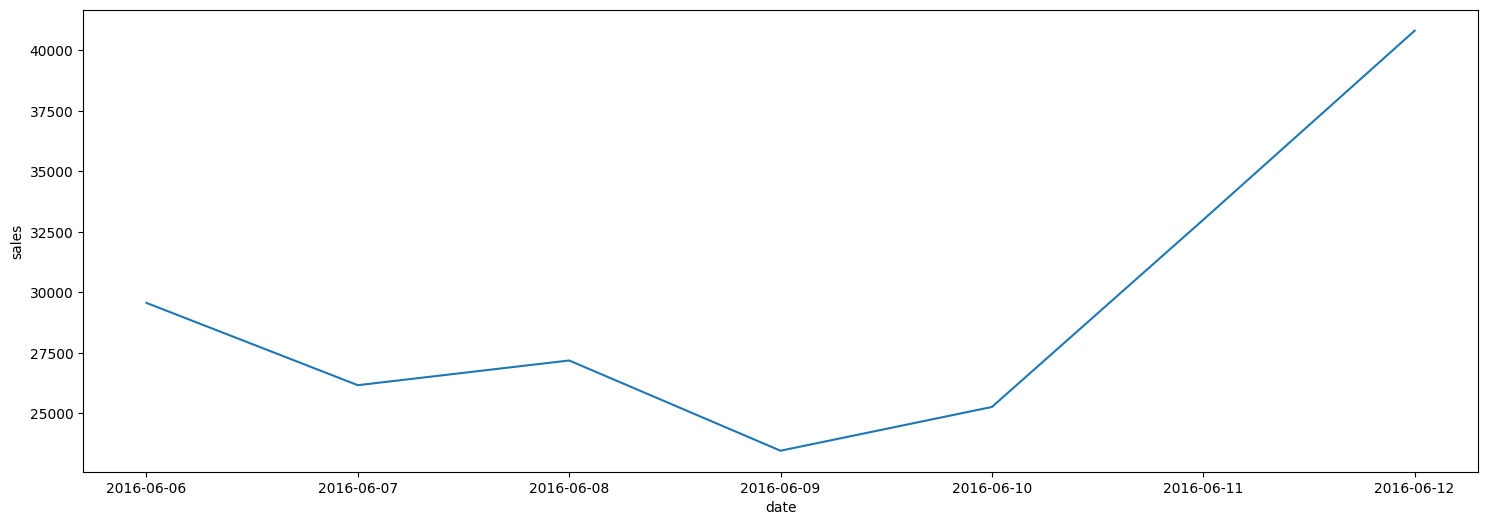

In [160]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=bread_data['2016-06-06':'2016-06-12'],
    x=bread_data['2016-06-06':'2016-06-12'].index,
    y='sales')
plt.show()

### CELEBRATION

In [162]:
celebration_data = data_agg[data_agg['family'] == 'CELEBRATION']

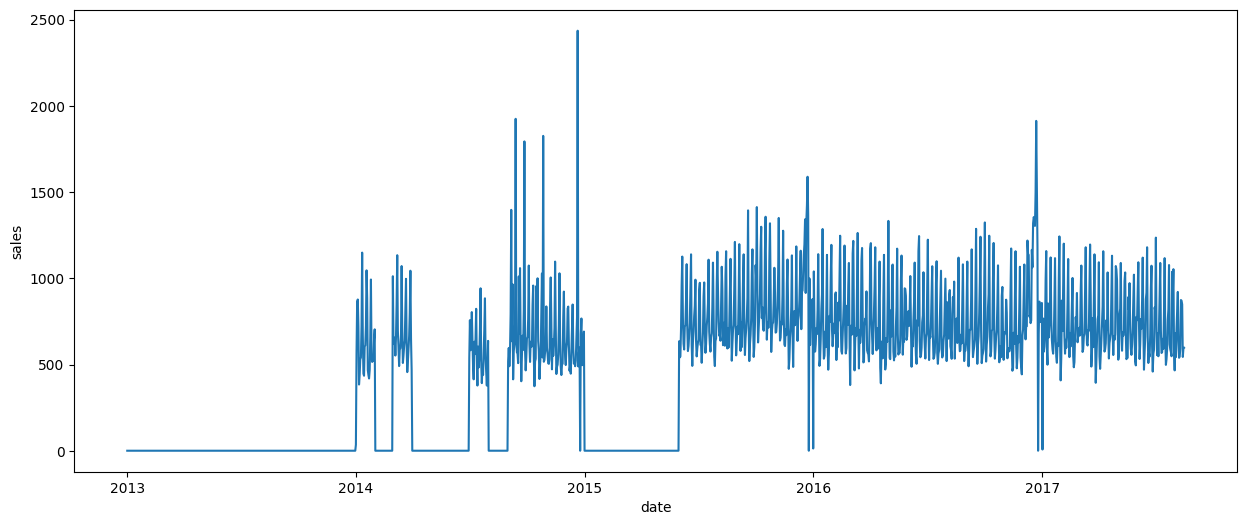

In [166]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=celebration_data, x=celebration_data.index, y='sales')
plt.show()

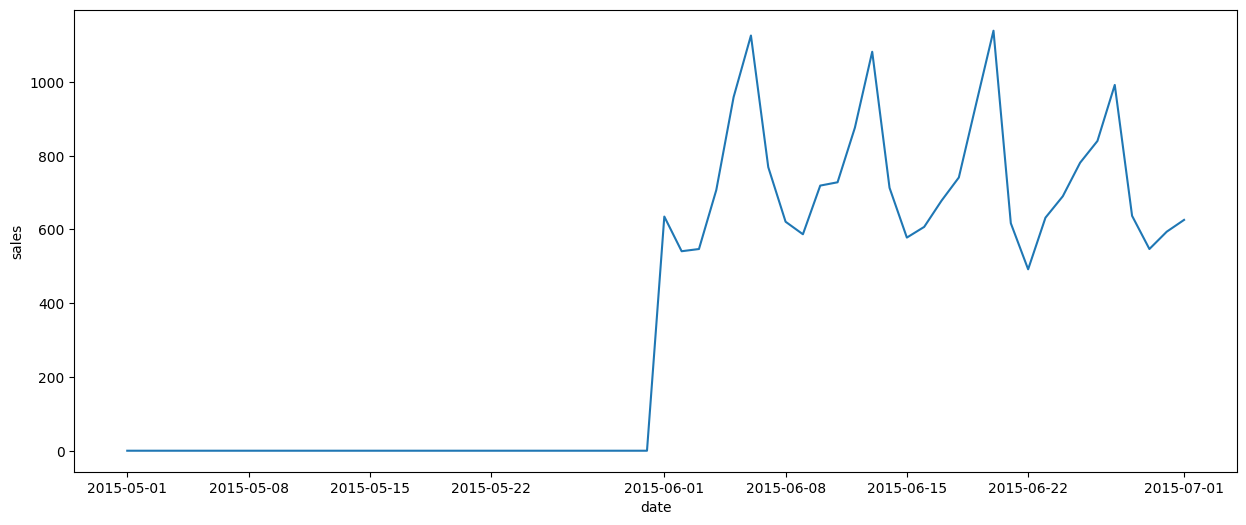

In [167]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=celebration_data['2015-05-01':'2015-07-01'],
             x=celebration_data['2015-05-01':'2015-07-01'].index,
             y='sales')
plt.show()

#### exactly mid of 2015 - 2015-06-01

#### re-init

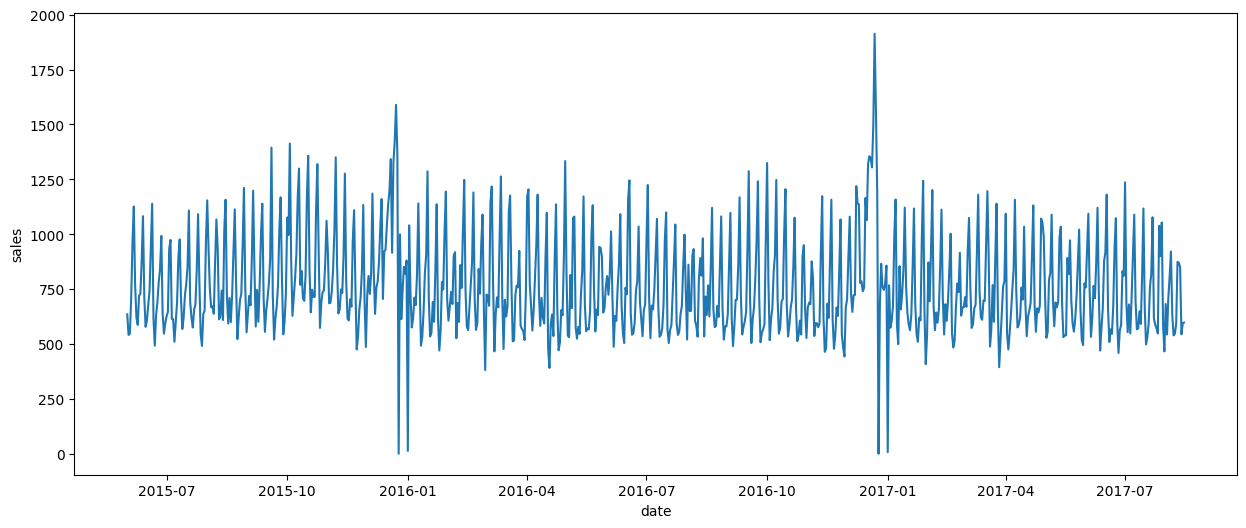

In [169]:
celebration_data = data_agg[data_agg['family'] == 'CELEBRATION']['2015-06-01':]
plt.figure(figsize=(15, 6))
sns.lineplot(data=celebration_data, x=celebration_data.index, y='sales')
plt.show()

#### Year



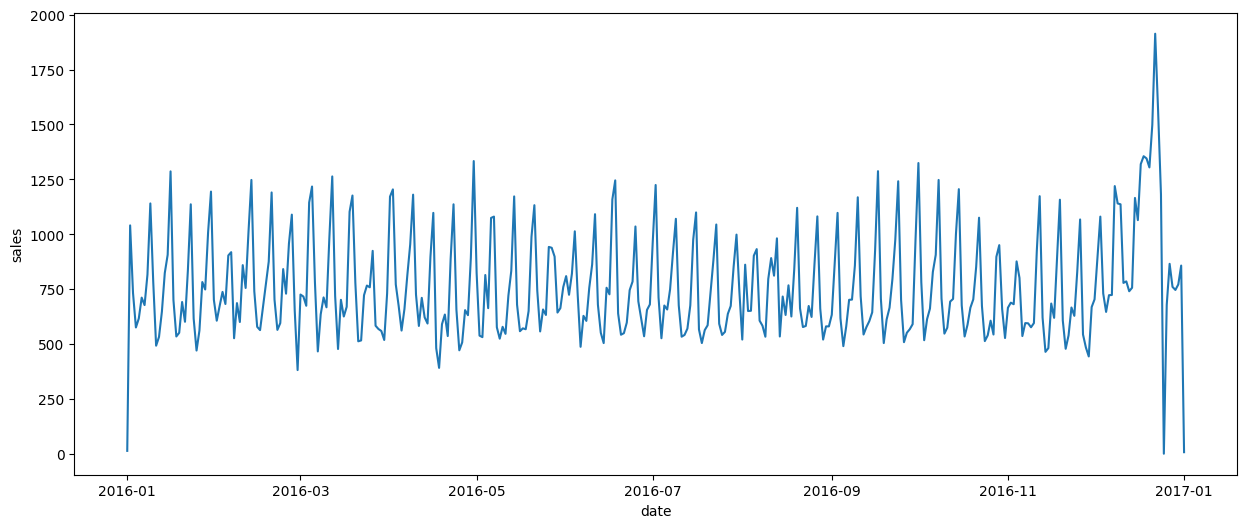

In [170]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=celebration_data['2016-01-01':'2017-01-01'],
             x=celebration_data['2016-01-01':'2017-01-01'].index,
             y='sales')
plt.show()

#### Six months

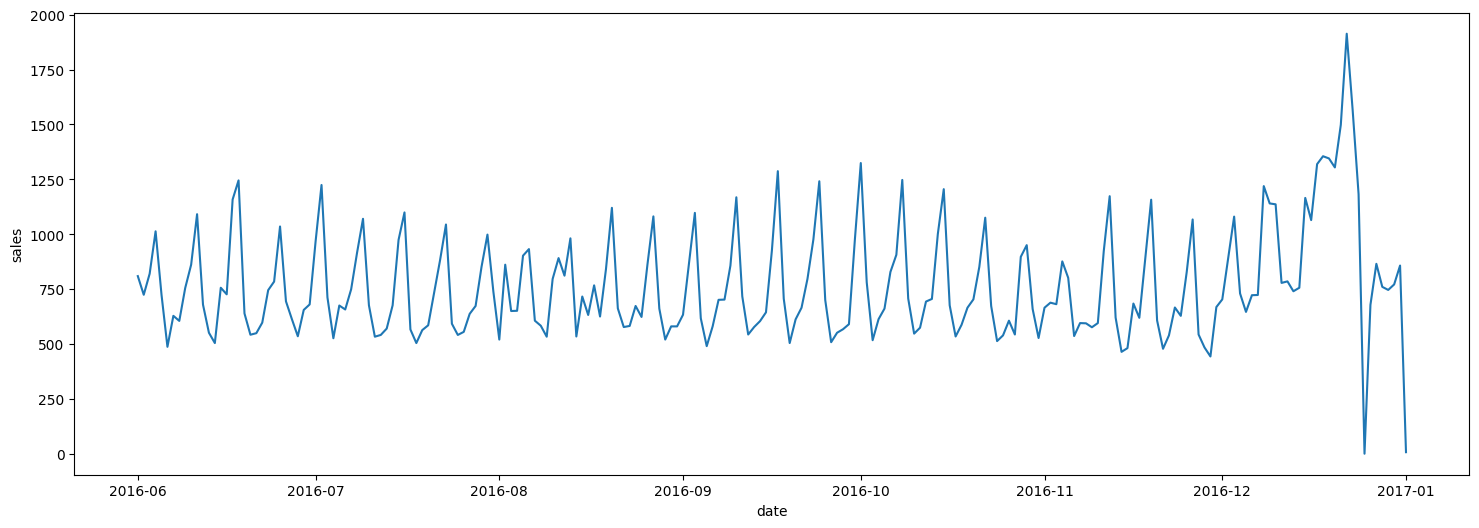

In [171]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=celebration_data['2016-06-01':'2017-01-01'],
    x=celebration_data['2016-06-01':'2017-01-01'].index,
    y='sales')
plt.show()

#### Month

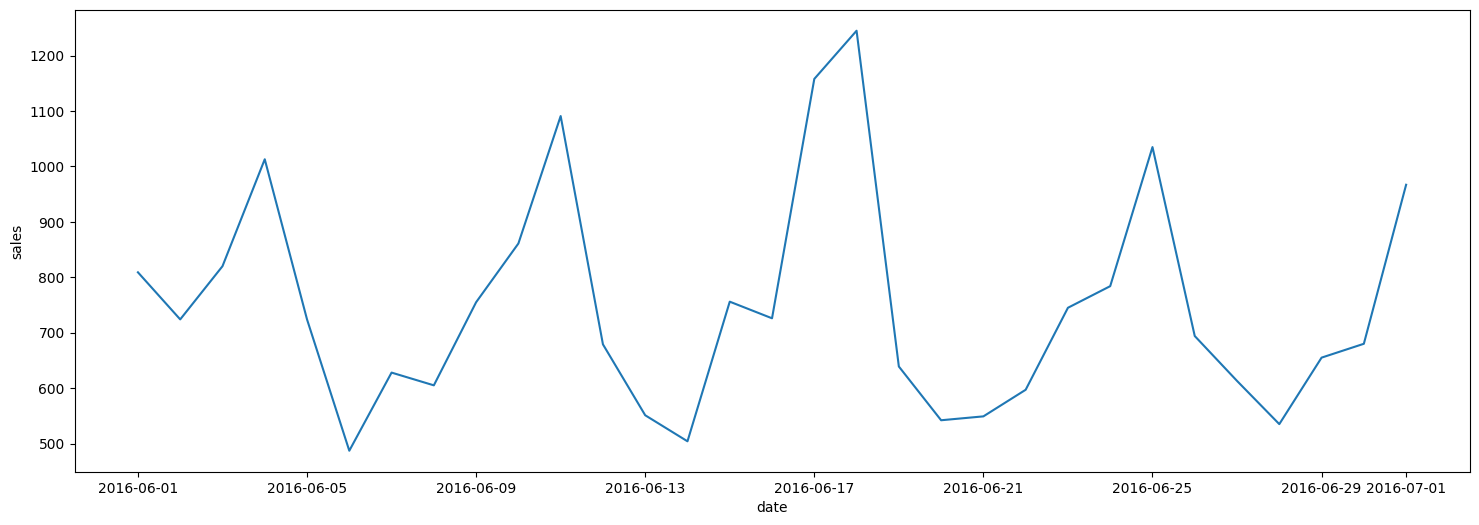

In [172]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=celebration_data['2016-06-01':'2016-07-01'],
    x=celebration_data['2016-06-01':'2016-07-01'].index,
    y='sales')
plt.show()

#### 15 days

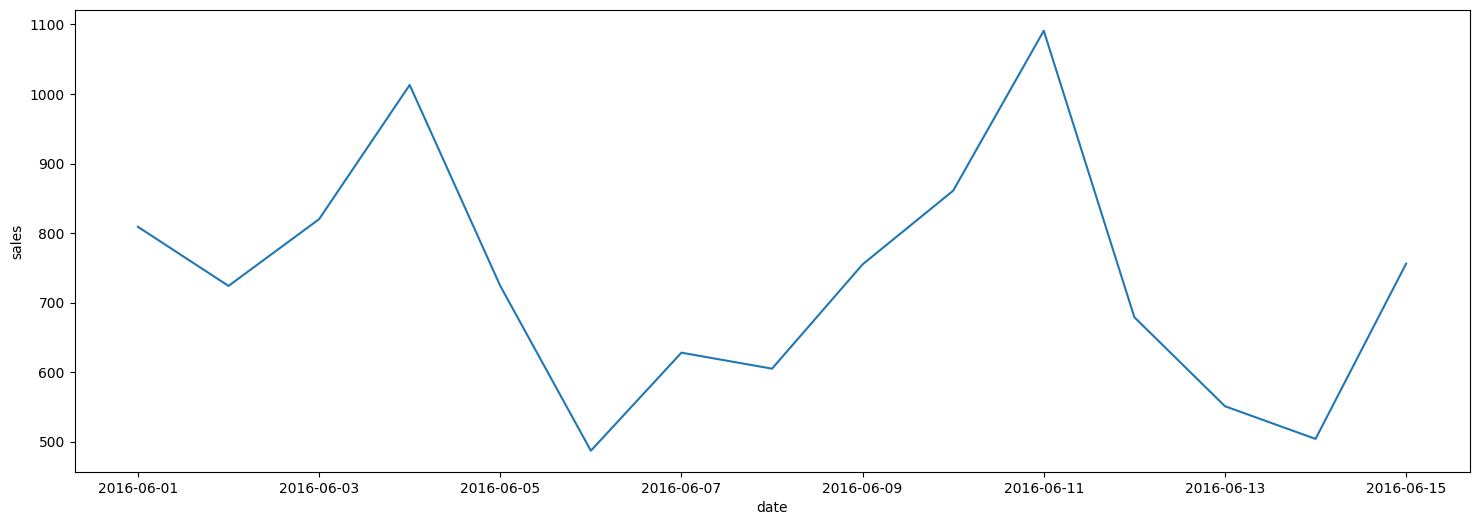

In [173]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=celebration_data['2016-06-01':'2016-06-15'],
    x=celebration_data['2016-06-01':'2016-06-15'].index,
    y='sales')
plt.show()

#### Week

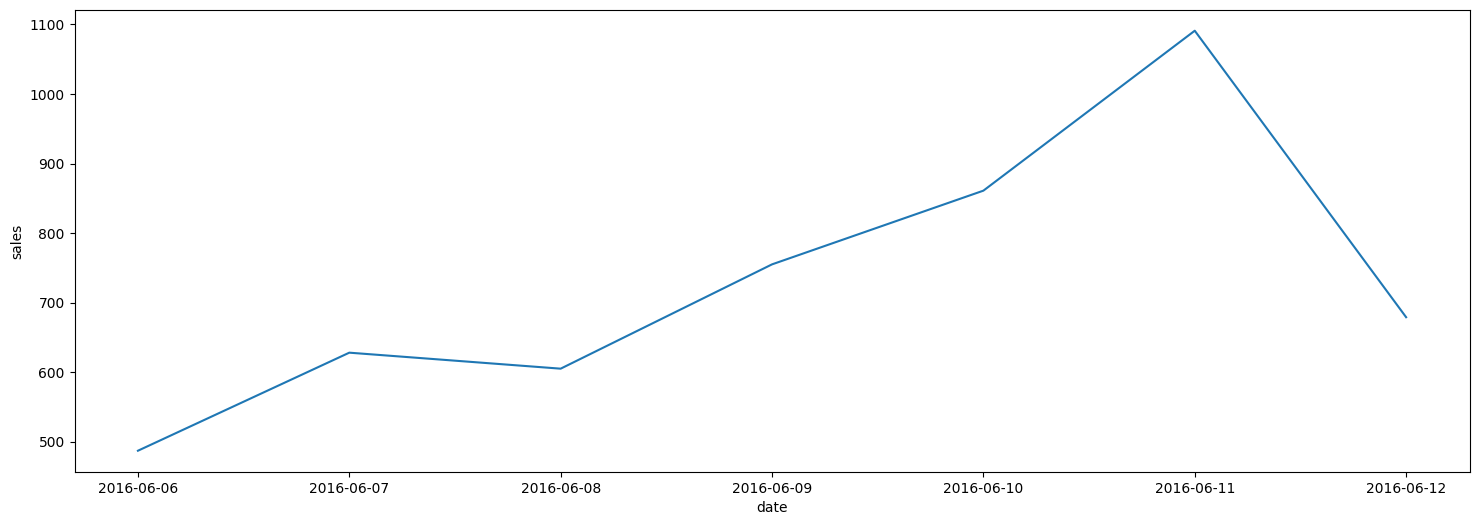

In [174]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=celebration_data['2016-06-06':'2016-06-12'],
    x=celebration_data['2016-06-06':'2016-06-12'].index,
    y='sales')
plt.show()

#### Dec - jun

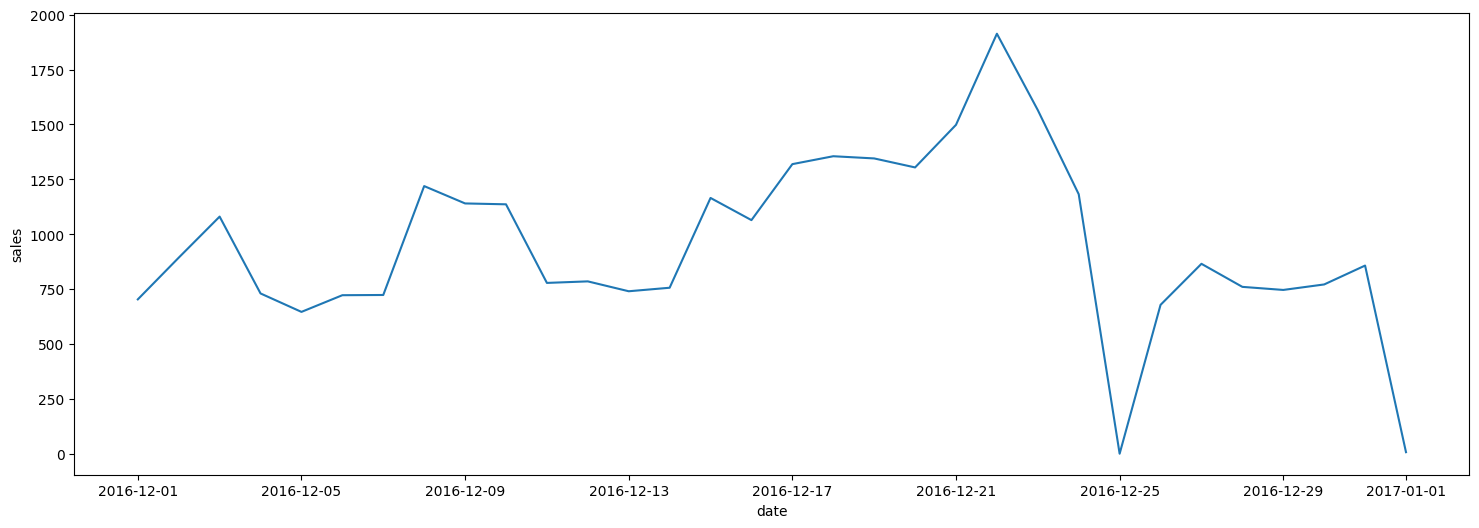

In [175]:
plt.figure(figsize=(18, 6))
sns.lineplot(
    data=celebration_data['2016-12-01':'2017-01-01'],
    x=celebration_data['2016-12-01':'2017-01-01'].index,
    y='sales')
plt.show()

### FROZEN FOODS

In [181]:
frozen_foods_data = data_agg[data_agg['family'] == 'FROZEN FOODS']

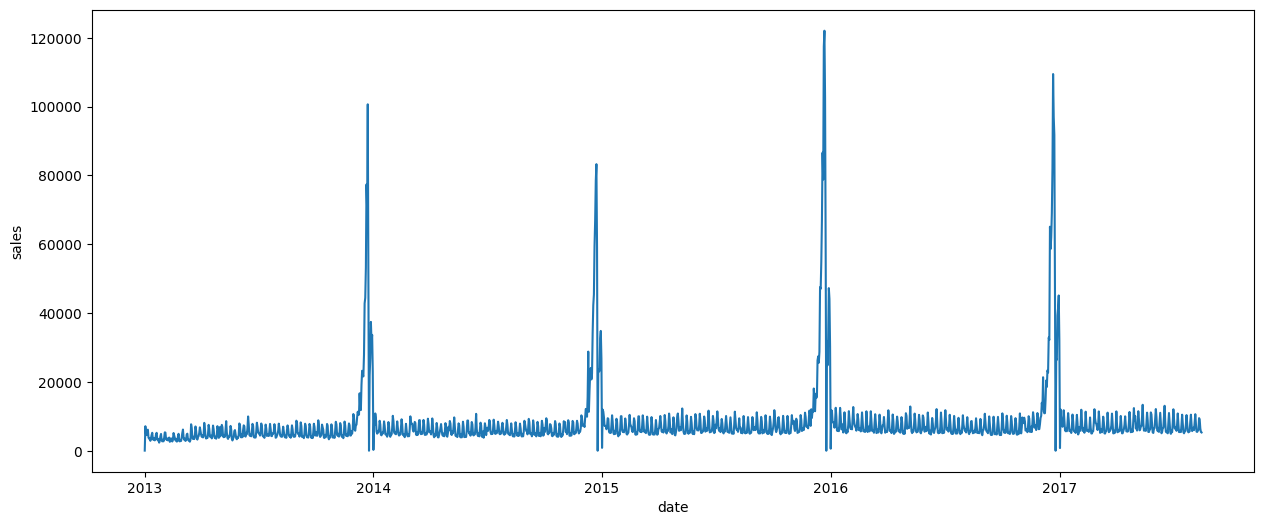

In [182]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=frozen_foods_data, x=frozen_foods_data.index, y='sales')
plt.show()

#### Year



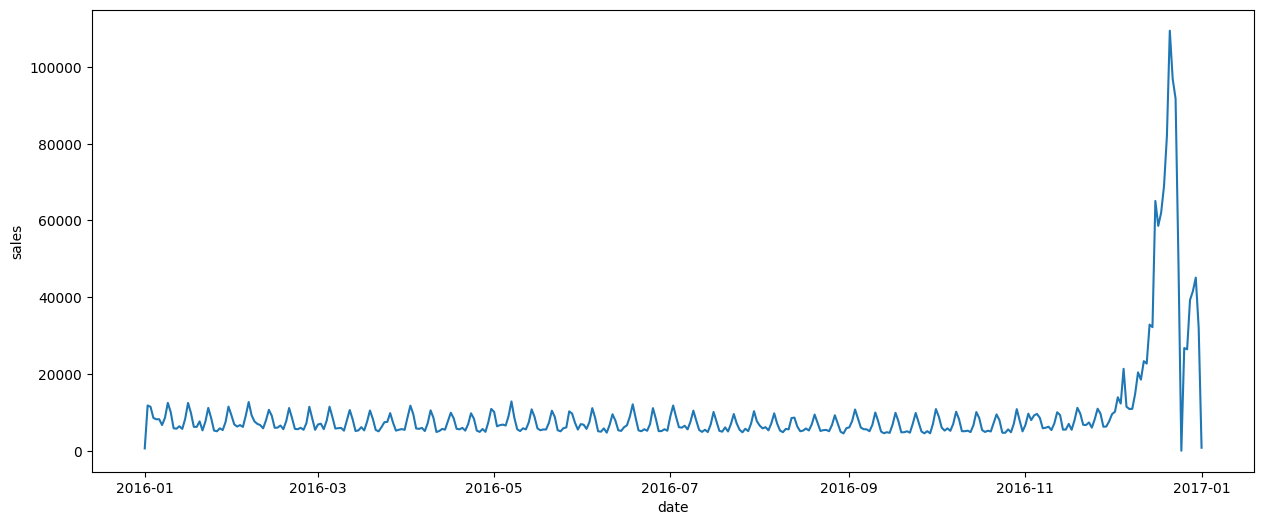

In [183]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=frozen_foods_data['2016-01-01':'2017-01-01'],
             x=frozen_foods_data['2016-01-01':'2017-01-01'].index,
             y='sales')
plt.show()

### GROCERY I

In [184]:
grocery_1_data = data_agg[data_agg['family'] == 'GROCERY I']

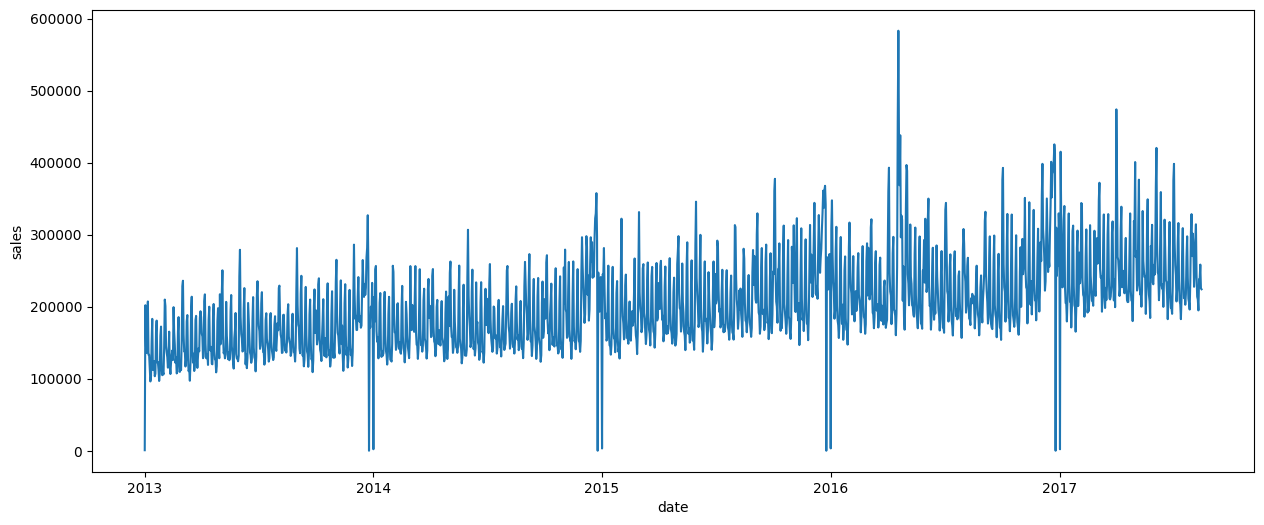

In [185]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=grocery_1_data, x=grocery_1_data.index, y='sales')
plt.show()

#### Year



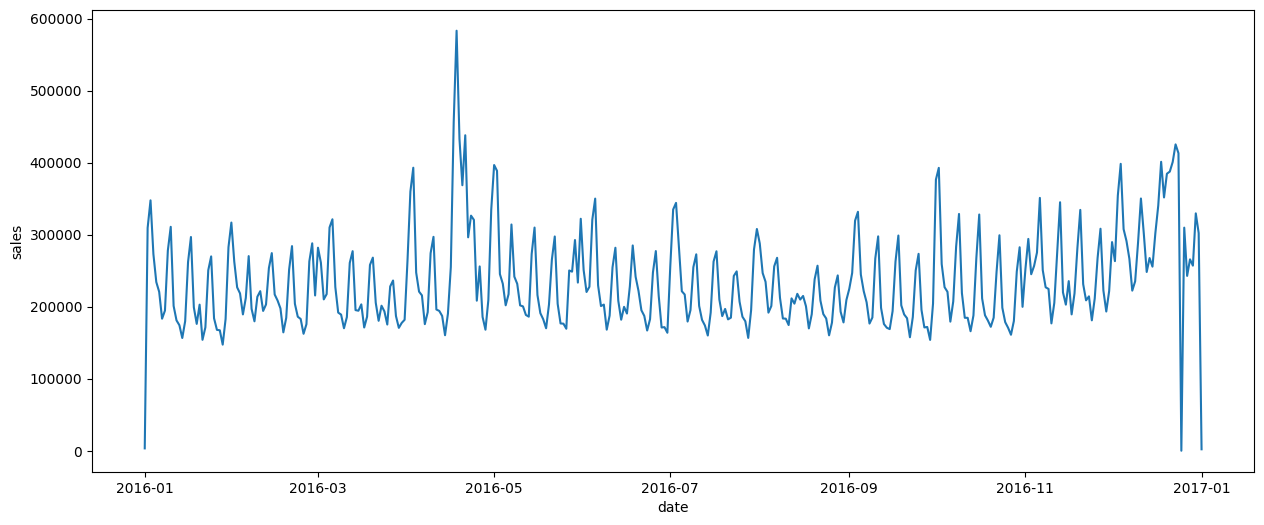

In [186]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=grocery_1_data['2016-01-01':'2017-01-01'],
             x=grocery_1_data['2016-01-01':'2017-01-01'].index,
             y='sales')
plt.show()

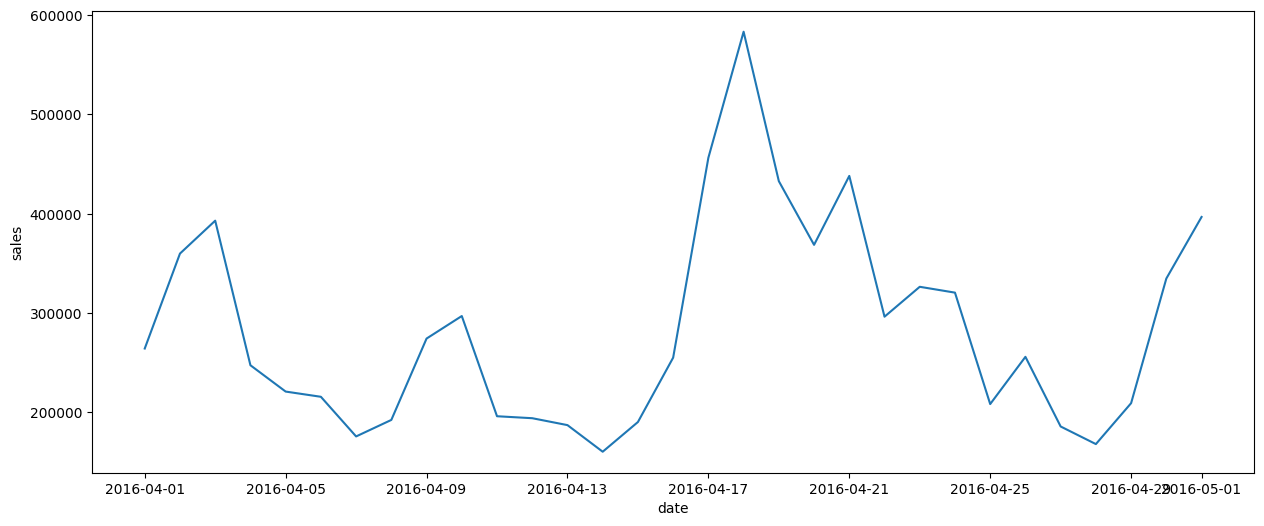

In [187]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=grocery_1_data['2016-04-01':'2016-05-01'],
             x=grocery_1_data['2016-04-01':'2016-05-01'].index,
             y='sales')
plt.show()

### MEATS

In [188]:
meats_data = data_agg[data_agg['family'] == 'MEATS']

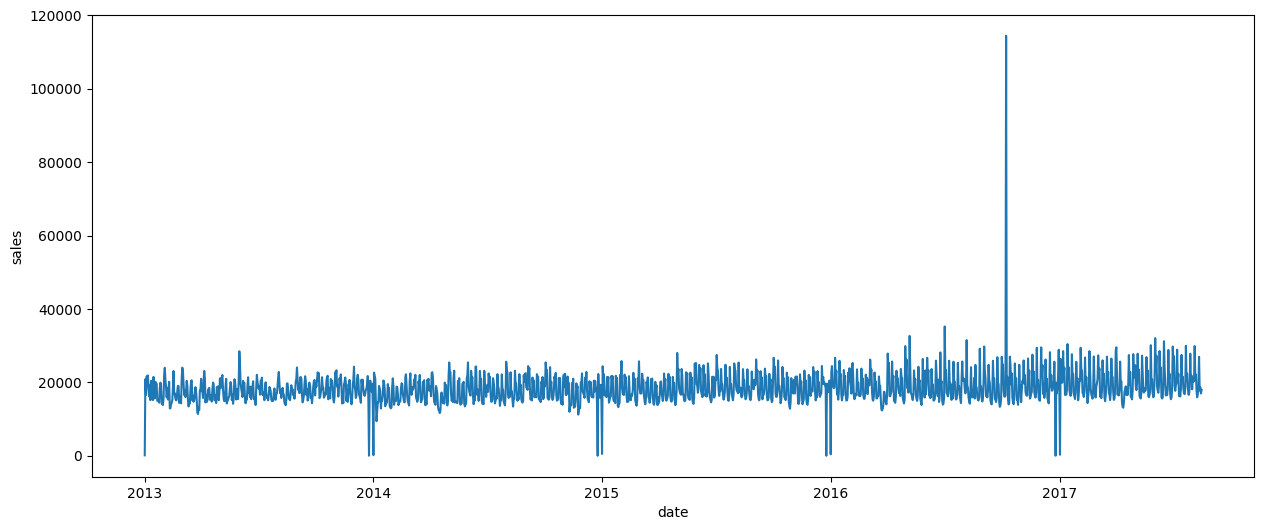

In [189]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=meats_data, x=meats_data.index, y='sales')
plt.show()

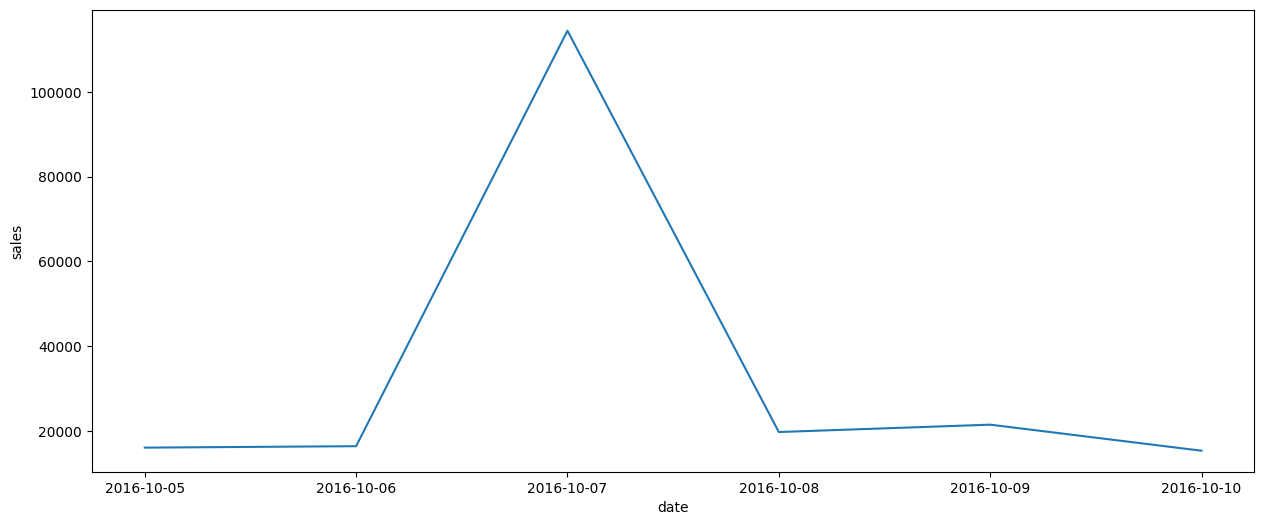

In [195]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=meats_data['2016-10-05':'2016-10-10'],
             x=meats_data['2016-10-05':'2016-10-10'].index,
             y='sales')
plt.show()

##

### LAWN AND GARDEN

In [196]:
lawn_and_garden_data = data_agg[data_agg['family'] == 'LAWN AND GARDEN']

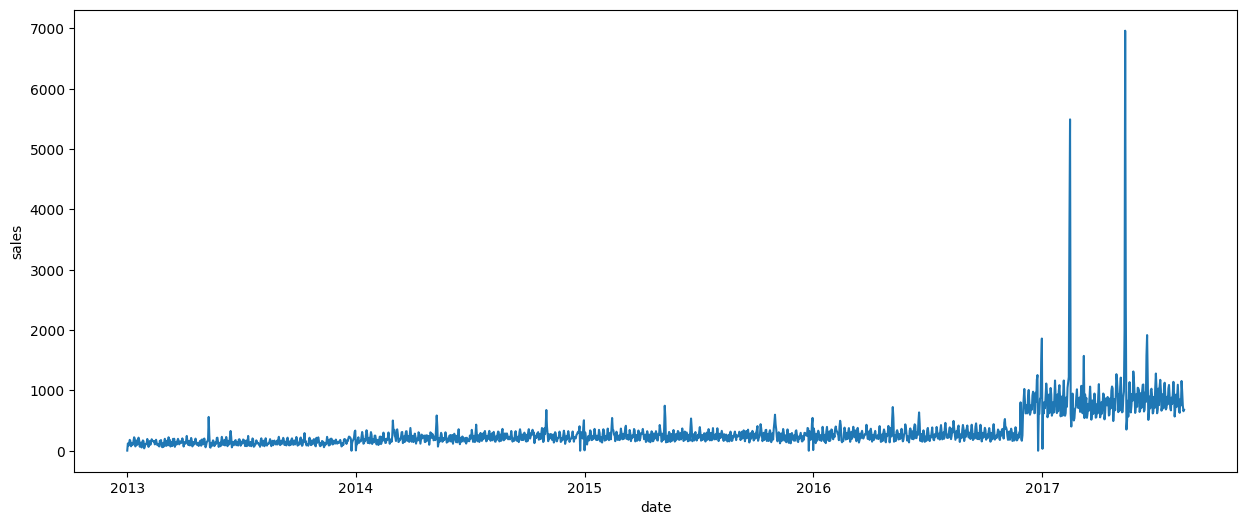

In [197]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=lawn_and_garden_data, x=lawn_and_garden_data.index, y='sales')
plt.show()

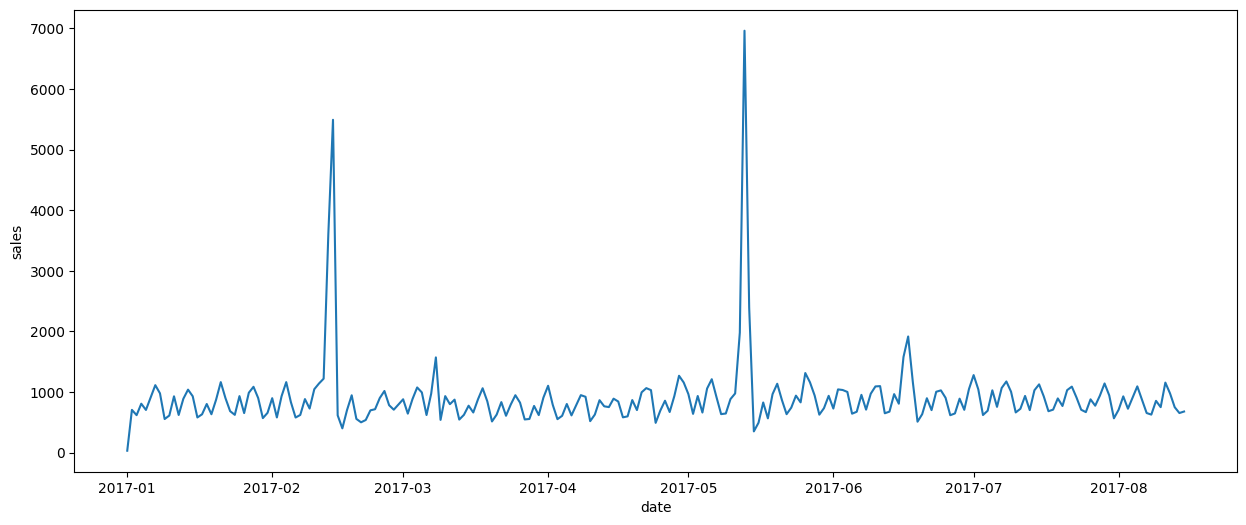

In [199]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=lawn_and_garden_data['2017-01-01':],
             x=lawn_and_garden_data['2017-01-01':].index,
             y='sales')
plt.show()

### MAGAZINES

In [200]:
magazines_data = data_agg[data_agg['family'] == 'MAGAZINES']

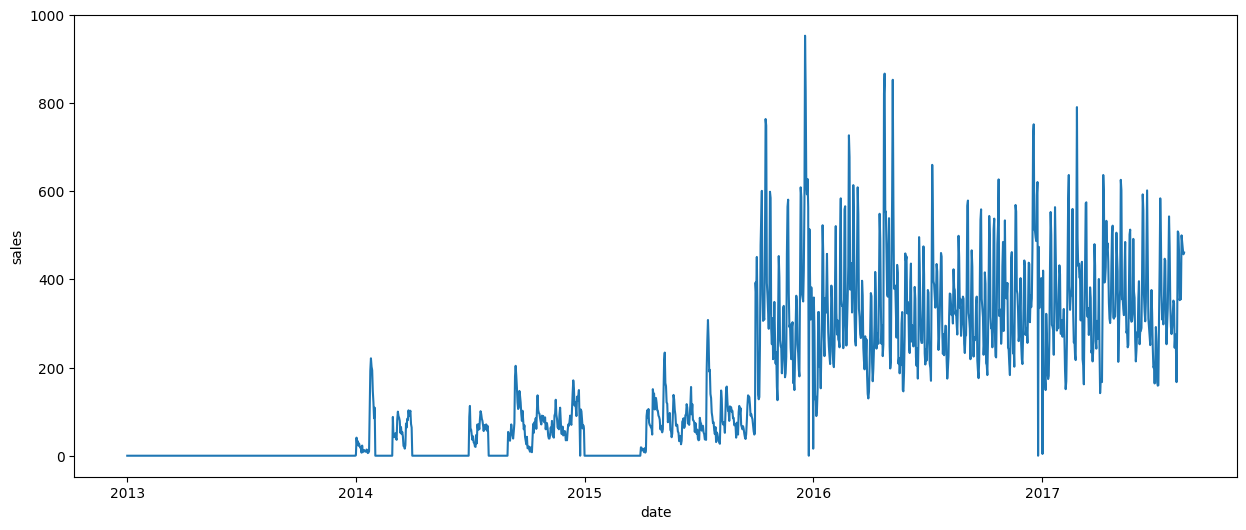

In [201]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=magazines_data, x=magazines_data.index, y='sales')
plt.show()

### SCHOOL AND OFFICE SUPPLIES

In [203]:
school_data = data_agg[data_agg['family'] == 'SCHOOL AND OFFICE SUPPLIES']

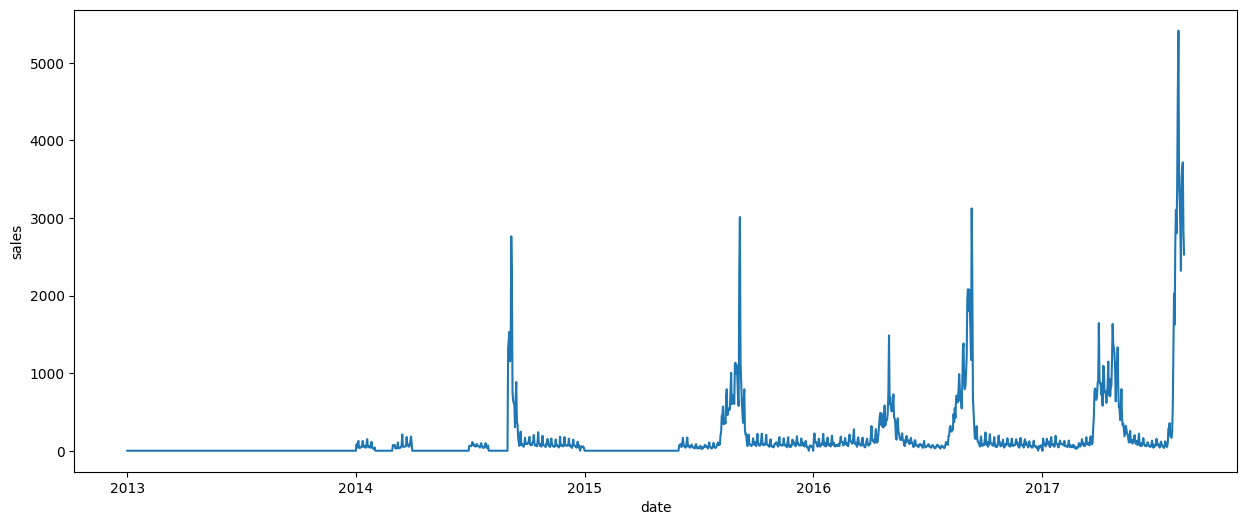

In [204]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=school_data, x=school_data.index, y='sales')
plt.show()

#### Year



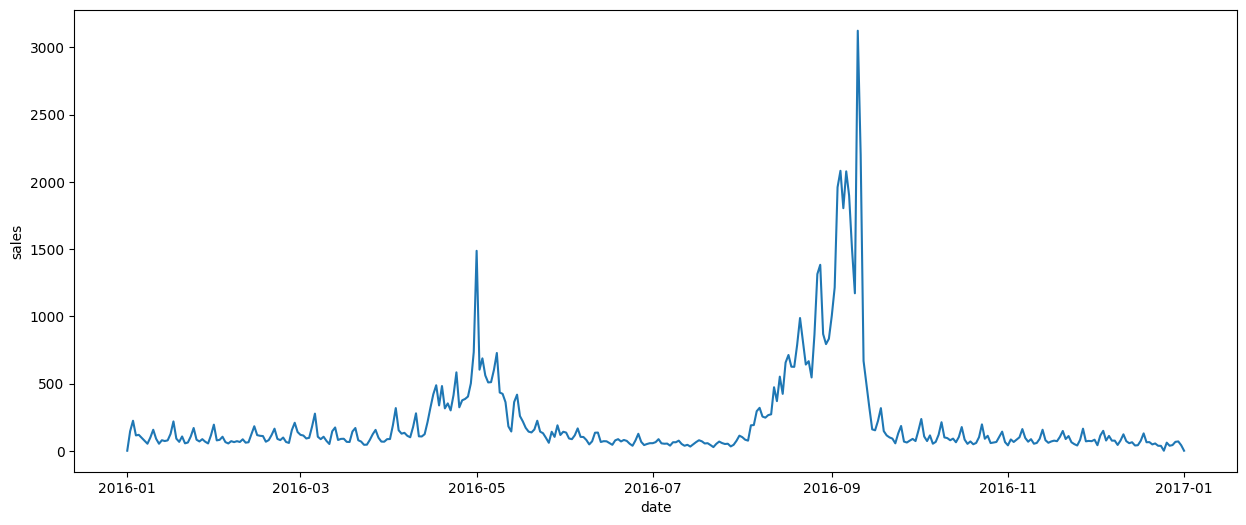

In [205]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=school_data['2016-01-01':'2017-01-01'],
             x=school_data['2016-01-01':'2017-01-01'].index,
             y='sales')
plt.show()


# Feature Engineering


I'll add general features: year, month, day_of_week, is_payday, is_weekend (on the 15th and last day of the month), and is_christmas (December 25 and January 1).

I'll also add rolling statistics and lag features.

I'll include additional public holidays (considering date shifts as well).

I'll add a was_earthquake feature from the 17th to the 20th.

The middle of 2015 is truly the exact middle of 2015: 2015-06-01.

BOOKS data is sliced from 2016-10-08.

In some product families (meat, lawn and garden), there are outliers that are either related to holidays, oil prices, or are simply anomalies. Initially, I'll try to account for all the additional features mentioned above, plus include oil sales. Given that the optimization metric is RMSLE and I'm using tree-based models (boostings) which are robust to outliers, I don't see any major issues. If the results are still poor, I'll try replacing the outliers with the median.



# What's Next?
From the data analysis, I've concluded that the features are common to all families (it's likely possible to add specific features, but I decided not to overcomplicate things for now).

I'll train a single model on data starting from 2016-01-01—all data from this point is stable. However, this raises the issue of the target's scale and type. I could add the target type as a feature, is_discrete, and RMSLE handles target variable scaling quite well. For discrete data, I'll round the output values.

Instead of creating an is_discrete field, I could train two models by splitting the dataset into two parts: one with a continuous target and one with a discrete target. For the model working with discrete values, I could try Poisson instead of RMSLE. The first dataset will have a slice from 2016-01-01, while the second one won't have a slice (the data for this group is stable). The output from the discrete model would also be rounded.

My opinion is that the previous approach will also be poor, so I'll stick to creating 33 models, one for each product family (while also accounting for the target type).

The model should be robust to outliers and good at handling categories. CatBoost is a good choice, I think, but I also have an idea to try a GLM with a Poisson distribution or a Negative Binomial GLM, especially for points two and three. LightGBM is another option (it would be faster than CatBoost).

I have some other models in mind to try, but for now, I'll focus on boosting and GLM.